# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='goldenbear',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_em',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=1, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AA…

Dropdown(description='Objective:', index=3, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_em')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/goldenbear_c_curves_p.pkl
Loaded data from ./inputs/curves/goldenbear_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for goldenbear_min_em_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3905 rows, 36130 columns and 36130 nonzeros
Model fingerprint: 0x2ead7e01
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3905 rows and 36130 columns
Presolve time: 0.03s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -5.7036608e+07   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.04 seconds (0.01 work units)
Optimal objective -5.703660806e+07


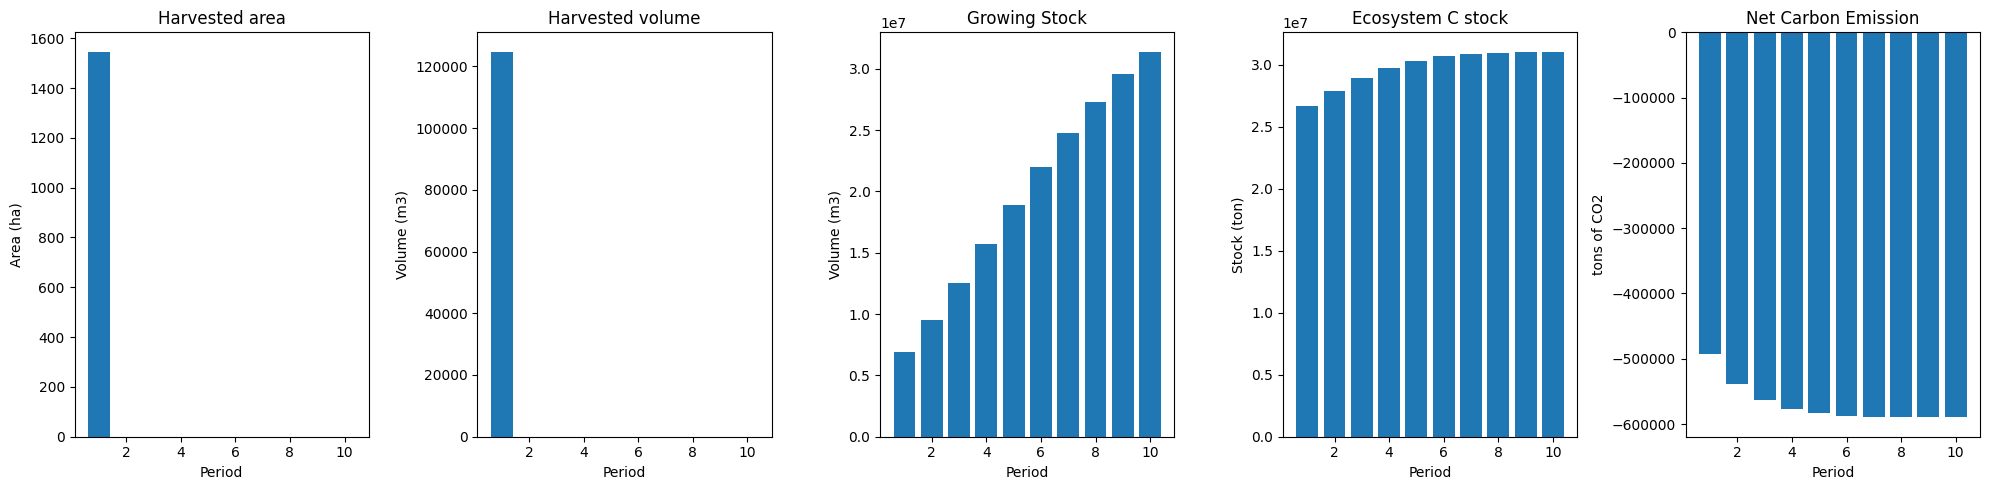

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  131
The economic indicator (the provincial government revenues) is:  4498
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


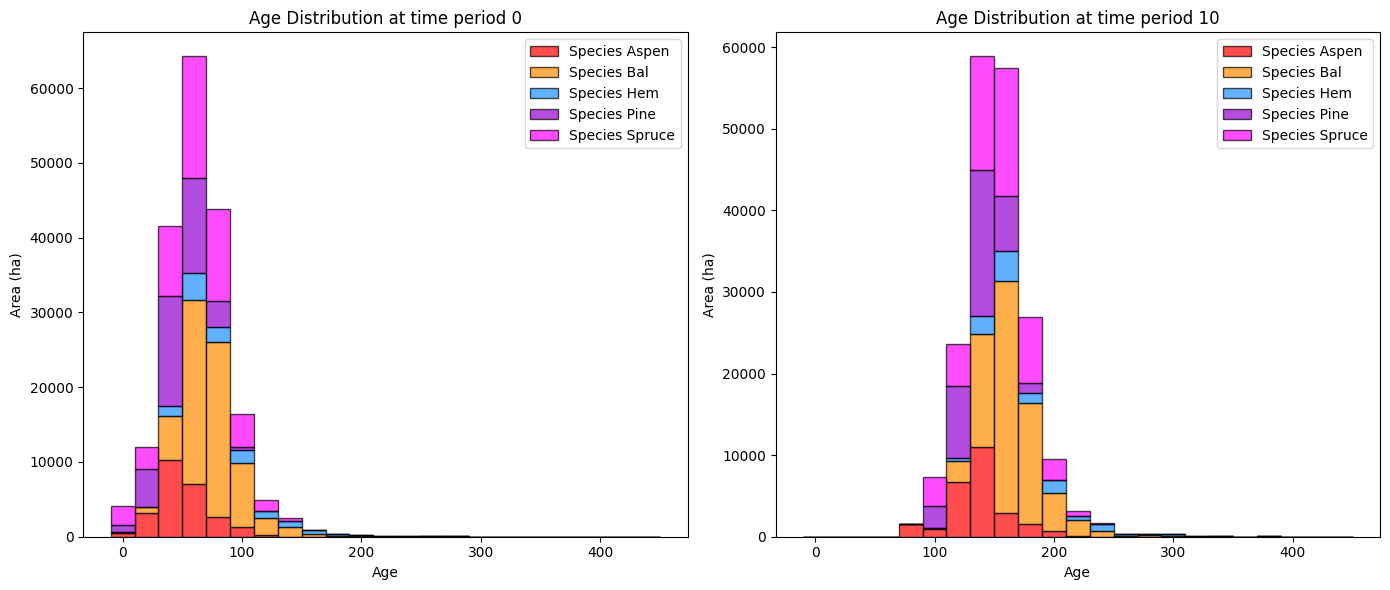

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  11866.690990  11593.200512
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Old growth has **increased** by 46456.98 hectares from time period 0 to time period 10.


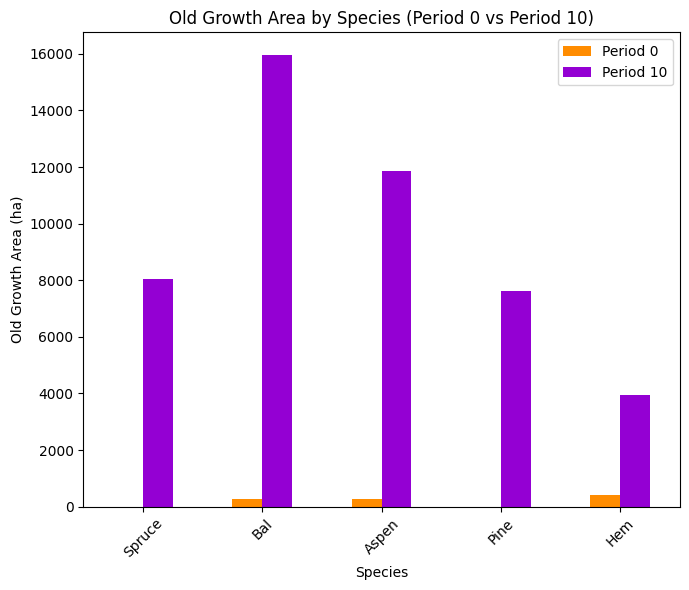

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9277

Diversity has **decreased** by 1.78% from time 0 to time 10.


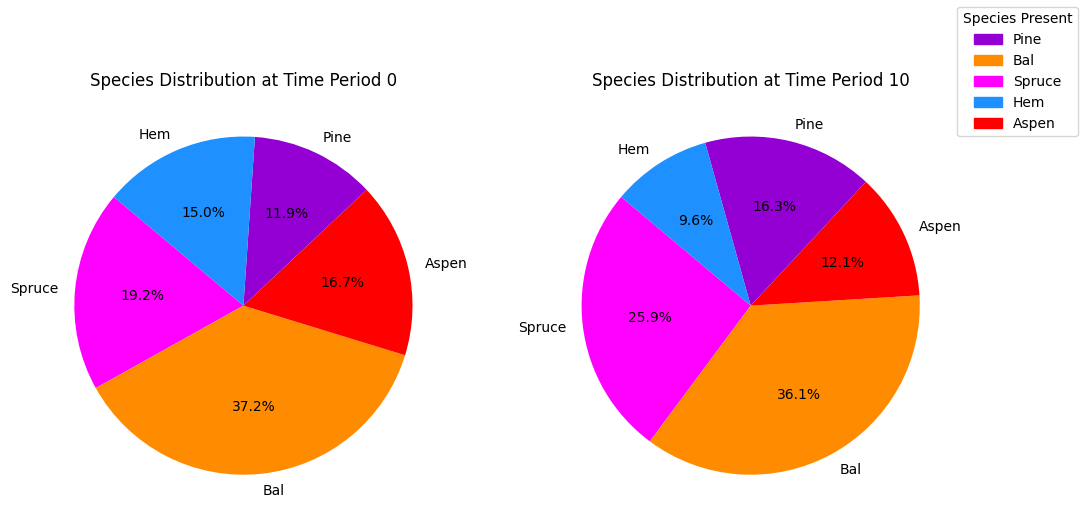

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_no_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00

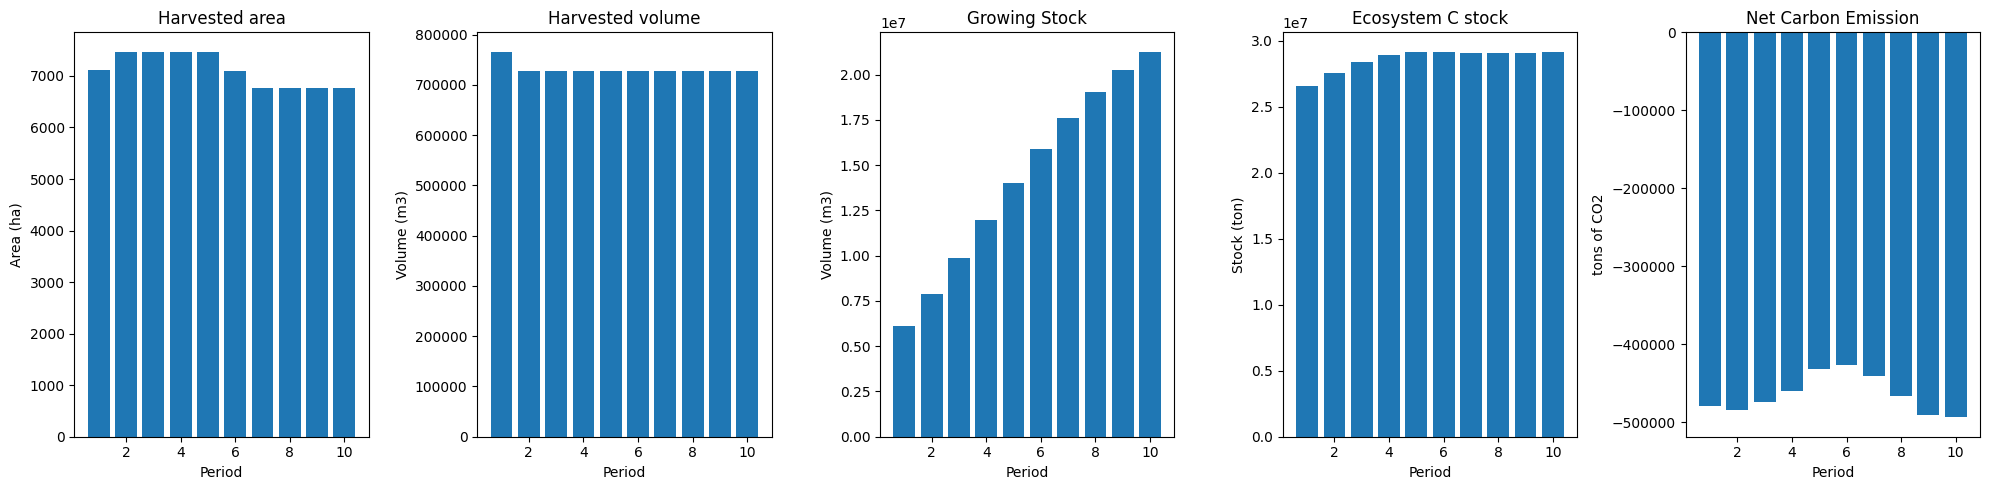

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


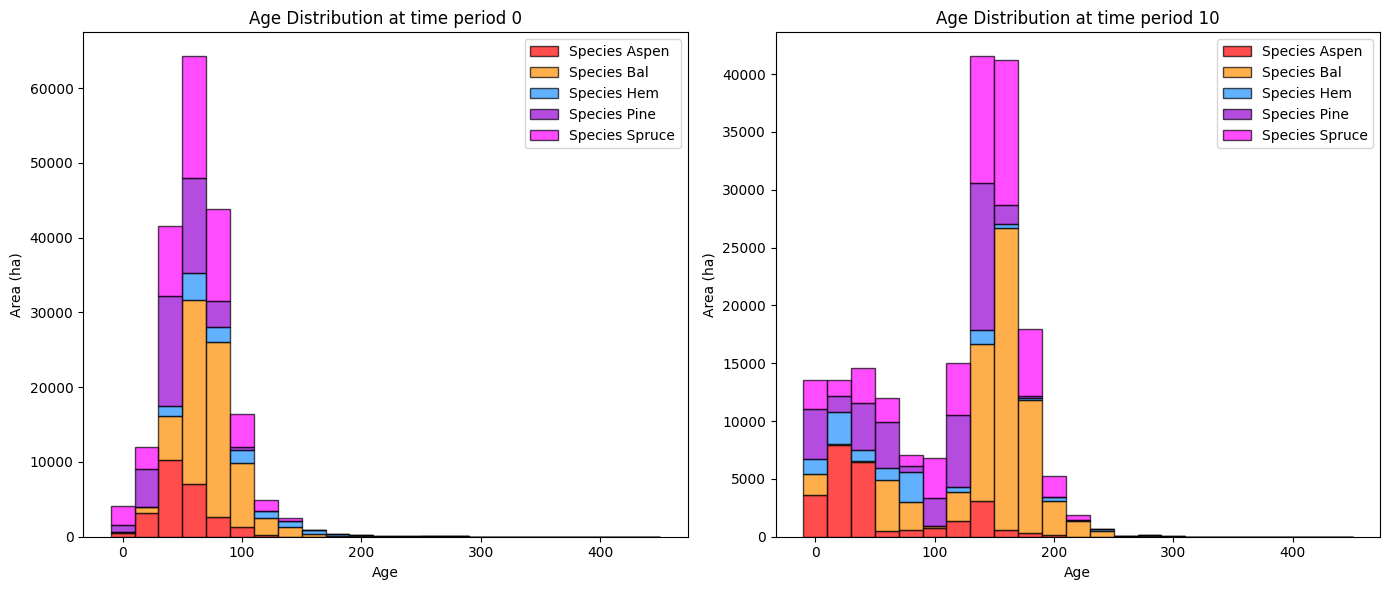

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


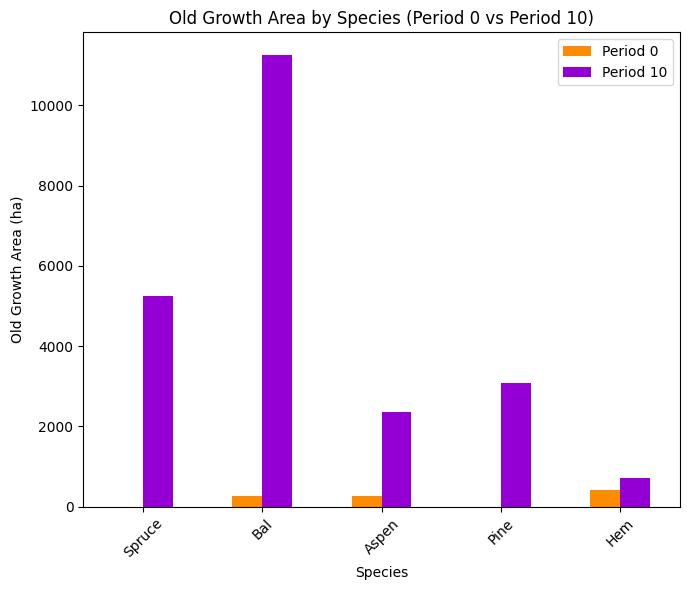

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


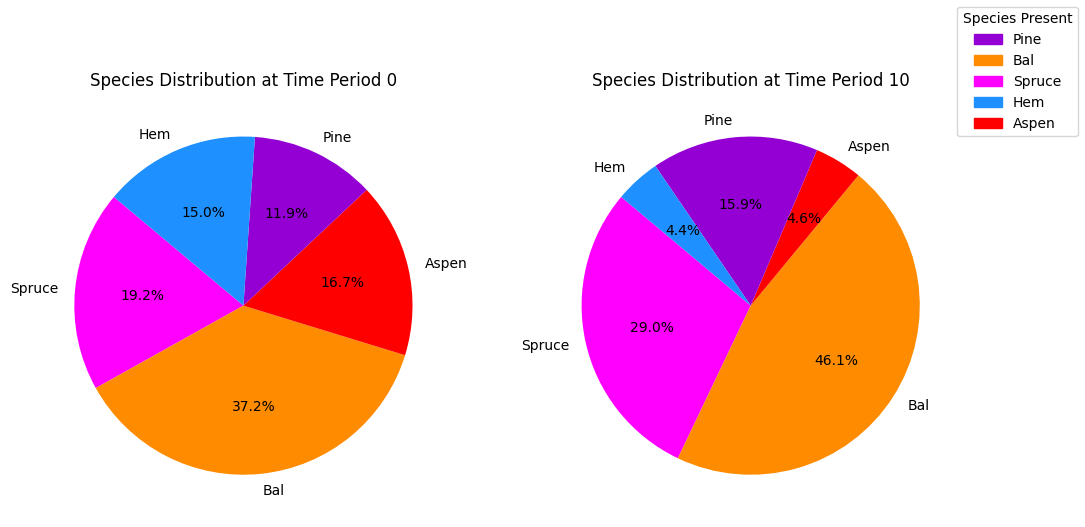

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


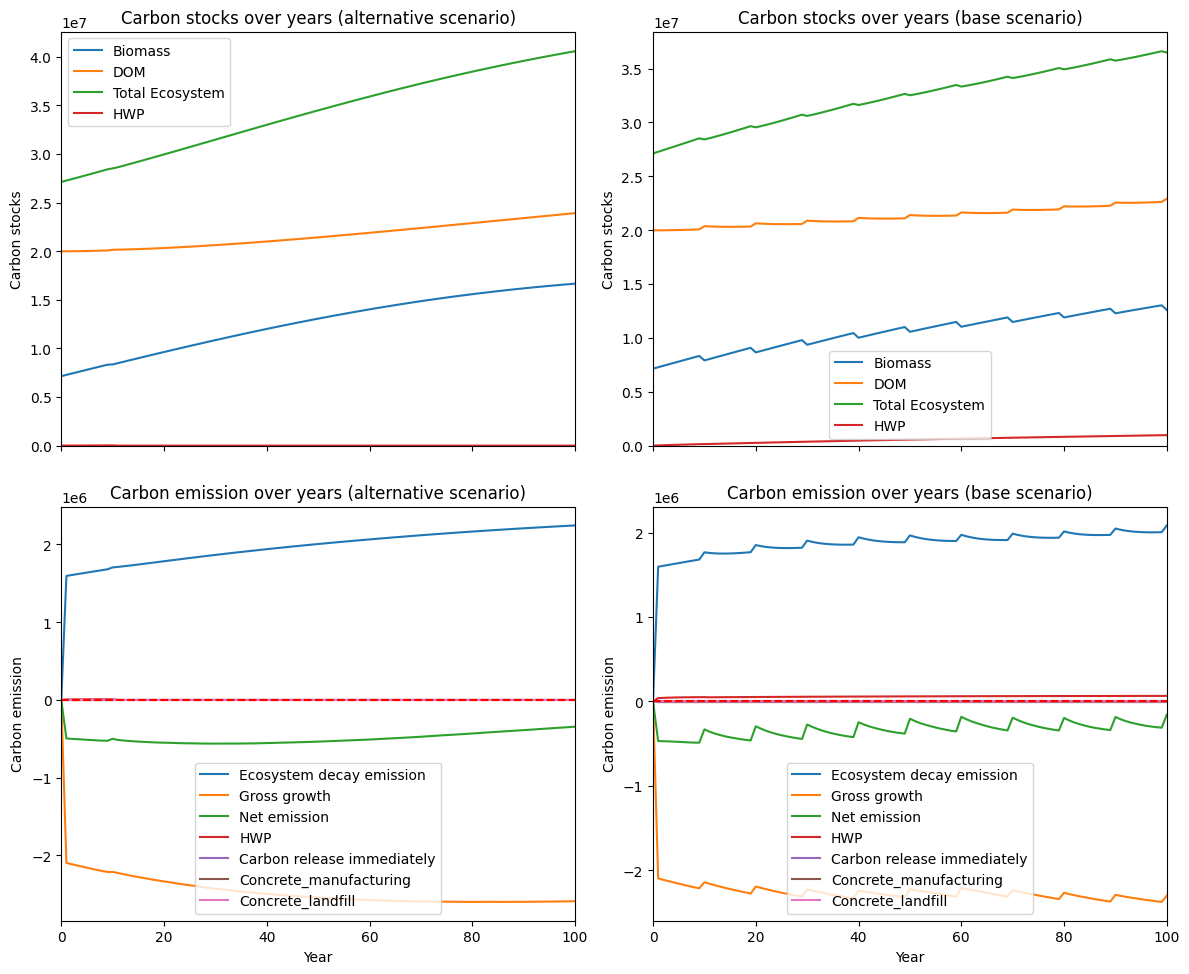

---------------------------------------------------------------------------------------
Net emission difference -16137167.63302231
Net emission base scenario -33239922.163316067
Net emission alternative scenario -49377089.796338364
dollar_per_ton is:  0.6196874338428814
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2797.454325  2797.454325
Bal     0.0  4710.013370  4710.013370
Aspen   0.0  9516.723414  9516.723414
Pine    0.0  4544.690840  4544.690840
Hem     0.0  3224.553142  3224.553142

Overall, the old growth area has **increased** by 24793.44 hectares in the alternative scenario compared to the base scenario.


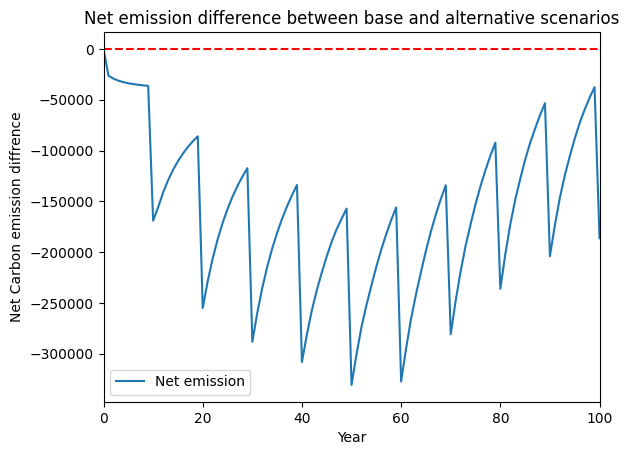

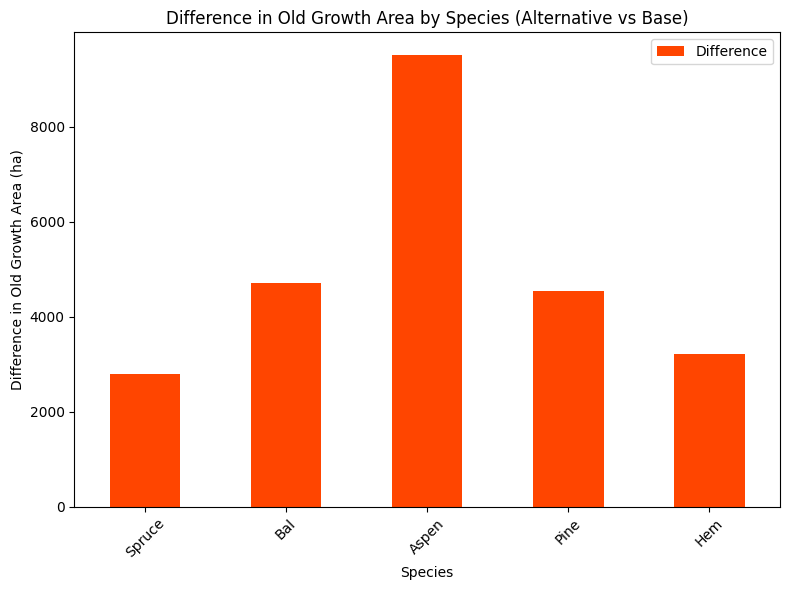

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


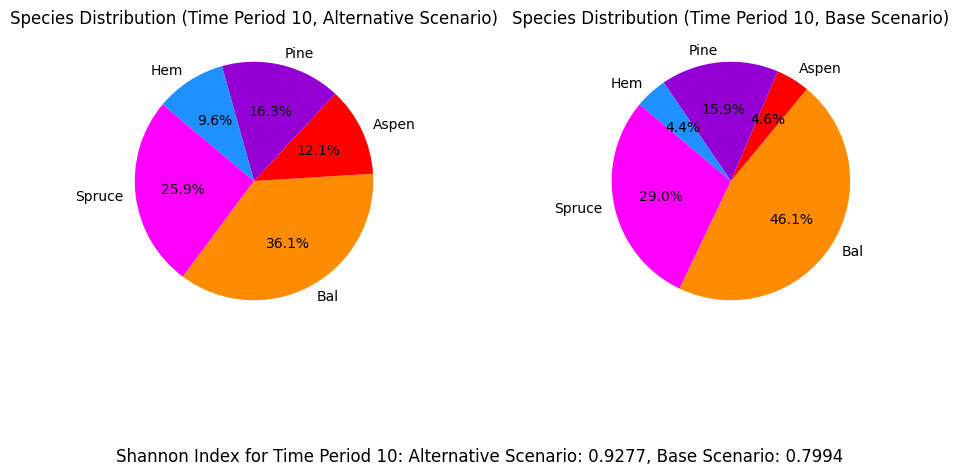

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3945 rows, 36130 columns and 430076 nonzeros
Model fingerprint: 0x5d74d80c
Coefficient statistics:
  Matrix range     [1e-02, 9e+04]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2035 rows and 2031 columns
Presolve time: 0.10s
Presolved: 1910 rows, 34099 columns, 402875 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering ti

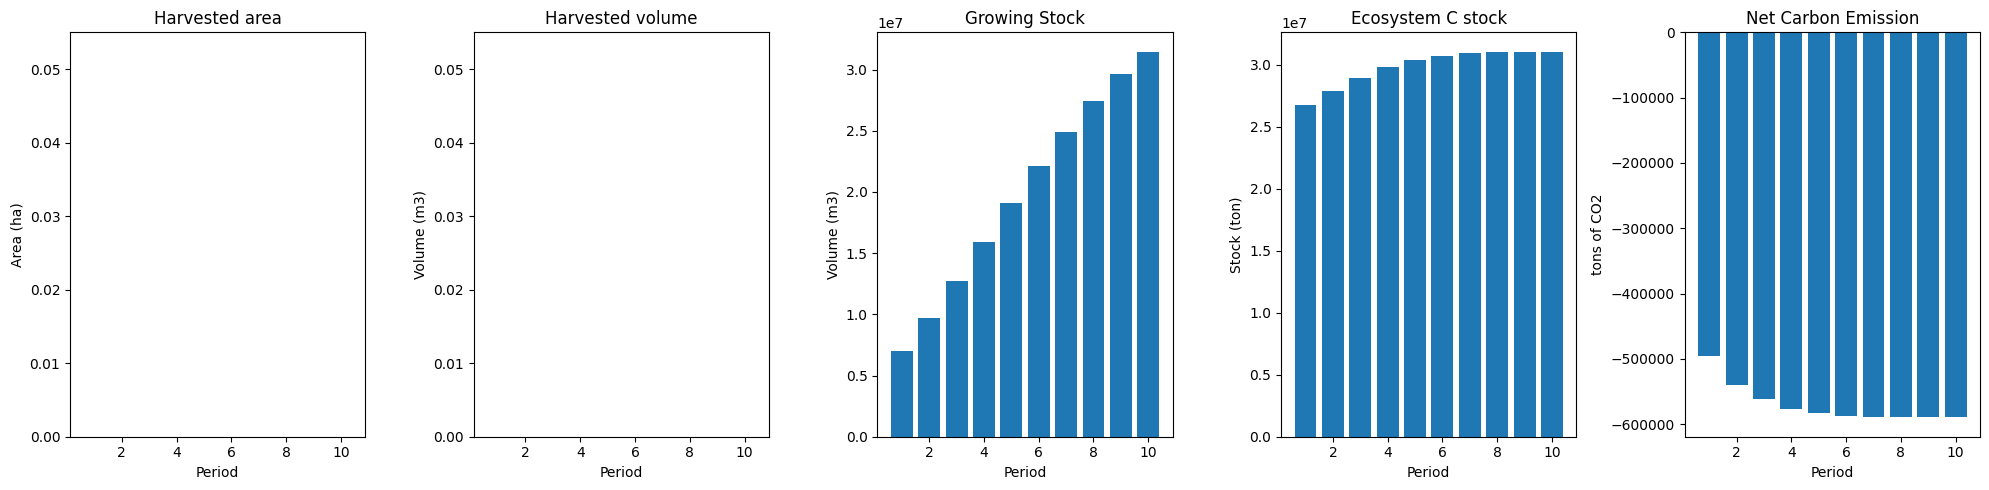

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


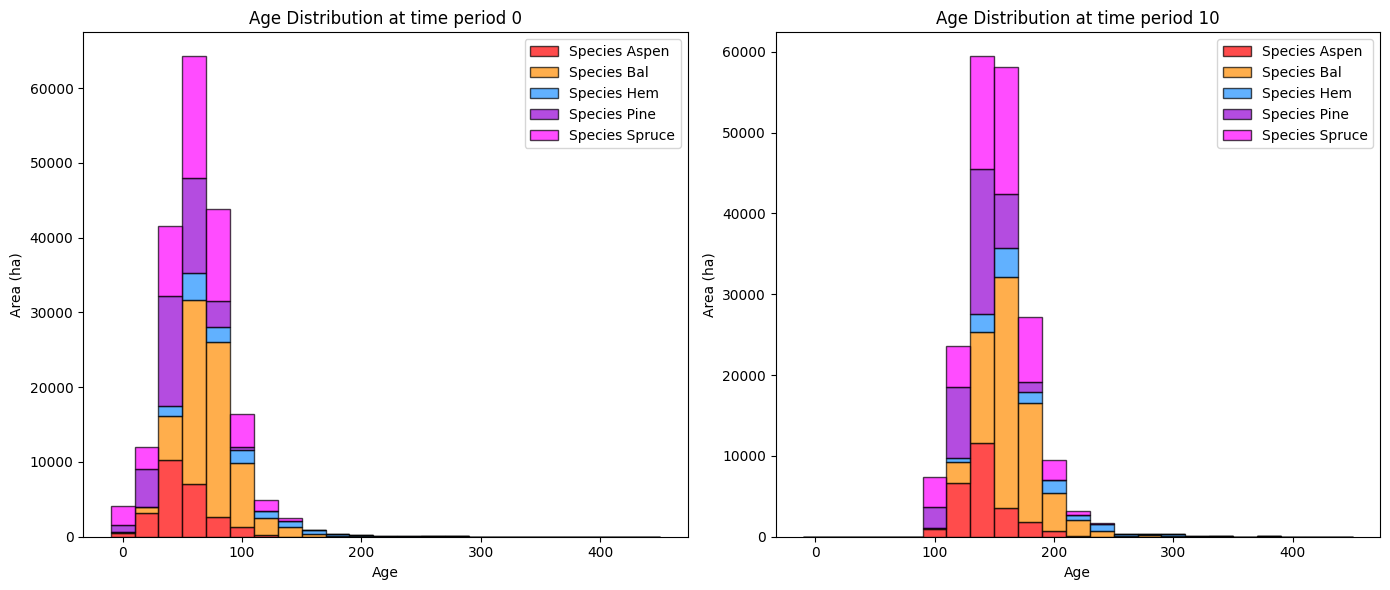

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Old growth has **increased** by 47781.91 hectares from time period 0 to time period 10.


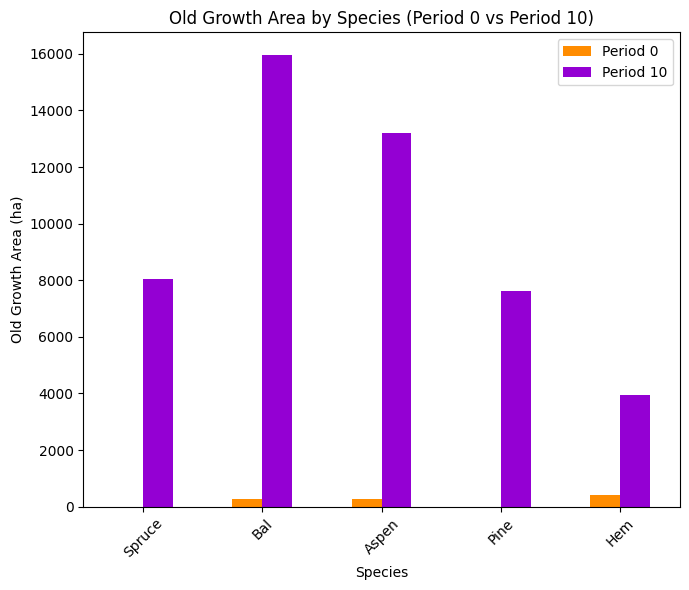

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9285

Diversity has **decreased** by 1.71% from time 0 to time 10.


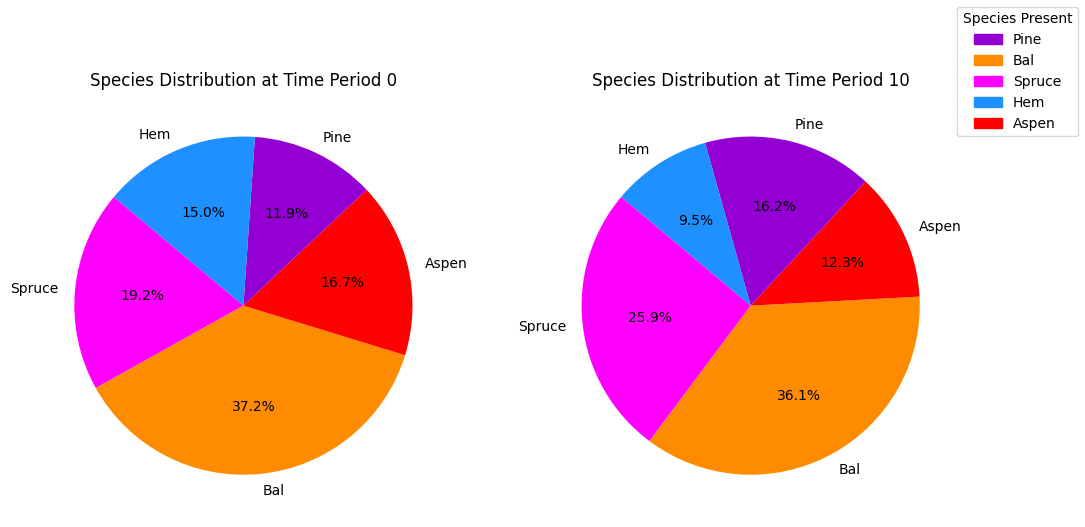

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_evenflow_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.12s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

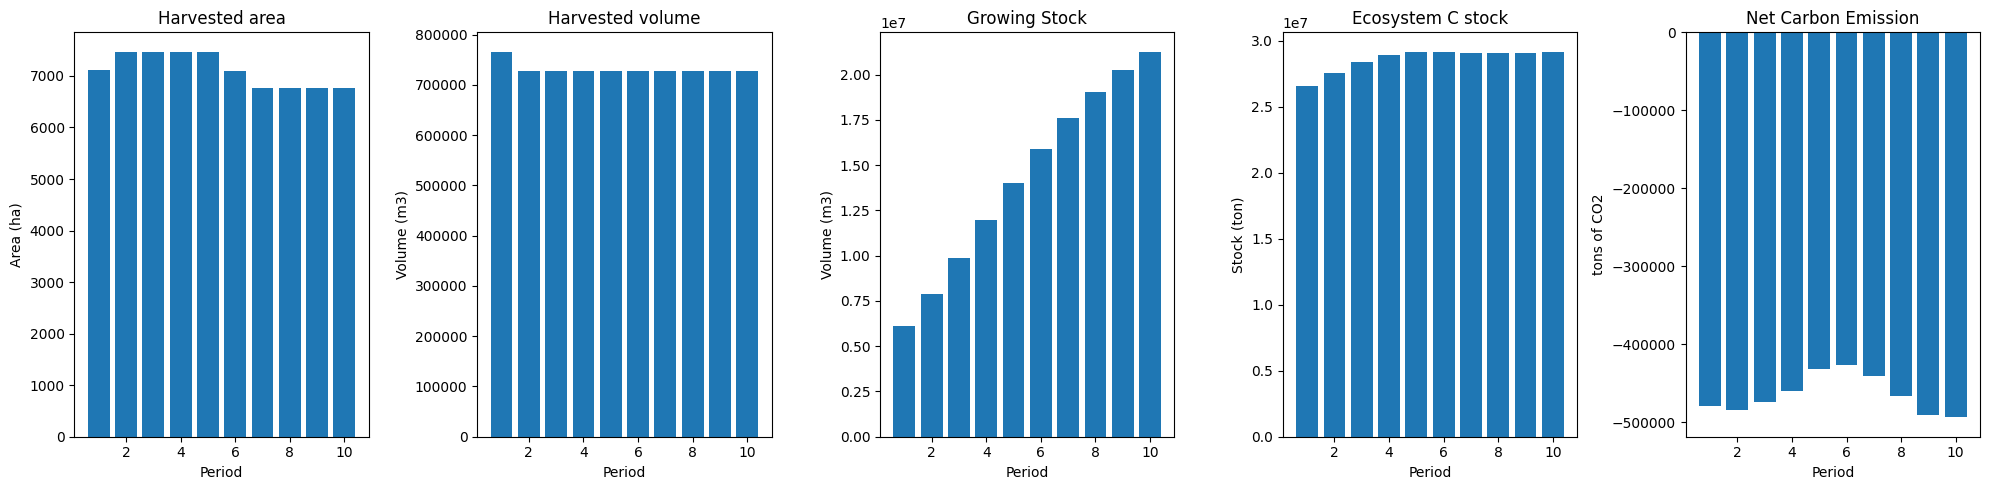

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


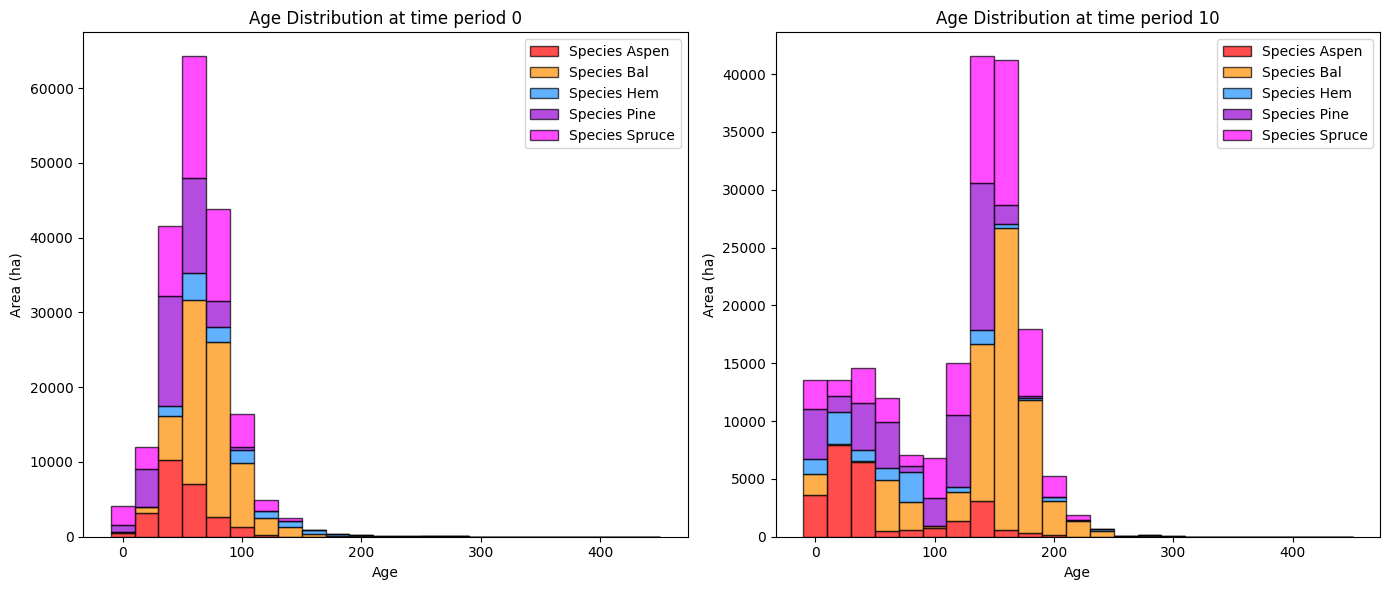

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


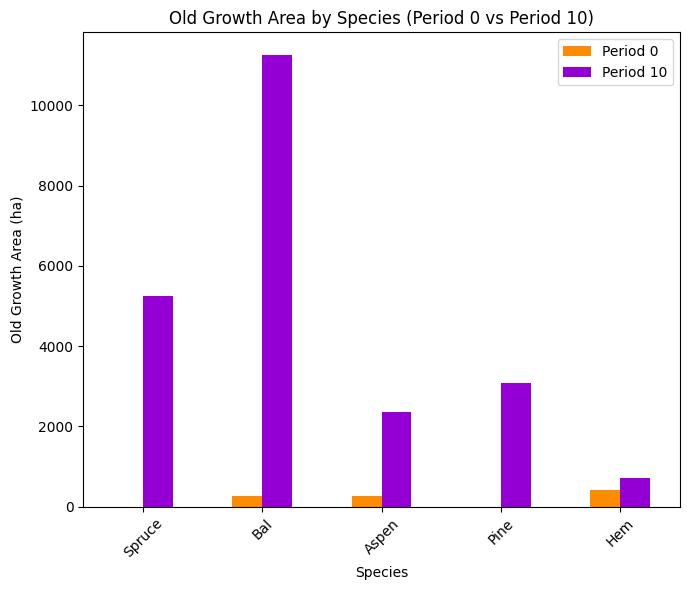

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


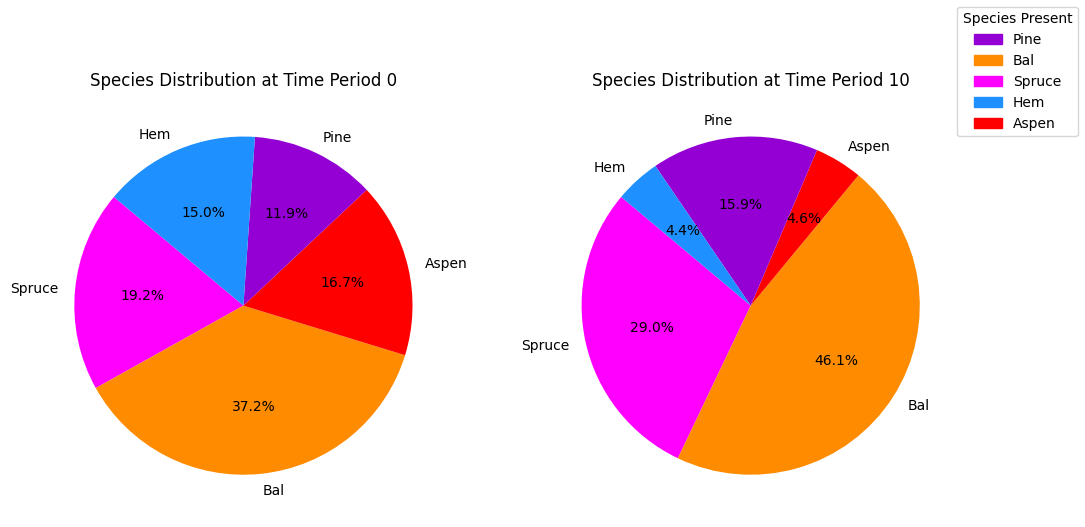

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


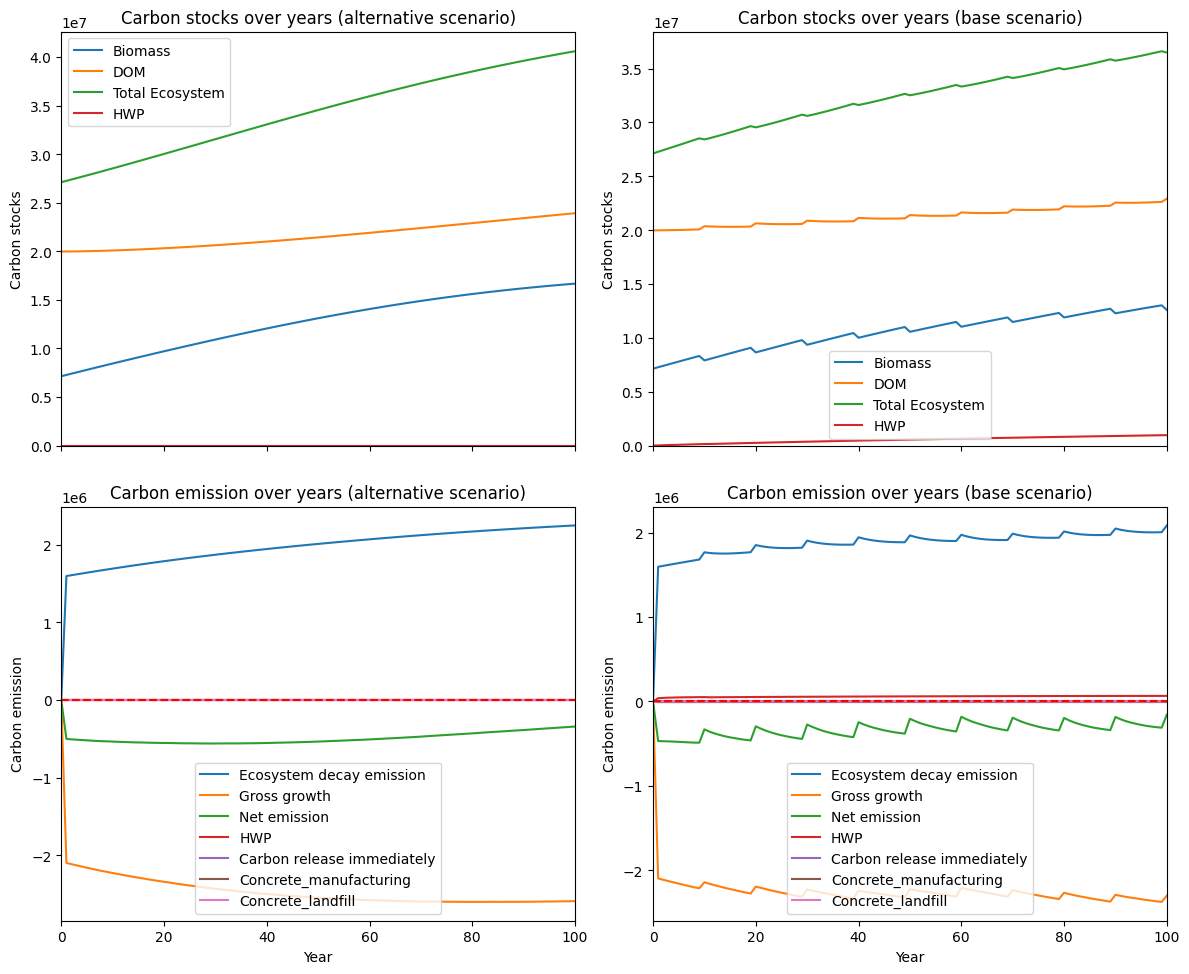

---------------------------------------------------------------------------------------
Net emission difference -16187399.524363998
Net emission base scenario -33239922.163316067
Net emission alternative scenario -49427321.687680066
dollar_per_ton is:  0.6177644522178369
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Spruce  0.0   2797.454325   2797.454325
Bal     0.0   4710.013370   4710.013370
Aspen   0.0  10841.650697  10841.650697
Pine    0.0   4544.690840   4544.690840
Hem     0.0   3224.553142   3224.553142

Overall, the old growth area has **increased** by 26118.36 hectares in the alternative scenario compared to the base scenario.


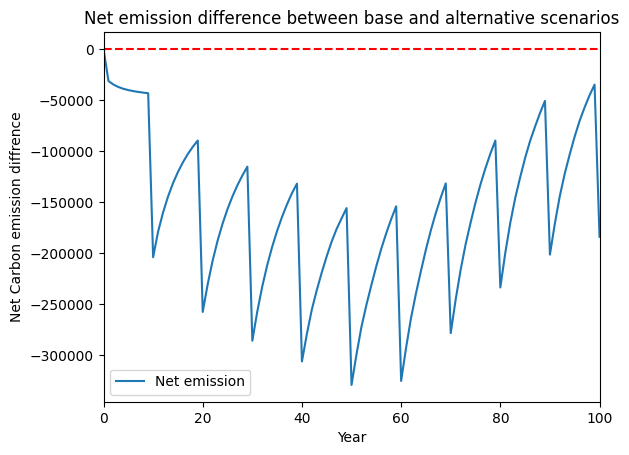

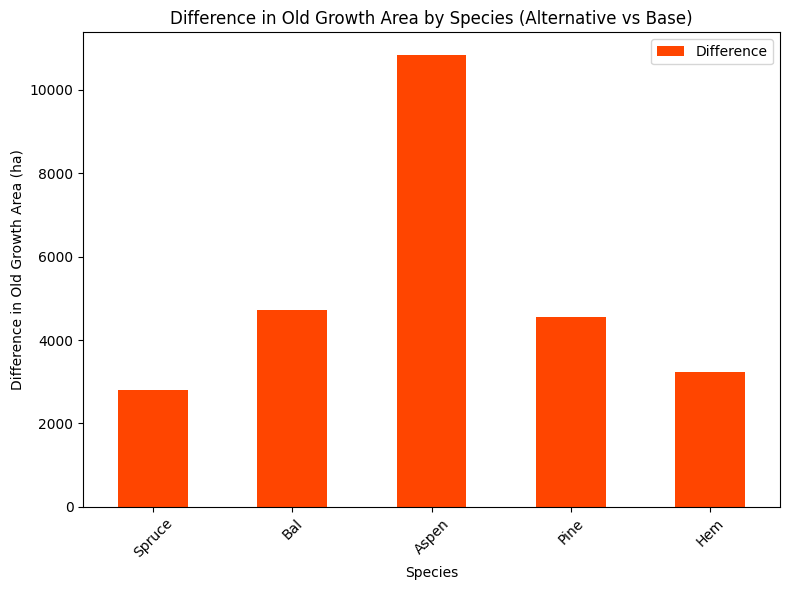

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


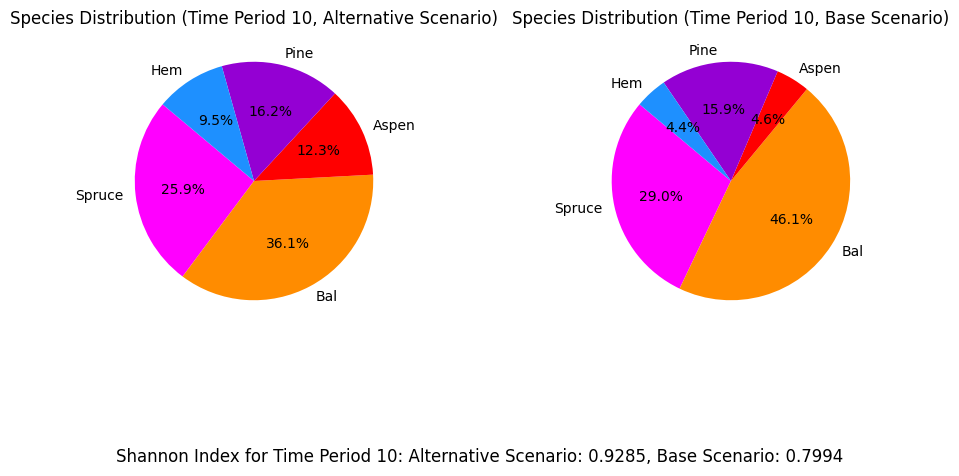

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_90%...
running the scenario for the Golden Bear mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xdd0f9795
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34100 

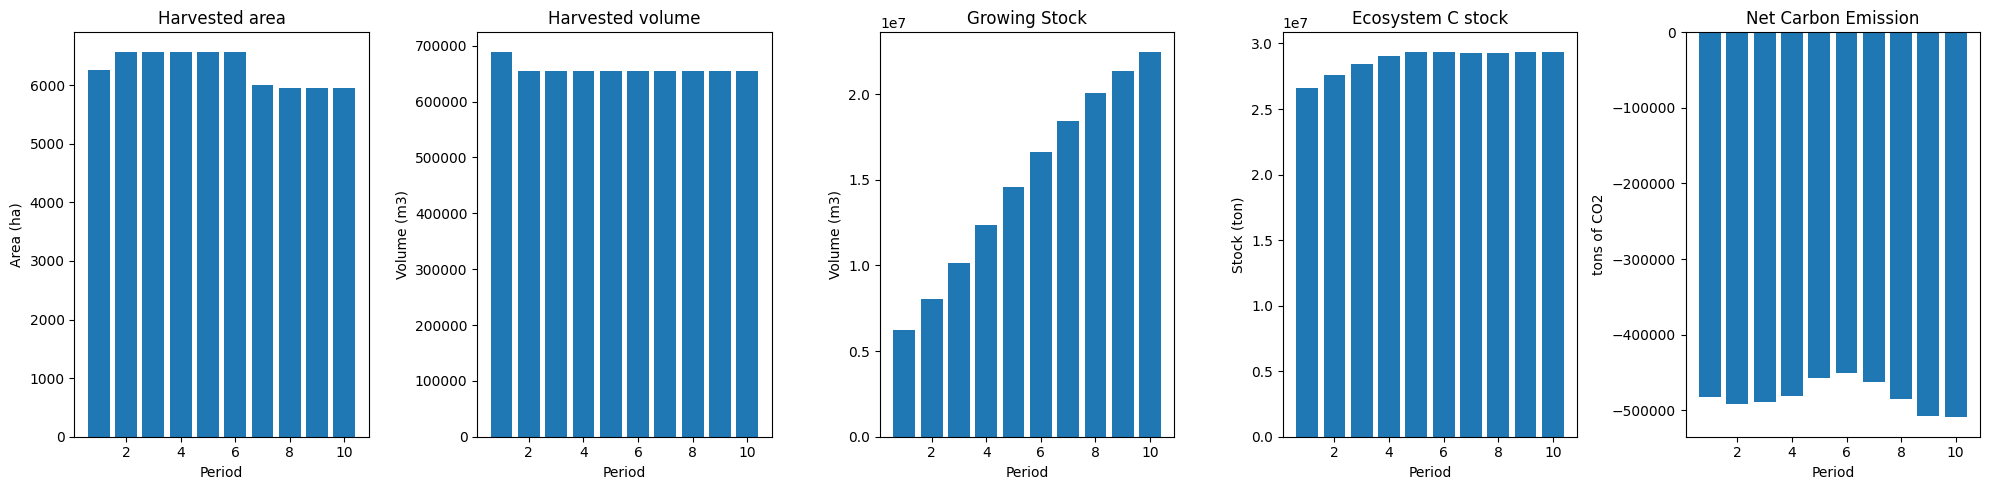

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6961
The economic indicator (the provincial government revenues) is:  237385
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


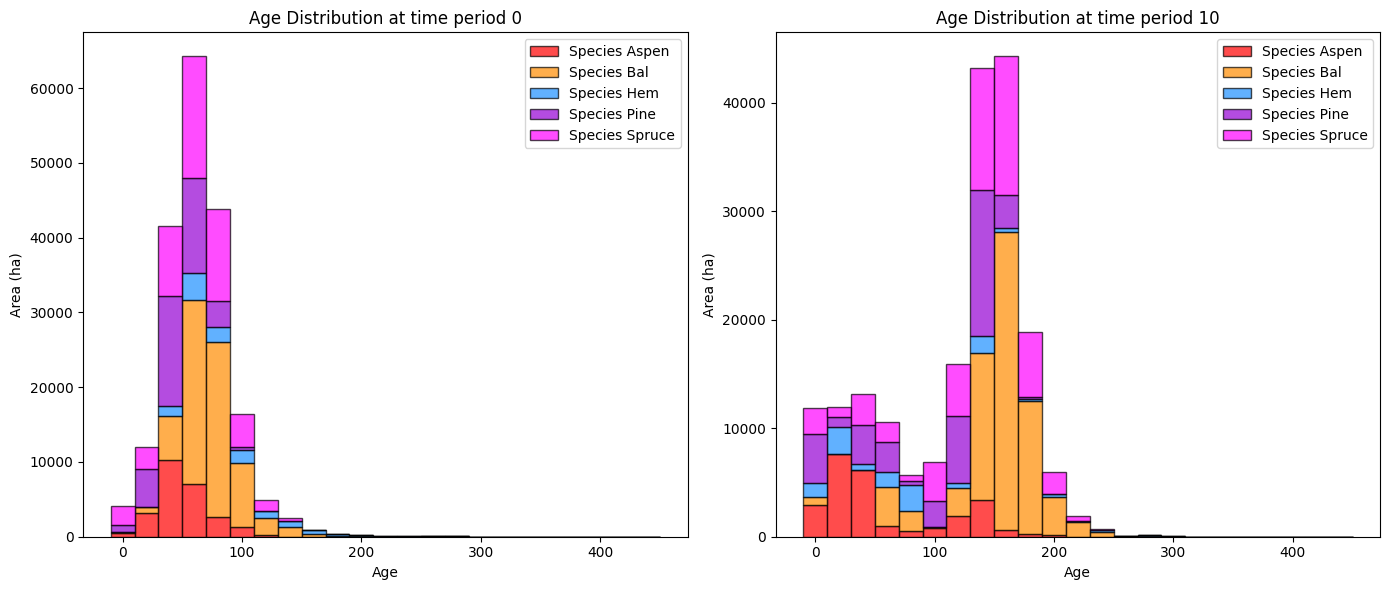

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5544.792177   5542.083643
Bal     278.565372  12247.617706  11969.052334
Aspen   273.490478   2448.845177   2175.354699
Pine      0.000000   4005.922411   4005.922411
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 23977.75 hectares from time period 0 to time period 10.


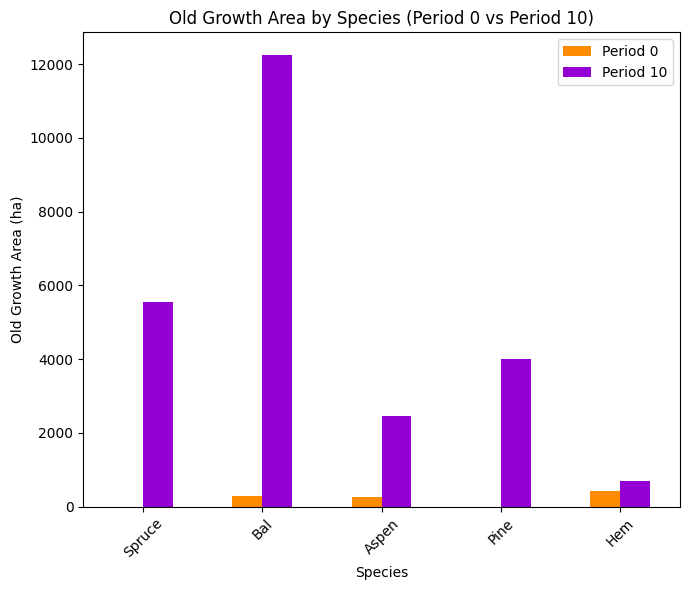

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8063

Diversity has **decreased** by 13.93% from time 0 to time 10.


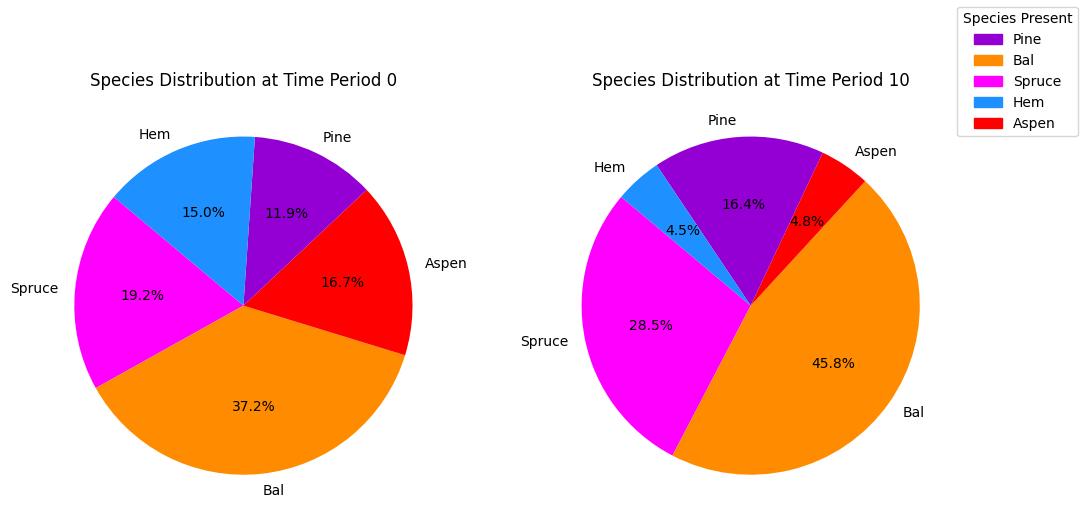

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_90%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.19s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

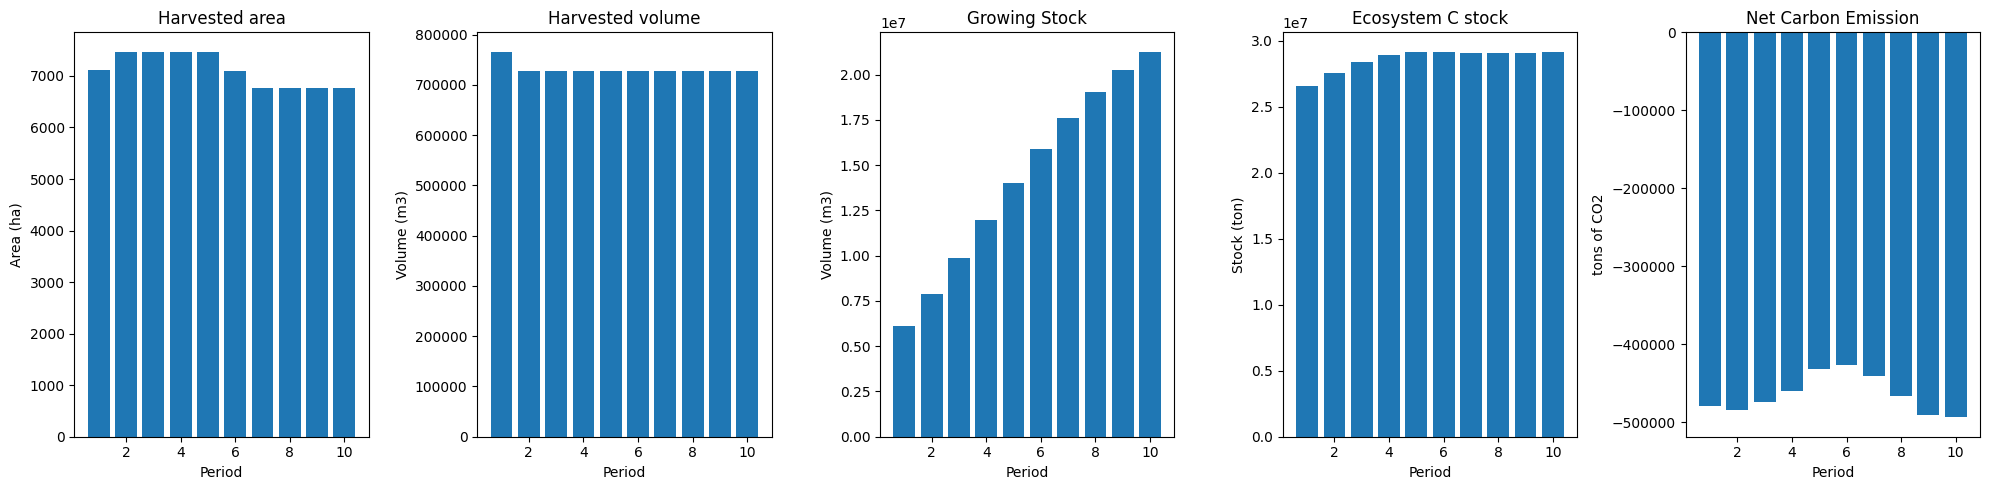

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


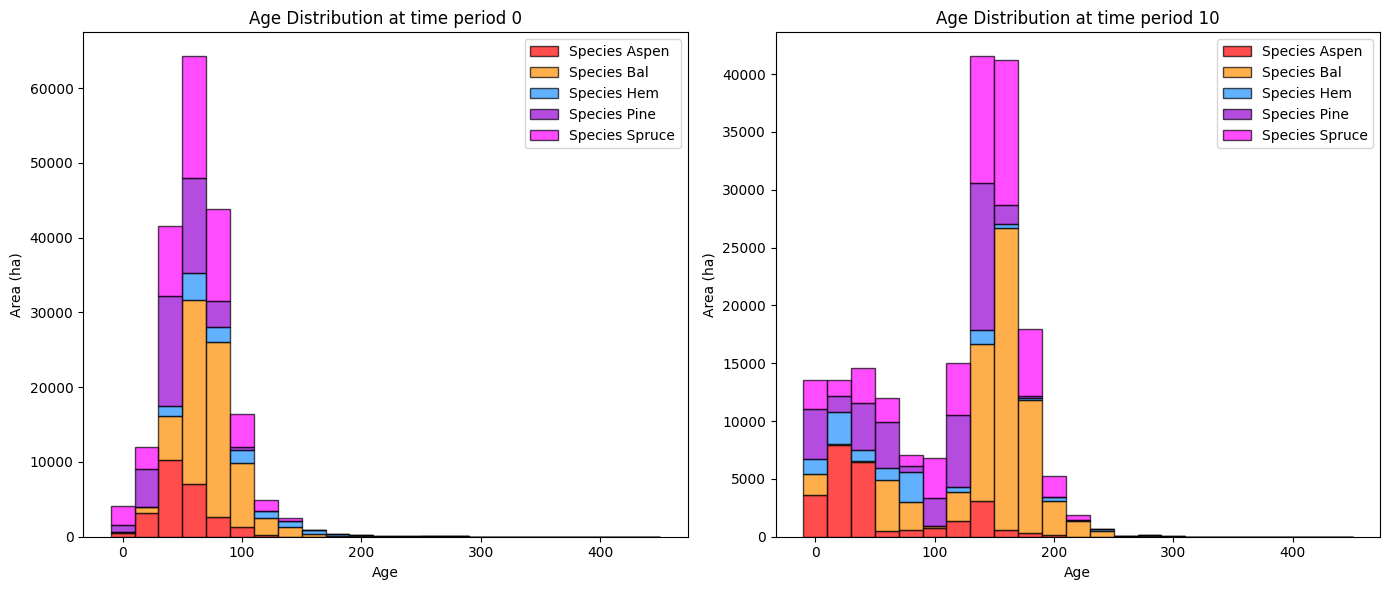

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


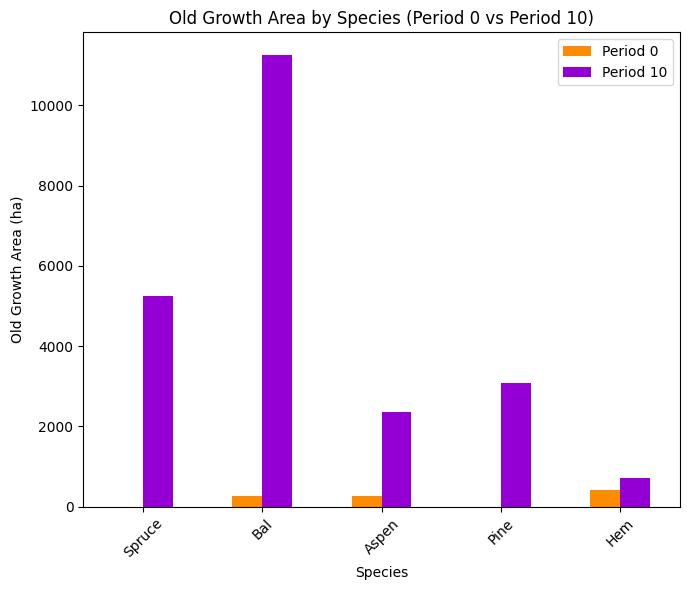

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


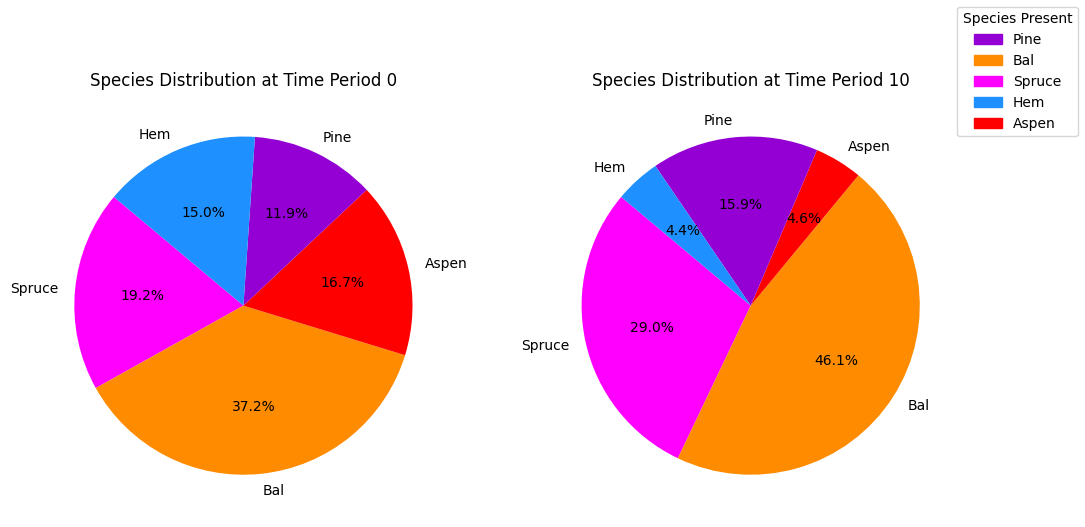

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


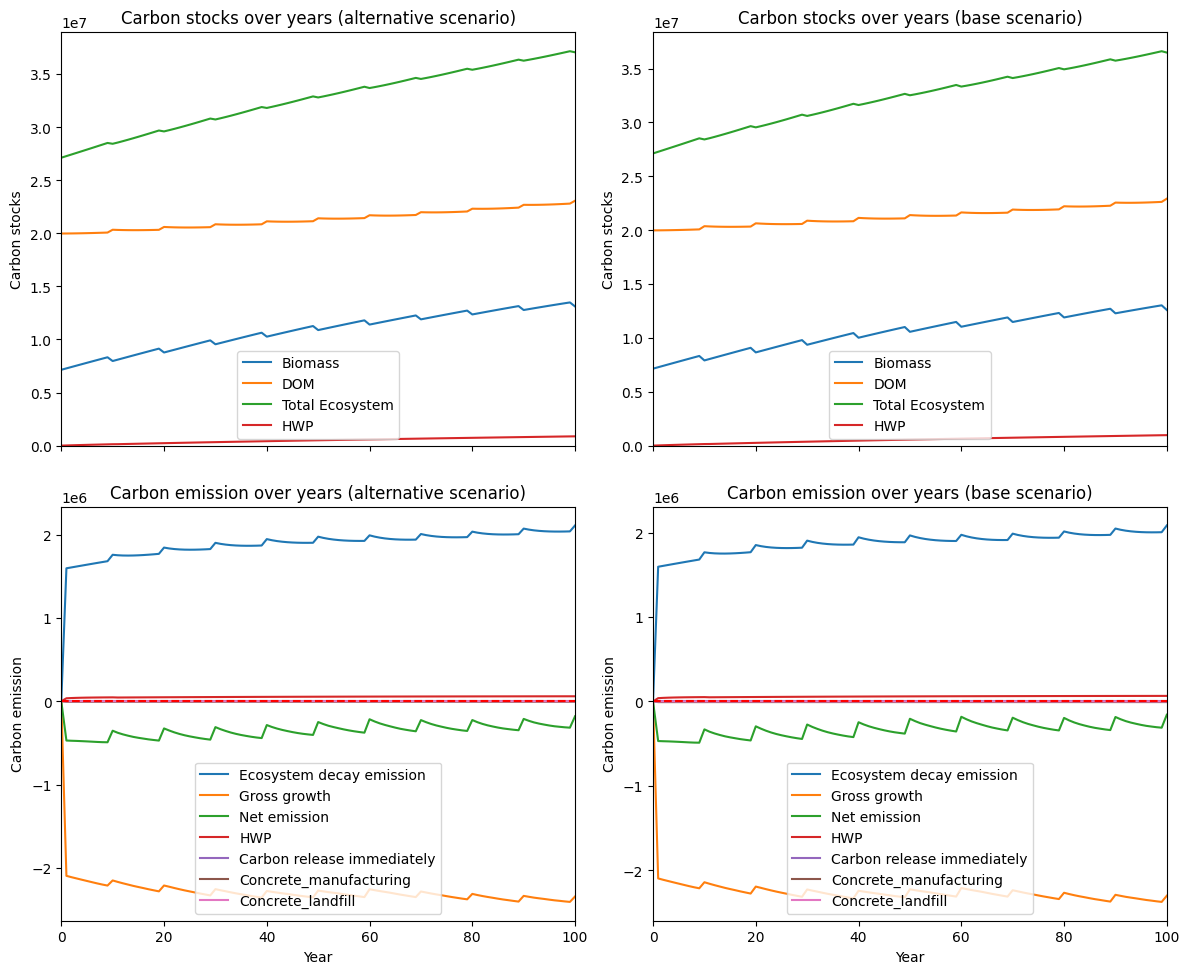

---------------------------------------------------------------------------------------
Net emission difference -2175908.5320707853
Net emission base scenario -33239922.163316067
Net emission alternative scenario -35415830.69538685
dollar_per_ton is:  4.595781418478618
Comparison of Old Growth Areas (Alternative - Base)
          0          10  Difference
Spruce  0.0  301.982462  301.982462
Bal     0.0  994.623341  994.623341
Aspen   0.0   98.877601   98.877601
Pine    0.0  918.726051  918.726051
Hem     0.0    0.000000    0.000000

Overall, the old growth area has **increased** by 2314.21 hectares in the alternative scenario compared to the base scenario.


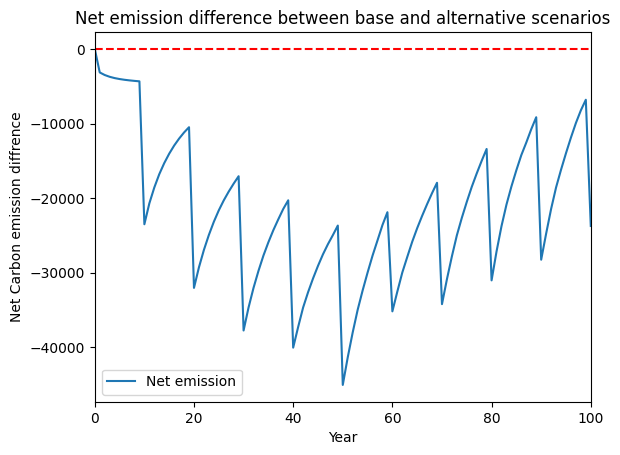

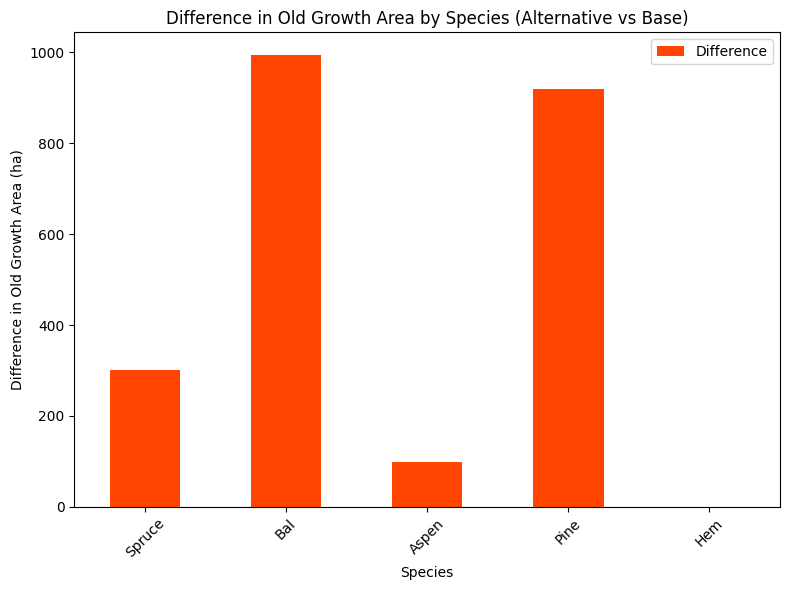

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


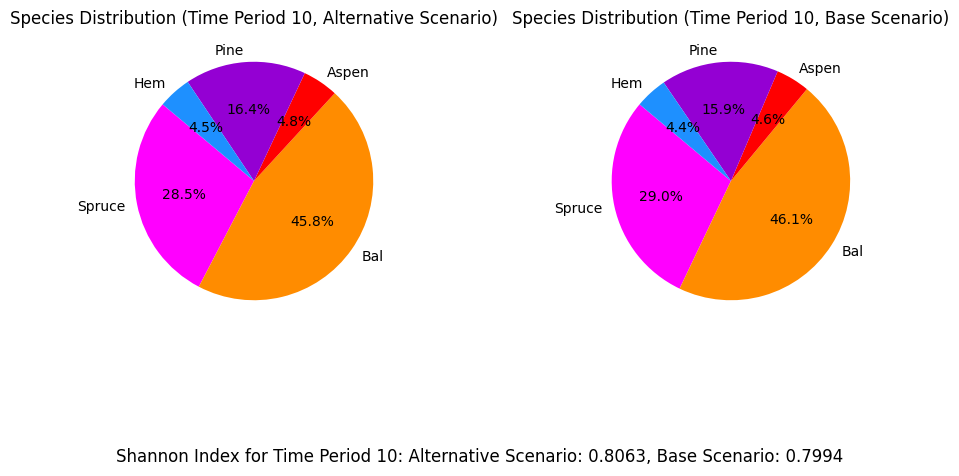

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_80%...
running the scenario for the Golden Bear mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xe798b1b1
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34100 

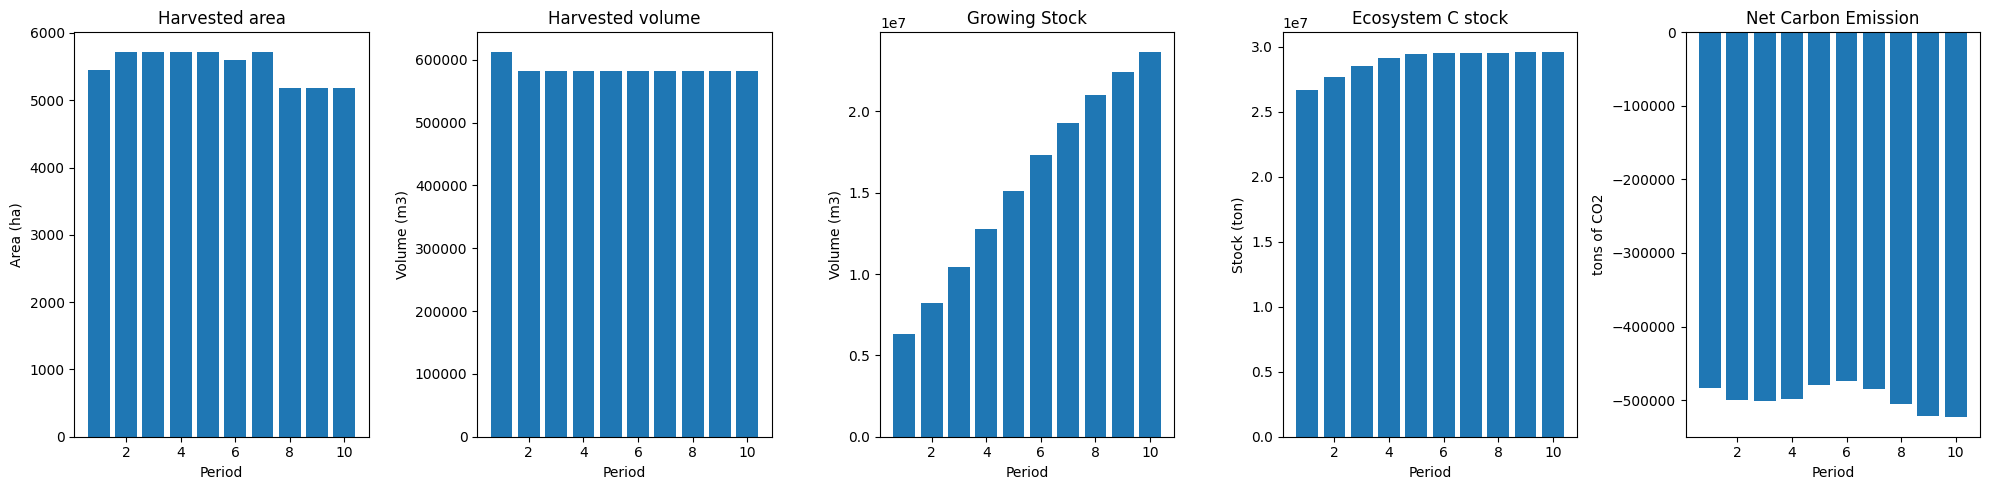

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6187
The economic indicator (the provincial government revenues) is:  211009
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


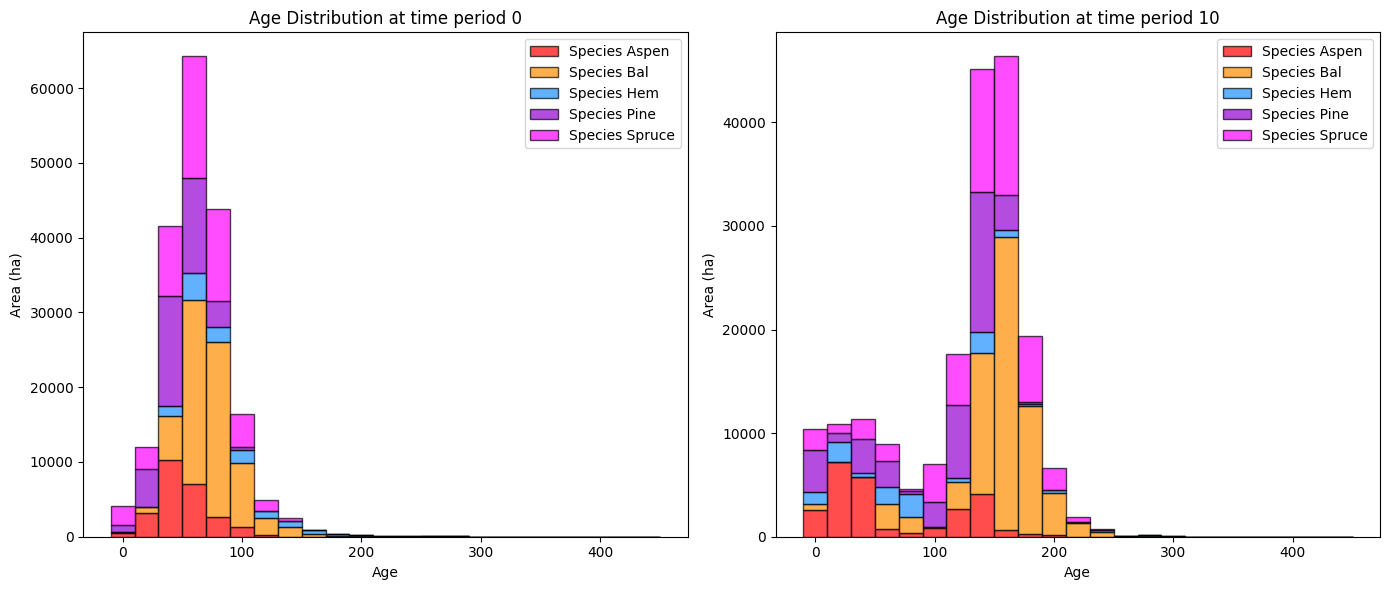

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5914.449954   5911.741421
Bal     278.565372  13018.483783  12739.918411
Aspen   273.490478   2809.975212   2536.484734
Pine      0.000000   4208.791544   4208.791544
Hem     419.699331    707.029353    287.330022

Old growth has **increased** by 25684.27 hectares from time period 0 to time period 10.


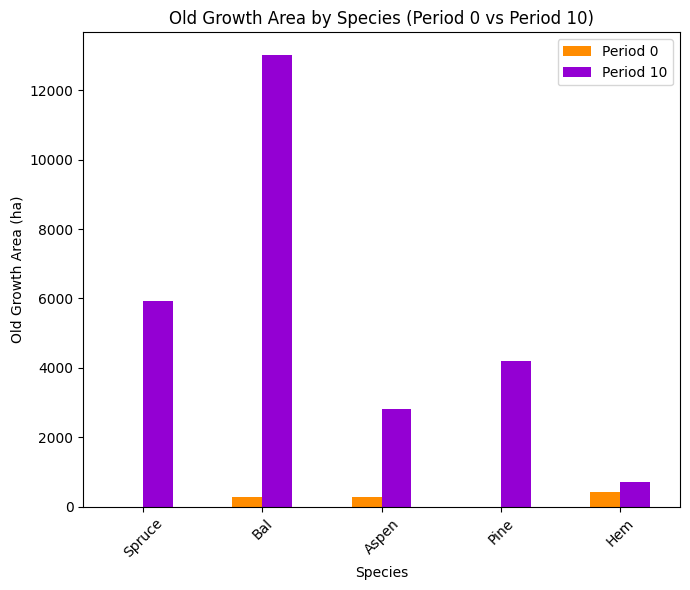

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8219

Diversity has **decreased** by 12.37% from time 0 to time 10.


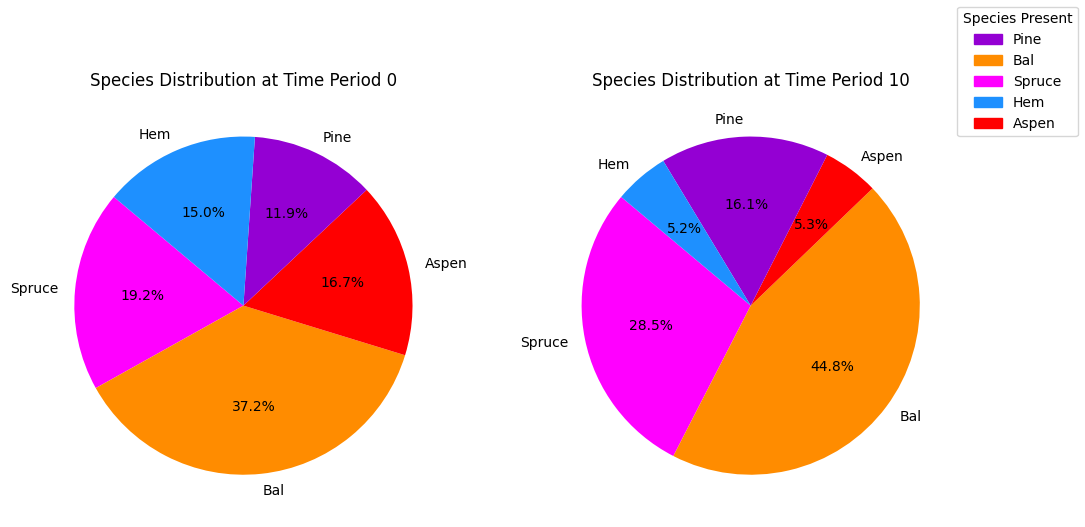

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_80%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

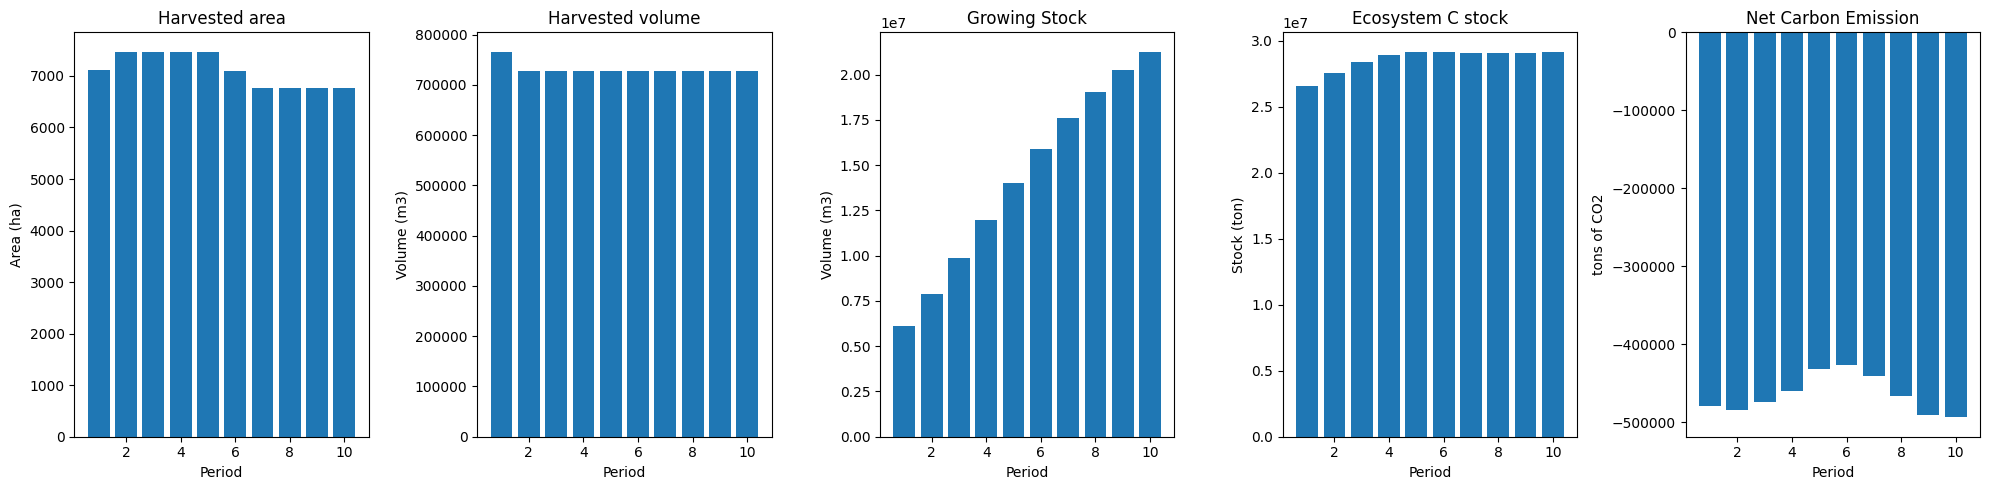

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


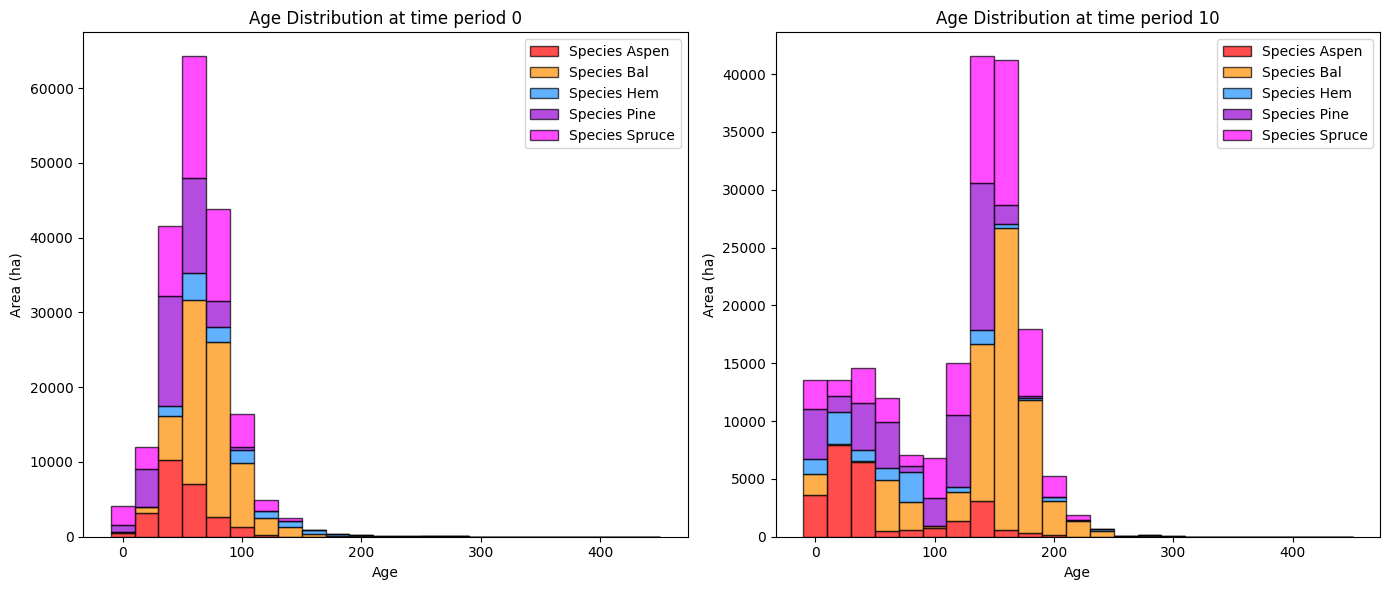

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


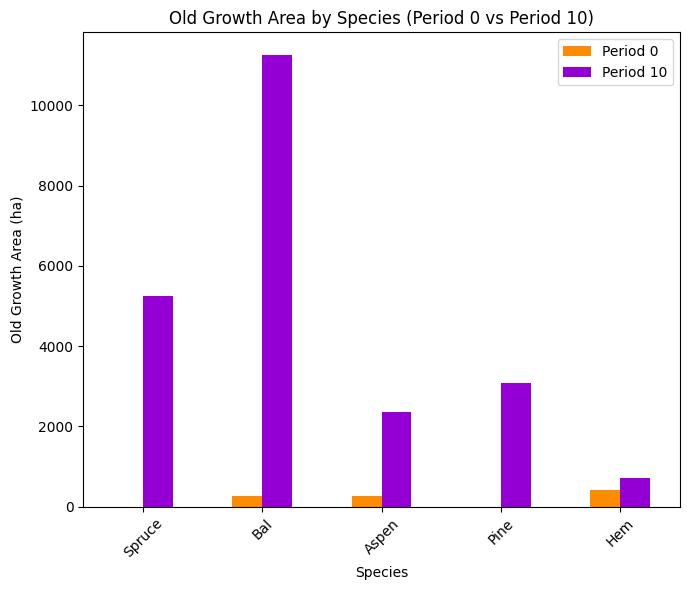

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


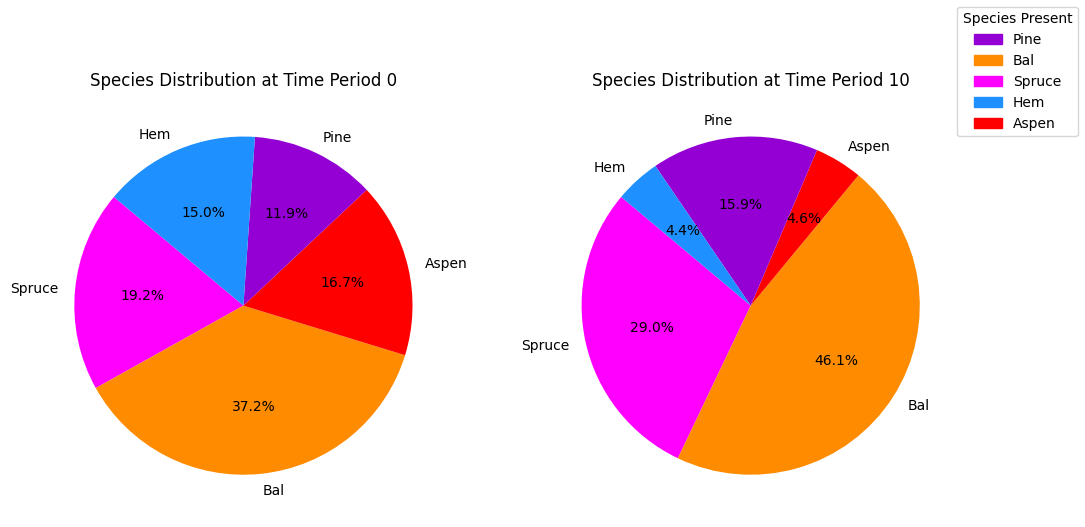

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


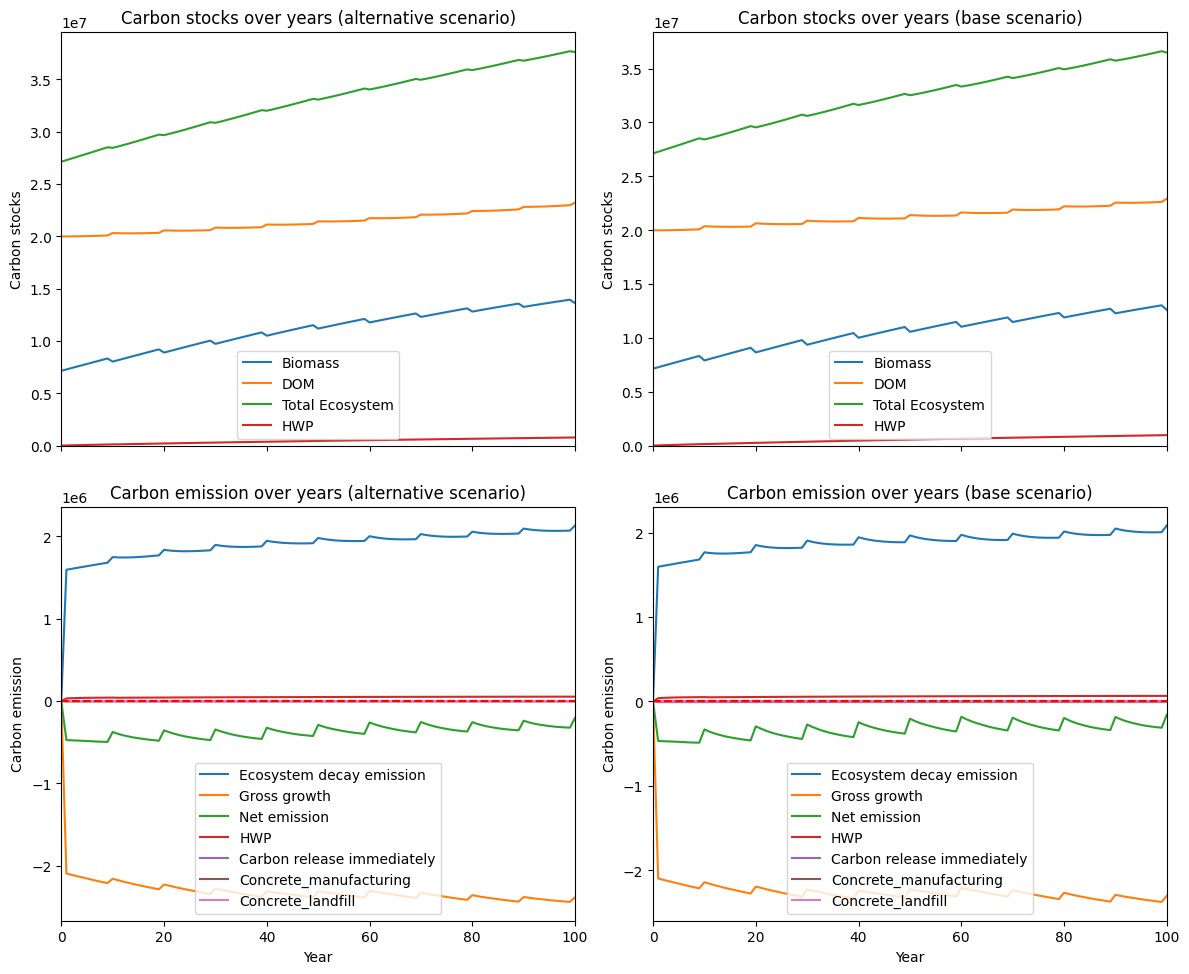

---------------------------------------------------------------------------------------
Net emission difference -4274207.451164148
Net emission base scenario -33239922.163316067
Net emission alternative scenario -37514129.614480205
dollar_per_ton is:  2.3396150313846706
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   671.640240   671.640240
Bal     0.0  1765.489417  1765.489417
Aspen   0.0   460.007637   460.007637
Pine    0.0  1121.595184  1121.595184
Hem     0.0     1.988957     1.988957

Overall, the old growth area has **increased** by 4020.72 hectares in the alternative scenario compared to the base scenario.


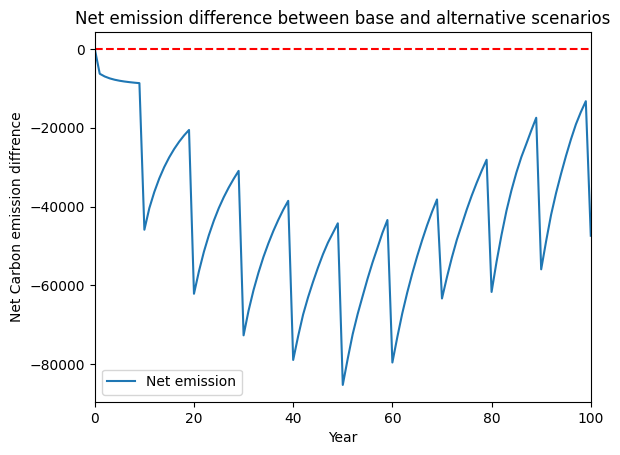

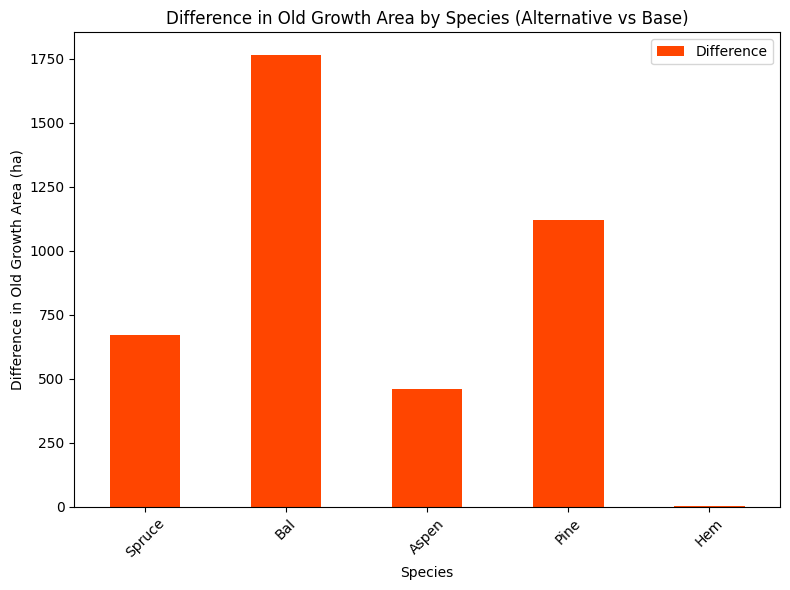

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


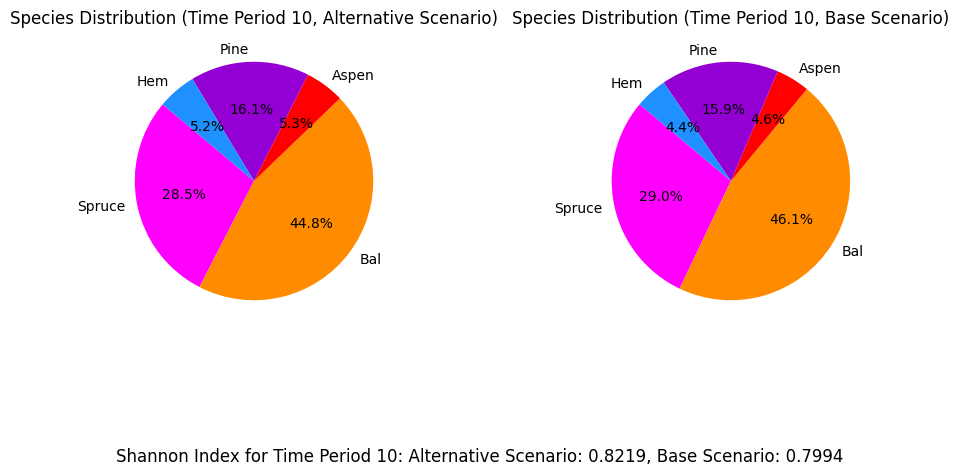

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_70%...
running the scenario for the Golden Bear mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x8d97149c
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

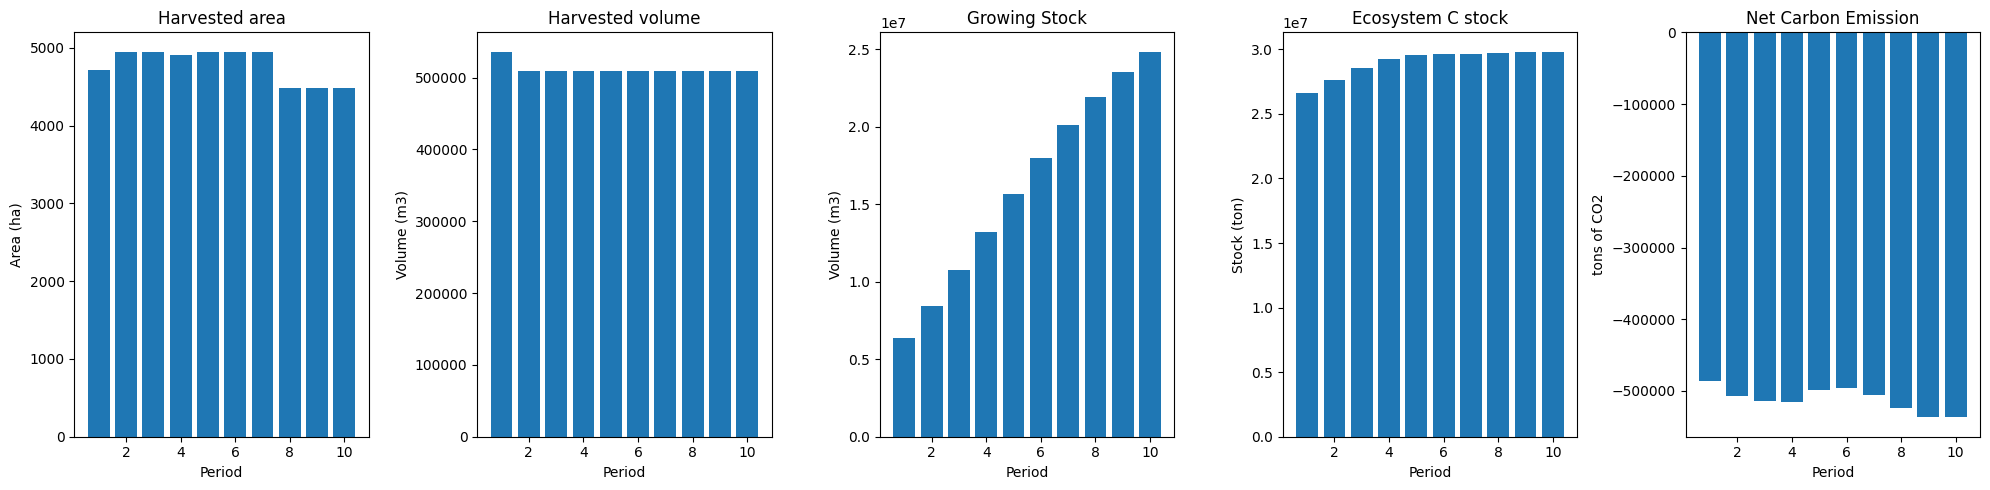

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_70%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  5414
The economic indicator (the provincial government revenues) is:  184633
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


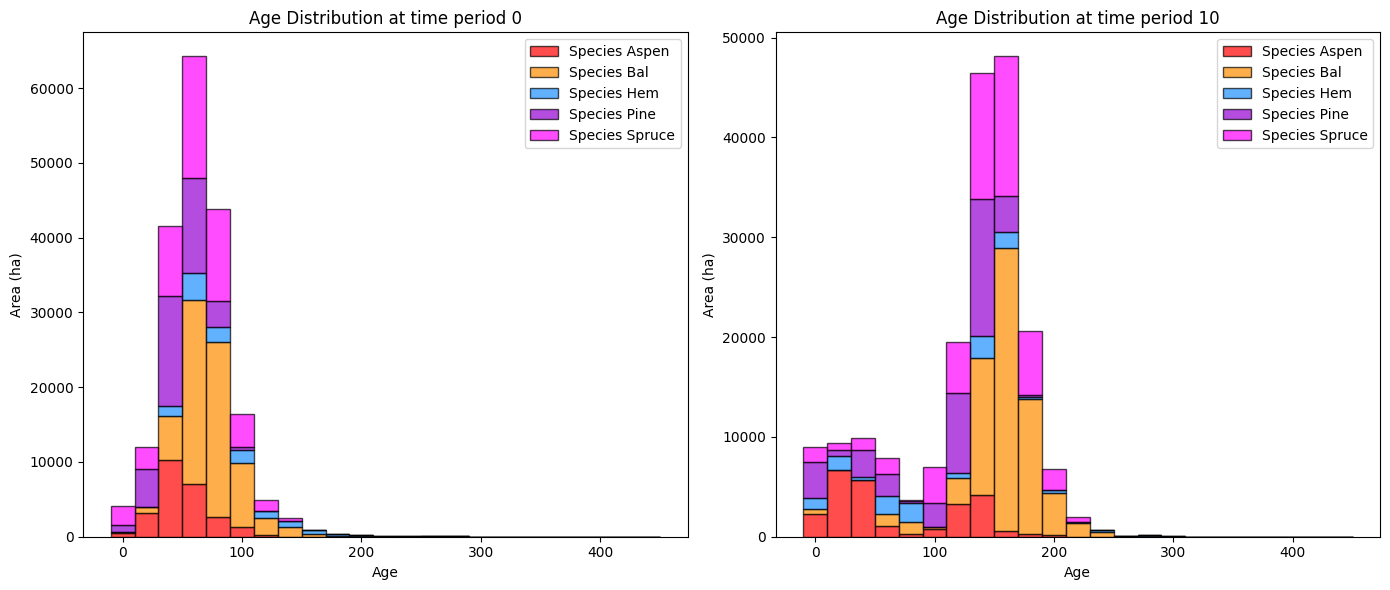

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6177.513265   6174.804731
Bal     278.565372  13845.110548  13566.545176
Aspen   273.490478   2884.175675   2610.685197
Pine      0.000000   4370.536830   4370.536830
Hem     419.699331    726.106495    306.407164

Old growth has **increased** by 27028.98 hectares from time period 0 to time period 10.


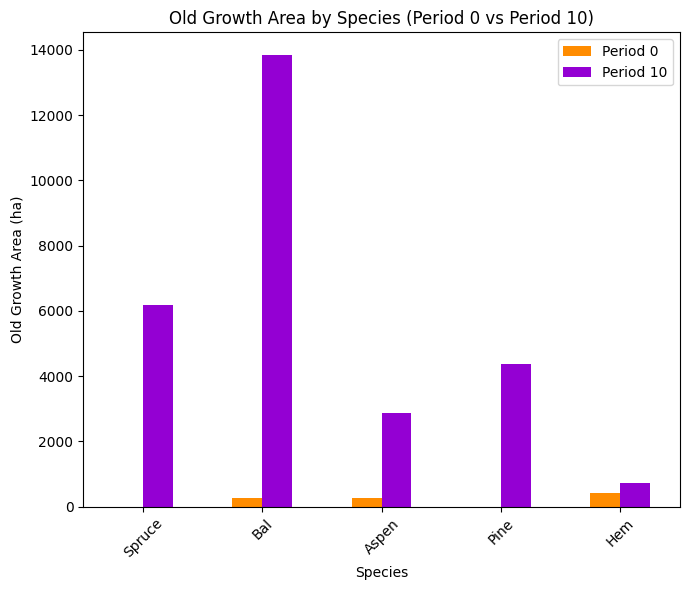

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8351

Diversity has **decreased** by 11.04% from time 0 to time 10.


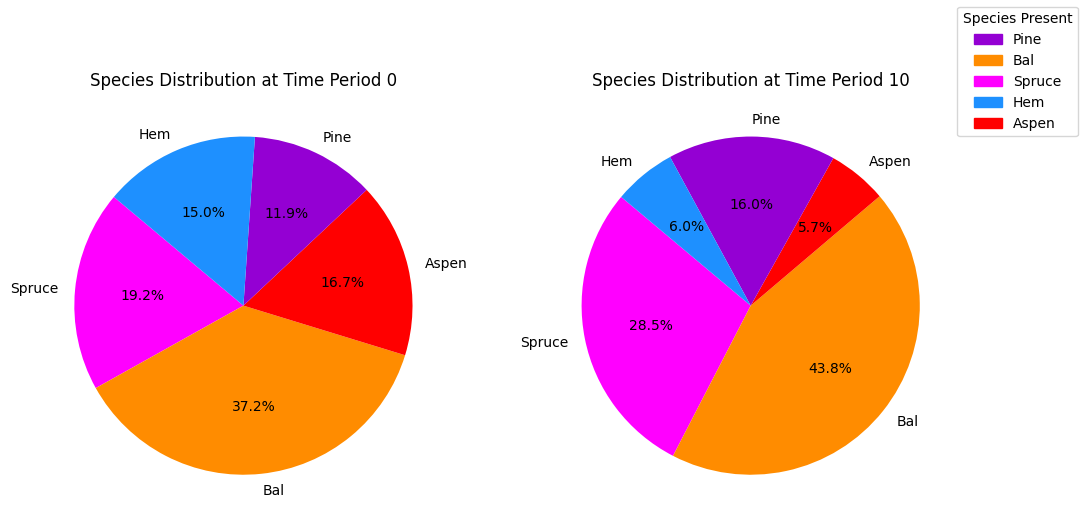

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_70%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

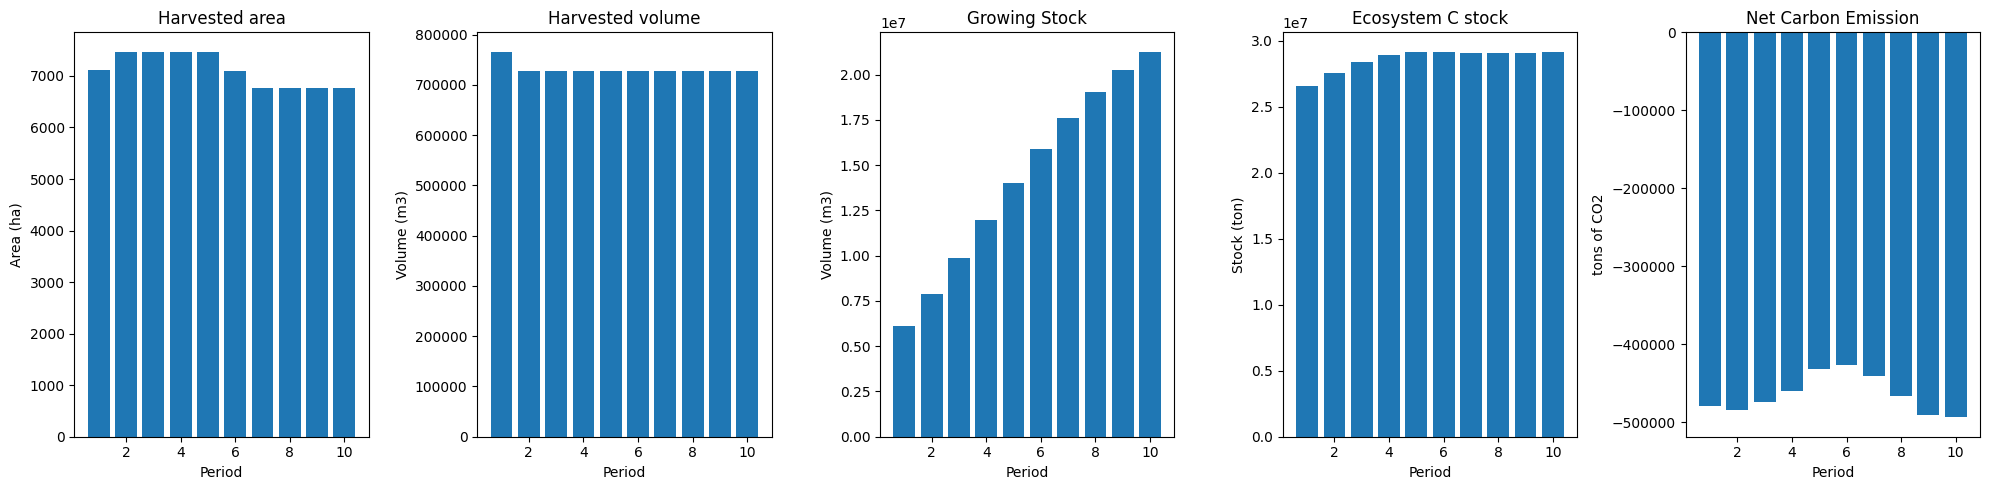

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


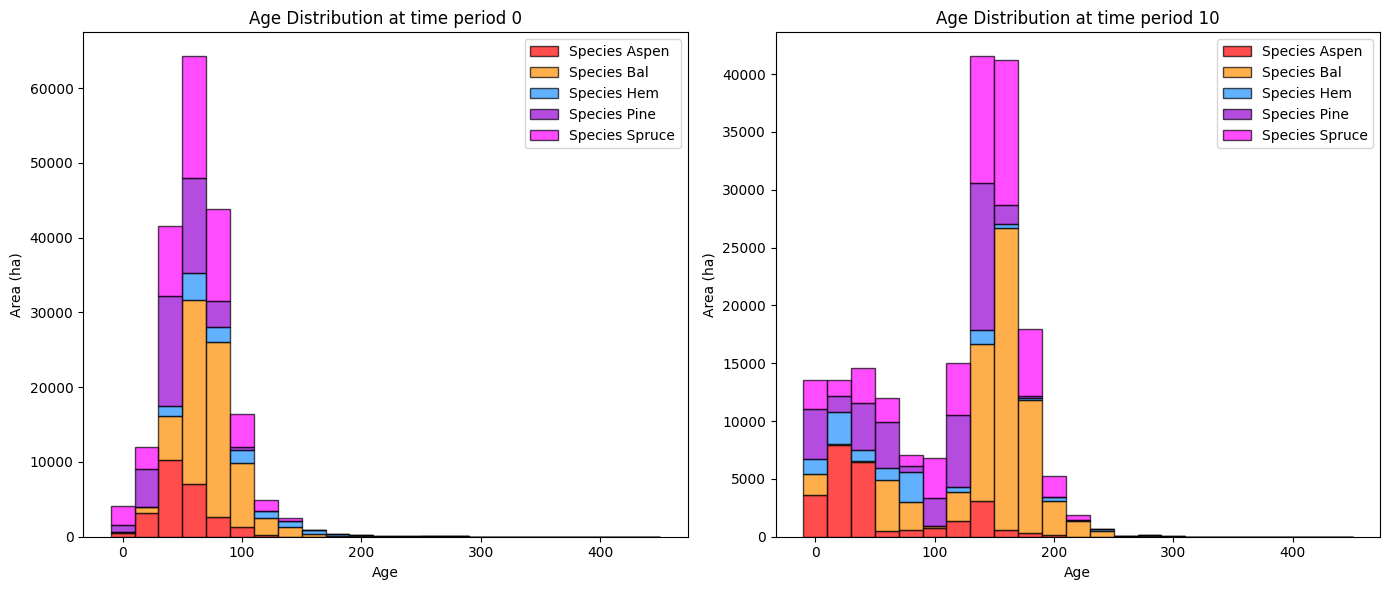

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


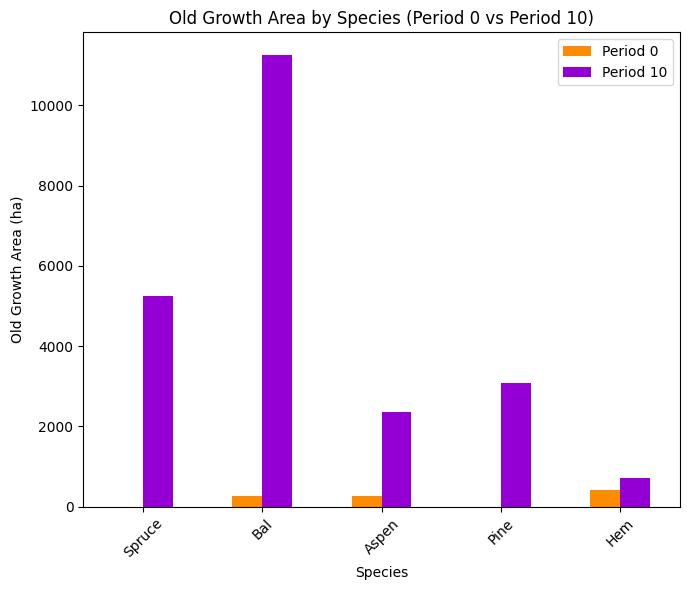

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


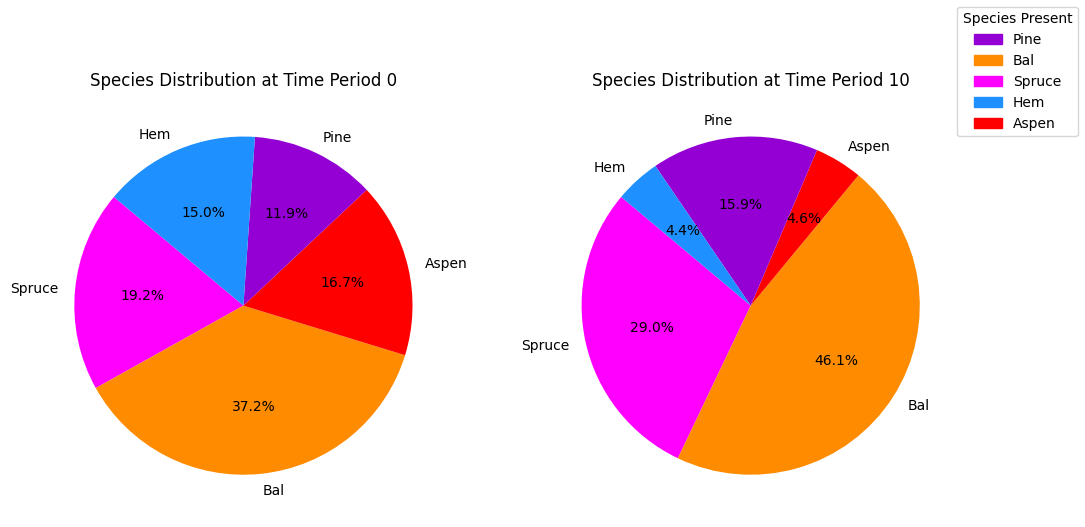

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


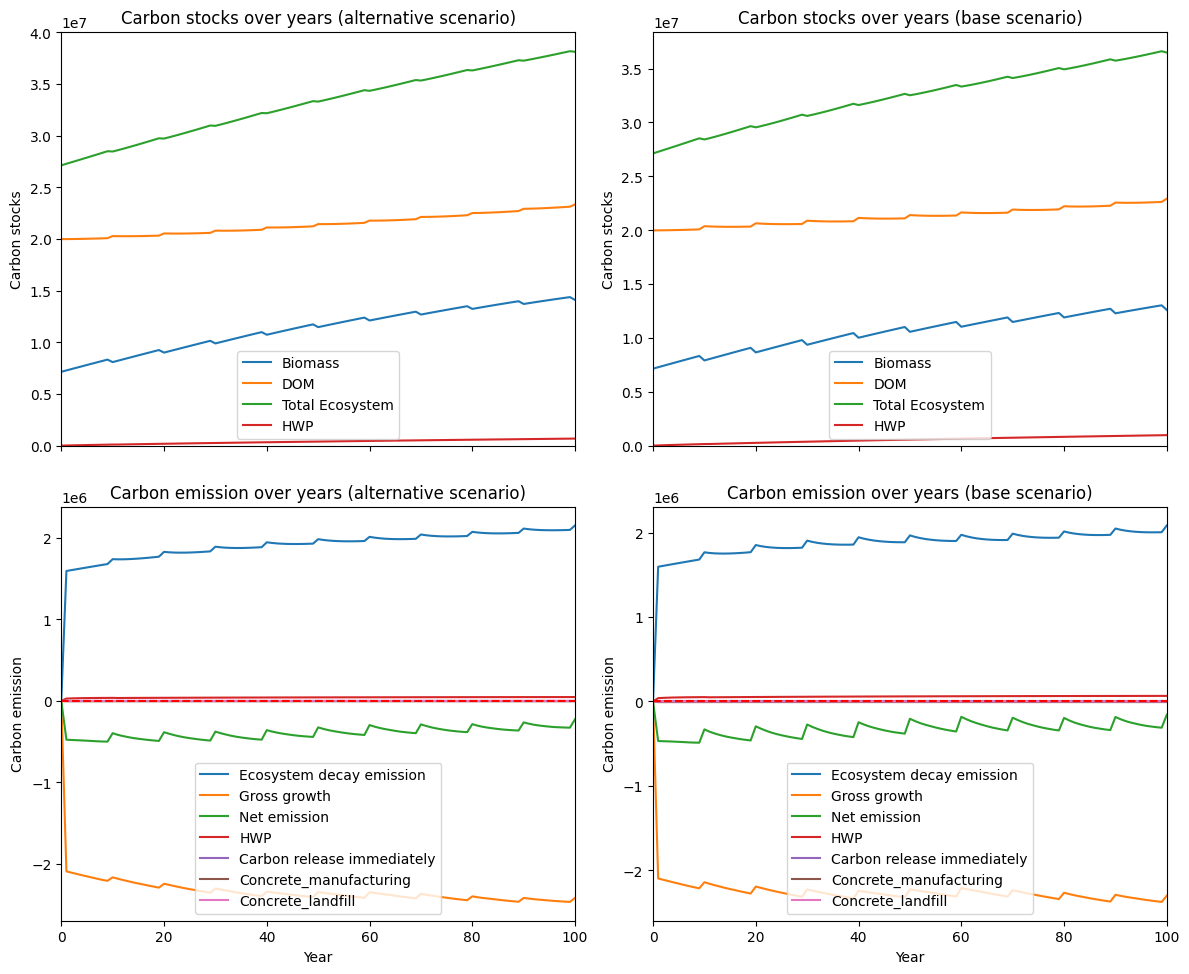

---------------------------------------------------------------------------------------
Net emission difference -6255060.899812601
Net emission base scenario -33239922.163316067
Net emission alternative scenario -39494983.06312865
dollar_per_ton is:  1.5987054578956372
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   934.703550   934.703550
Bal     0.0  2592.116183  2592.116183
Aspen   0.0   534.208099   534.208099
Pine    0.0  1283.340469  1283.340469
Hem     0.0    21.066099    21.066099

Overall, the old growth area has **increased** by 5365.43 hectares in the alternative scenario compared to the base scenario.


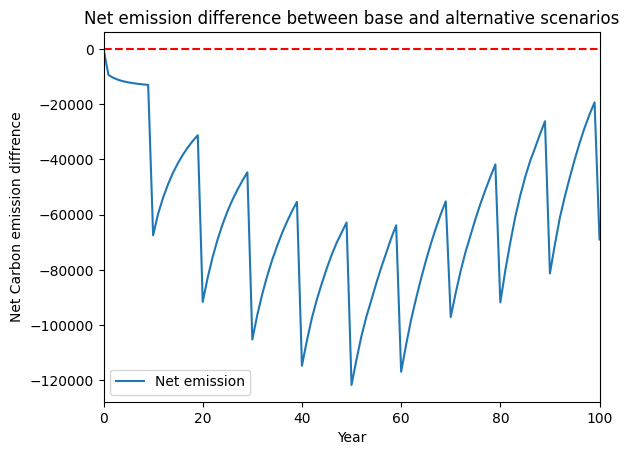

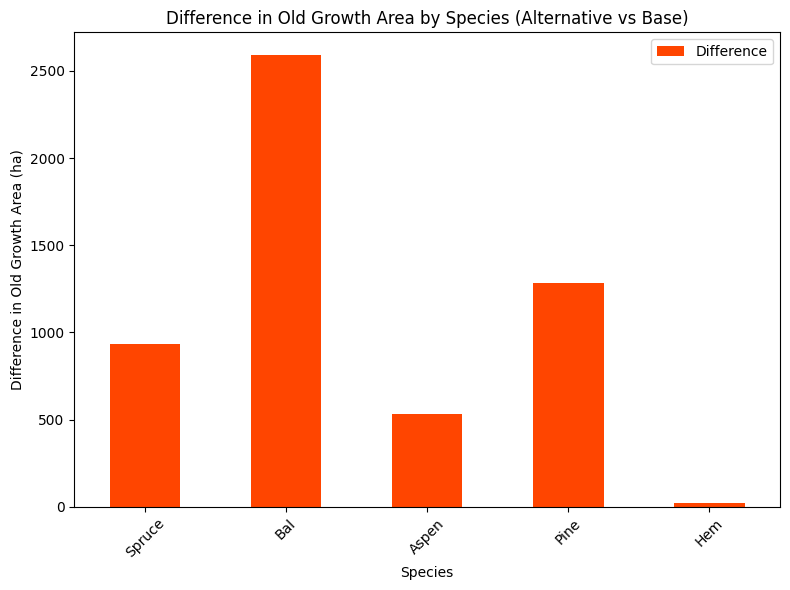

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


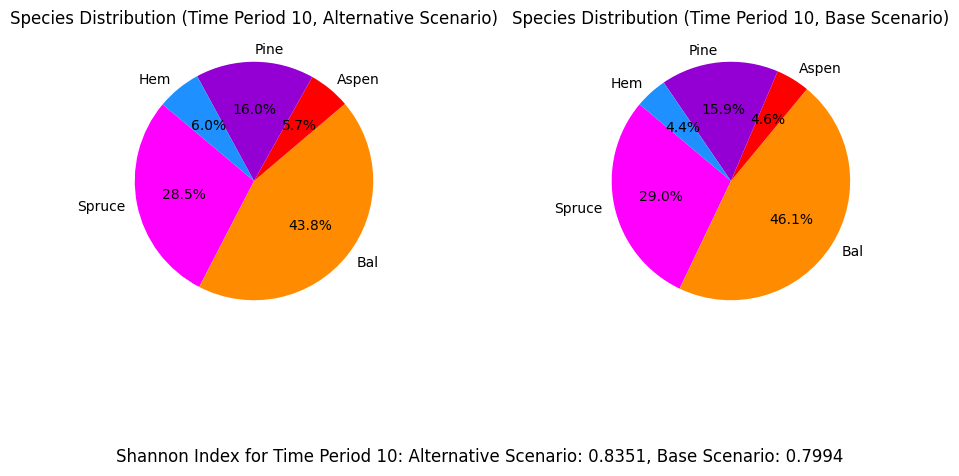

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_60%...
running the scenario for the Golden Bear mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xd40276d9
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.18s
Presolved: 1911 rows, 34100 

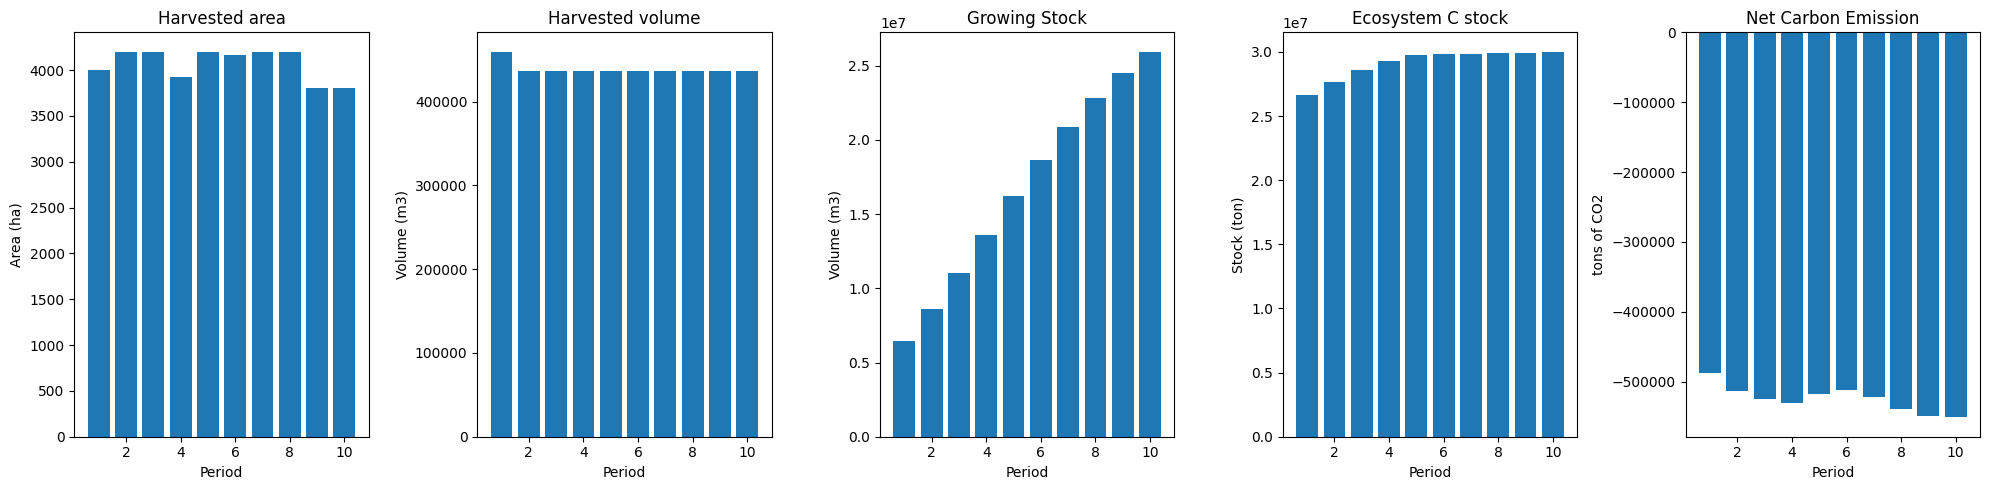

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_60%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  4640
The economic indicator (the provincial government revenues) is:  158257
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


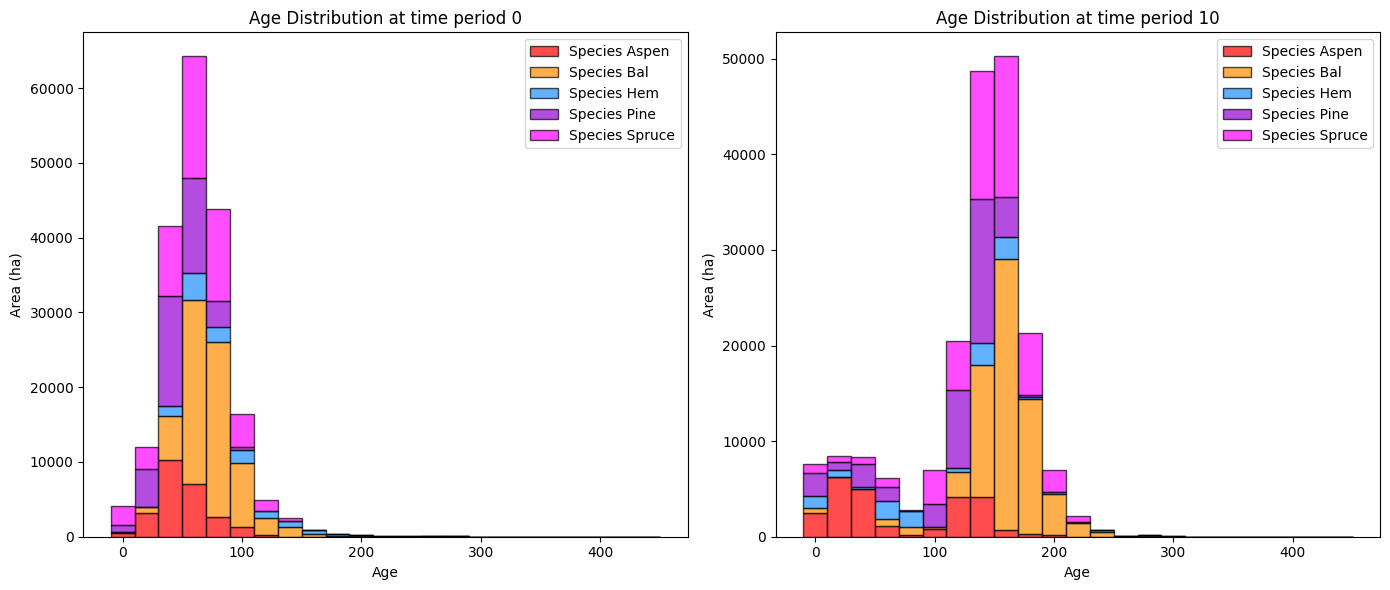

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6661.603565   6658.895031
Bal     278.565372  14383.447781  14104.882409
Aspen   273.490478   3065.543469   2792.052991
Pine      0.000000   4812.040866   4812.040866
Hem     419.699331    778.279354    358.580024

Old growth has **increased** by 28726.45 hectares from time period 0 to time period 10.


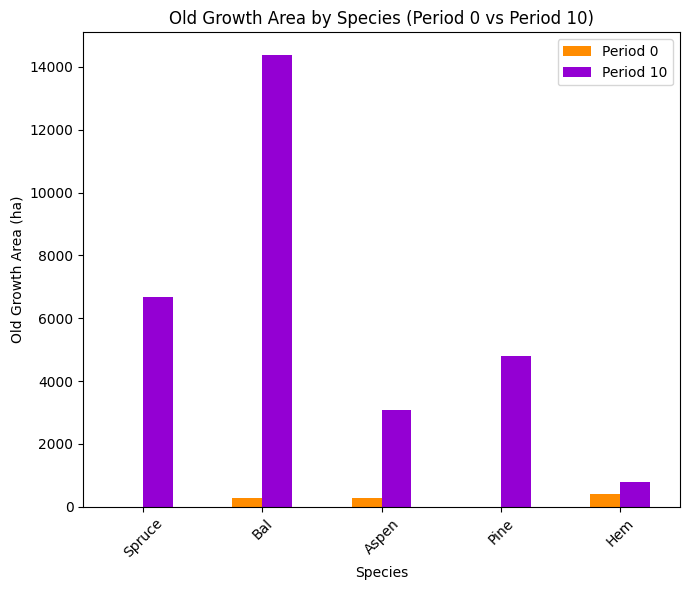

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8477

Diversity has **decreased** by 9.79% from time 0 to time 10.


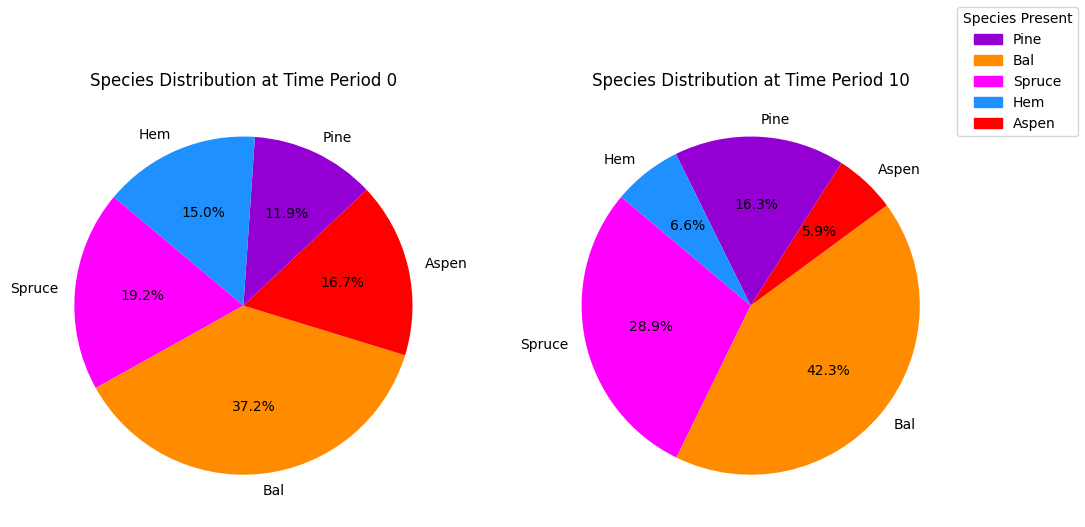

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_60%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

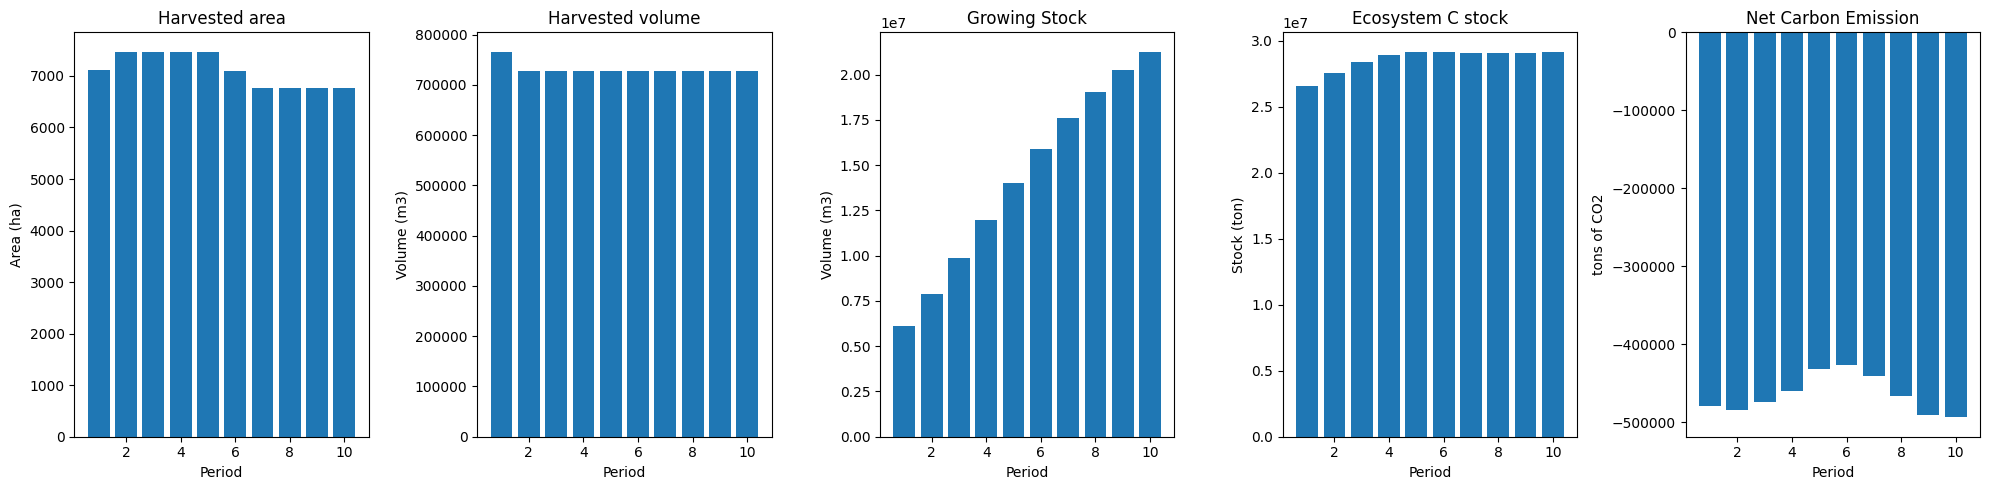

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


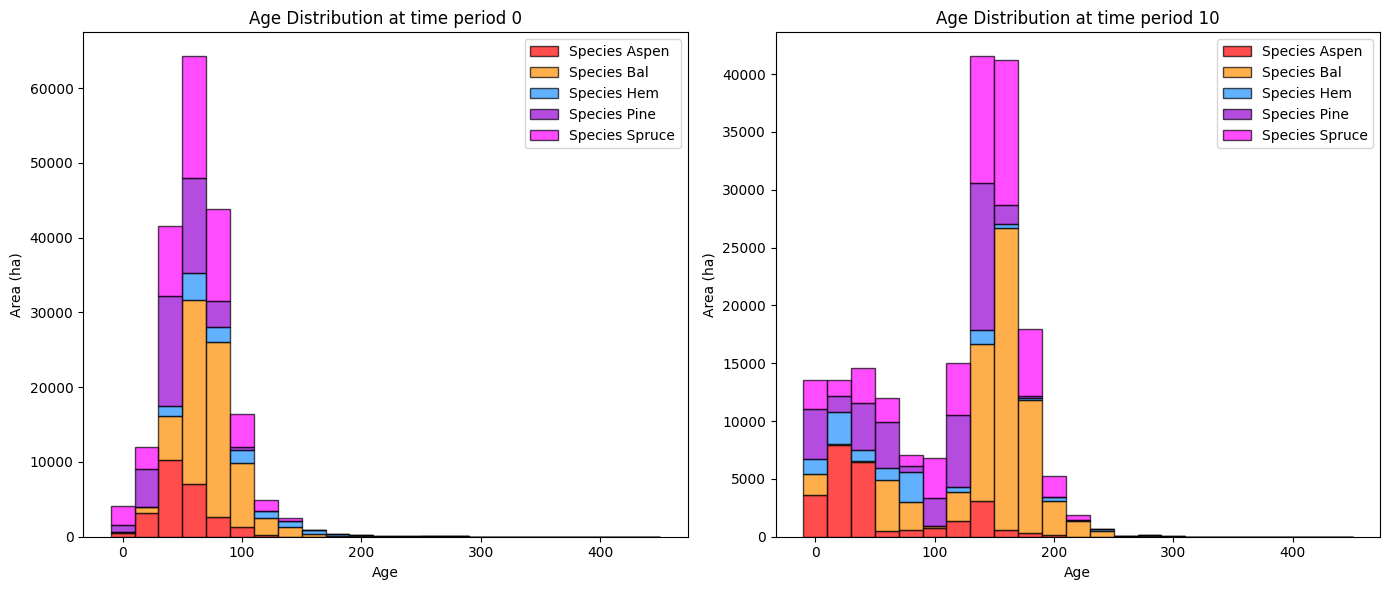

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


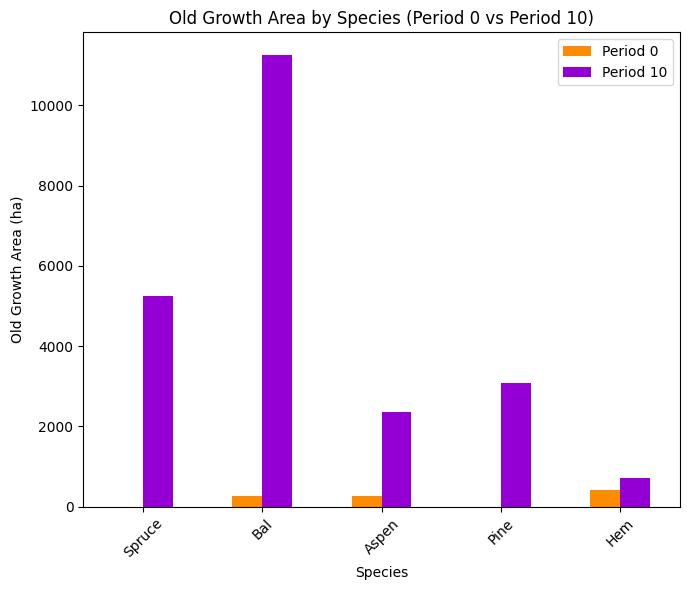

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


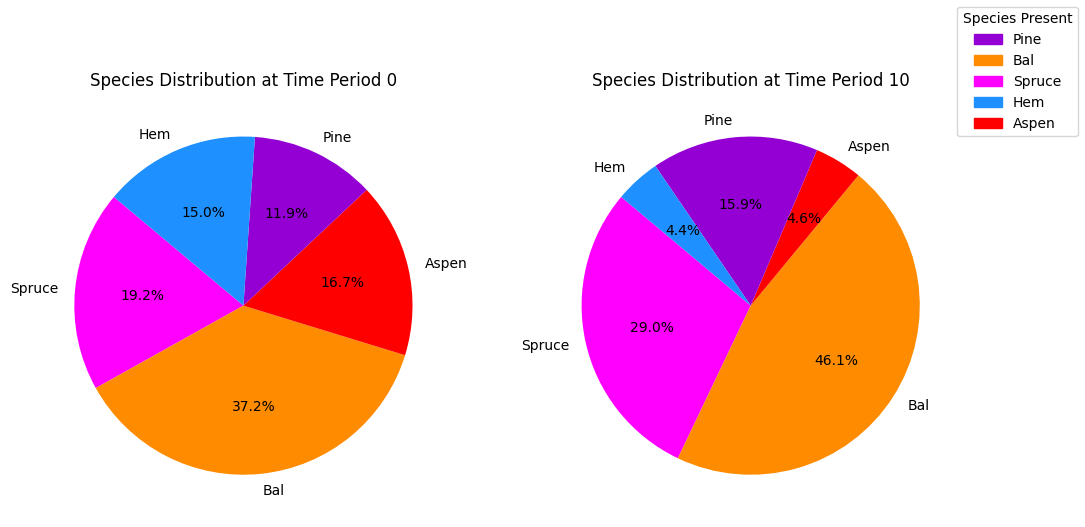

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


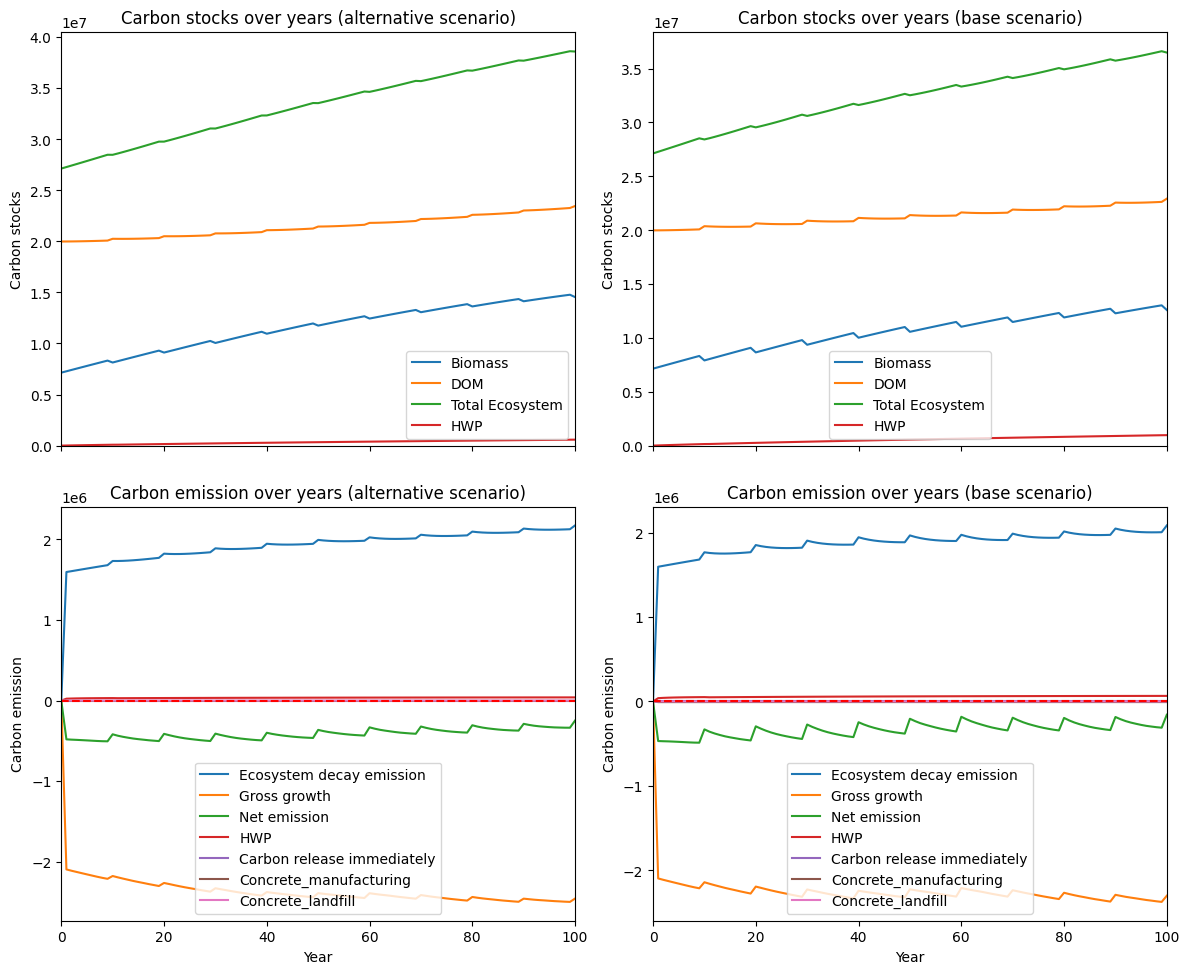

---------------------------------------------------------------------------------------
Net emission difference -8104934.548813607
Net emission base scenario -33239922.163316067
Net emission alternative scenario -41344856.71212967
dollar_per_ton is:  1.2338162559824486
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1418.793850  1418.793850
Bal     0.0  3130.453416  3130.453416
Aspen   0.0   715.575894   715.575894
Pine    0.0  1724.844506  1724.844506
Hem     0.0    73.238958    73.238958

Overall, the old growth area has **increased** by 7062.91 hectares in the alternative scenario compared to the base scenario.


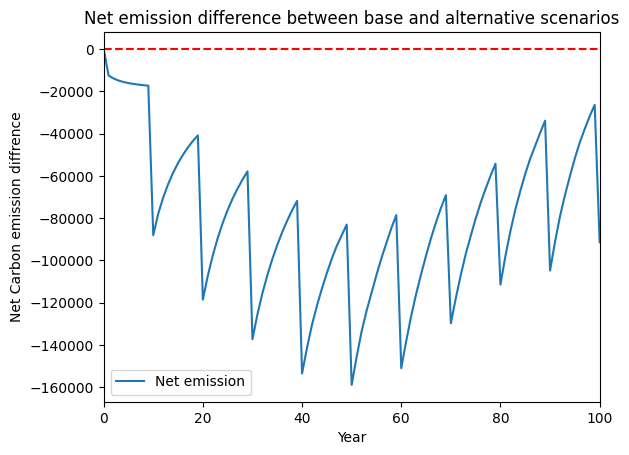

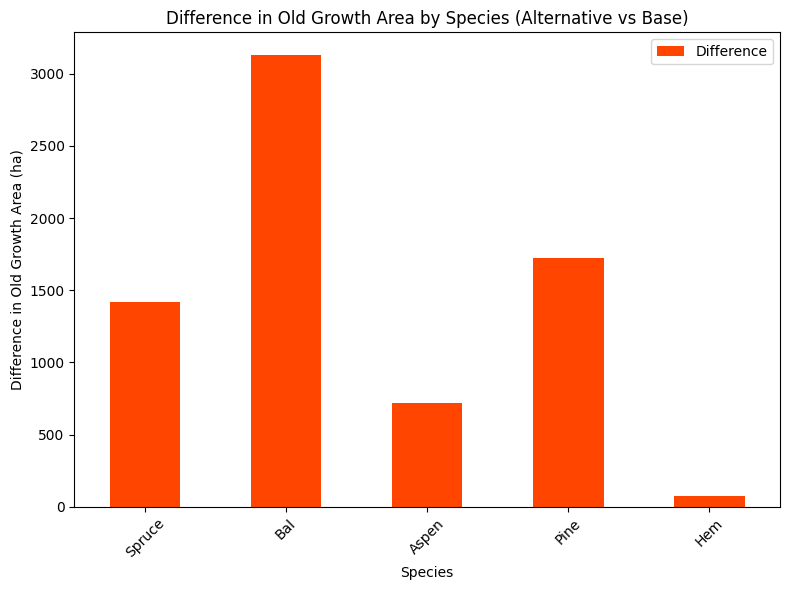

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


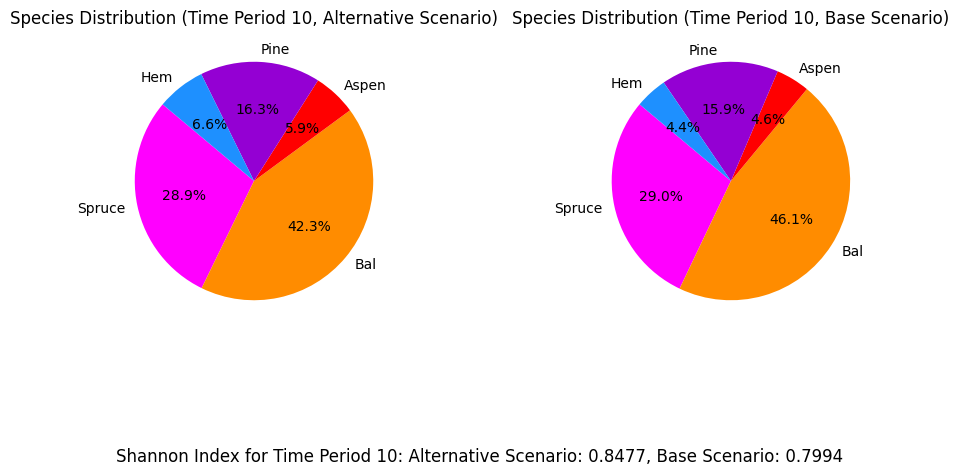

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_50%...
running the scenario for the Golden Bear mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x9ee72f0a
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

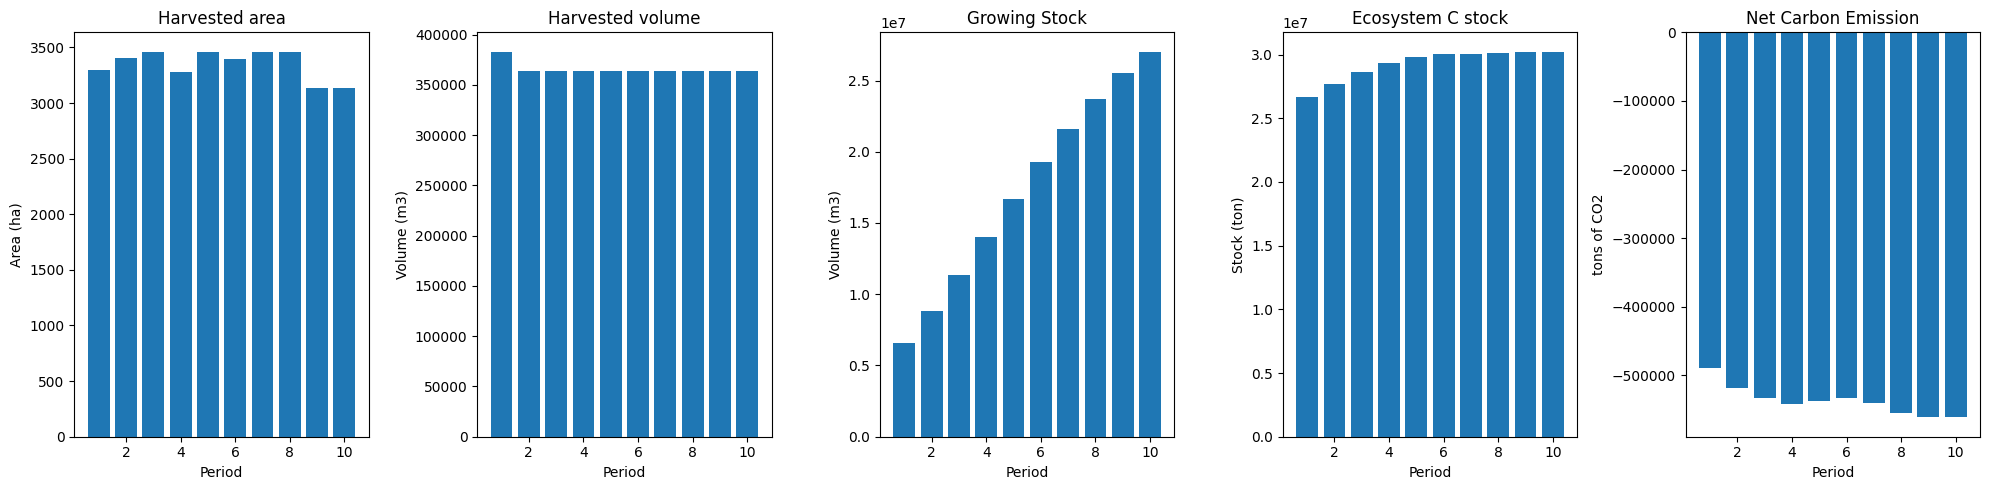

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_50%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3867
The economic indicator (the provincial government revenues) is:  131881
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


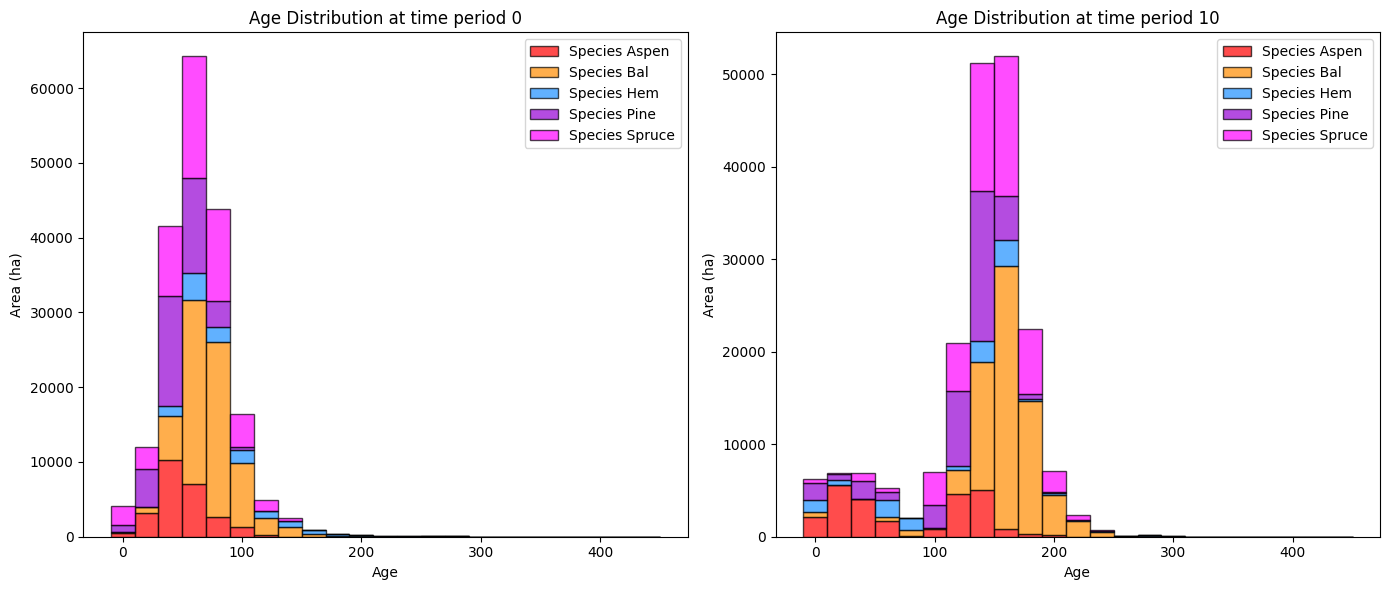

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   7060.895753   7058.187220
Bal     278.565372  14750.842705  14472.277334
Aspen   273.490478   3442.403376   3168.912898
Pine      0.000000   5635.847355   5635.847355
Hem     419.699331    867.291535    447.592205

Old growth has **increased** by 30782.82 hectares from time period 0 to time period 10.


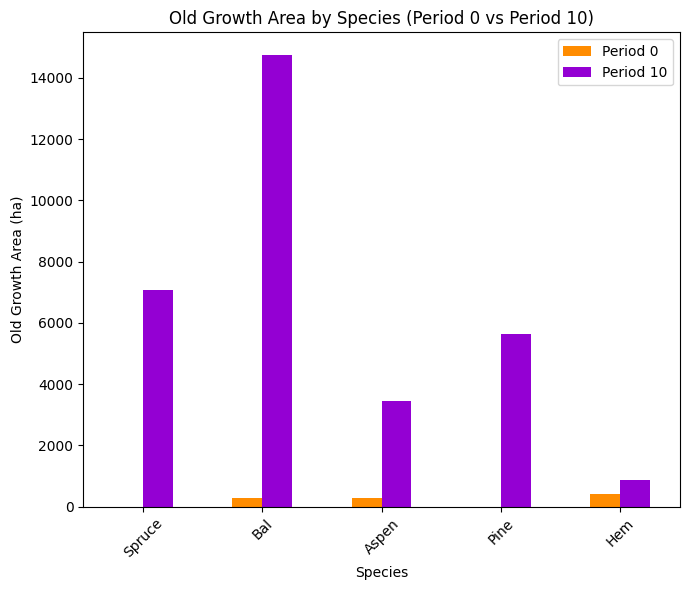

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8621

Diversity has **decreased** by 8.34% from time 0 to time 10.


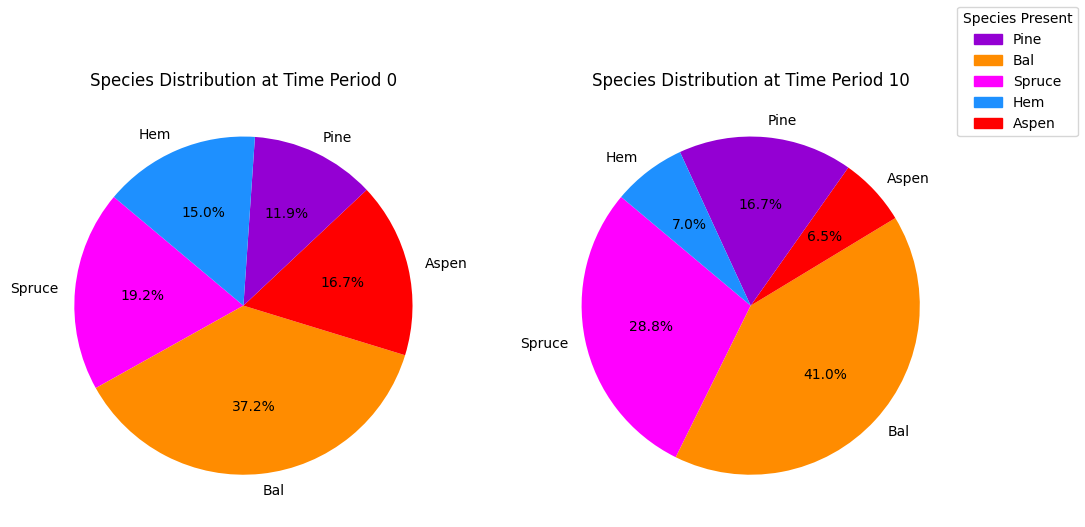

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_50%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

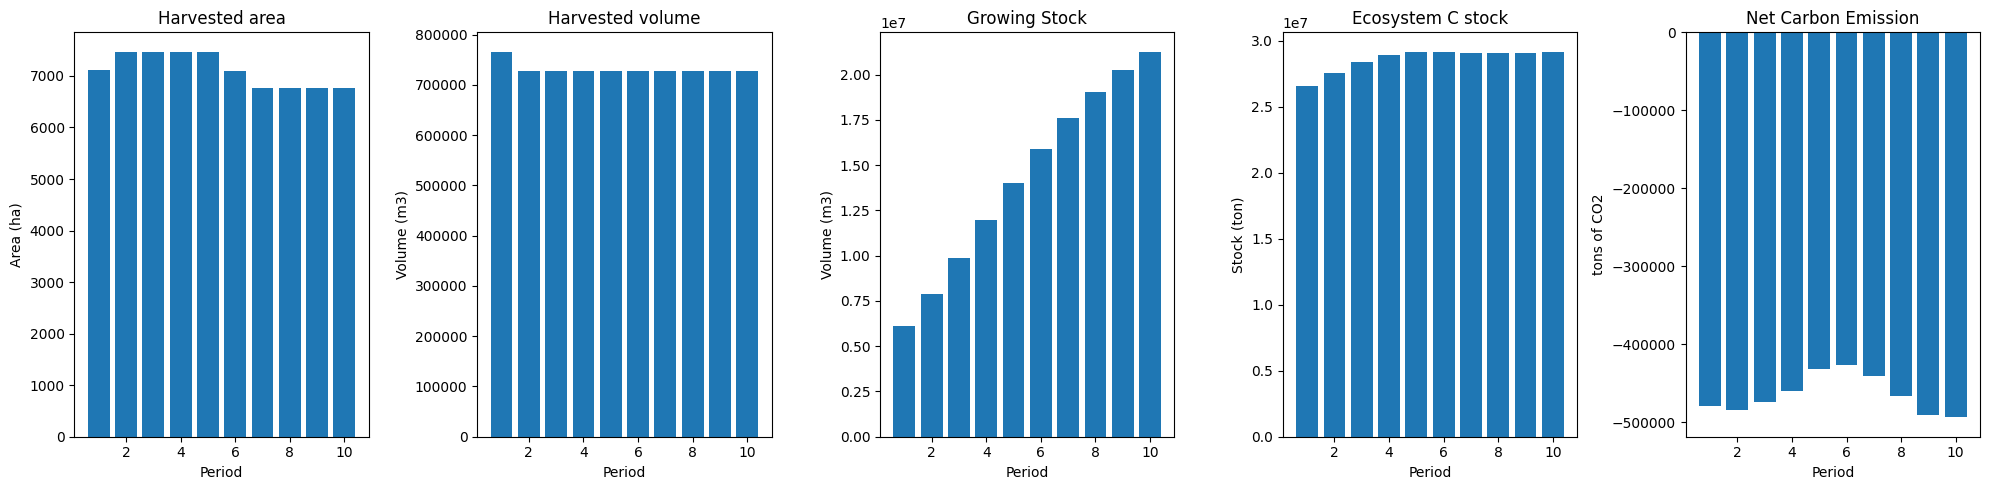

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


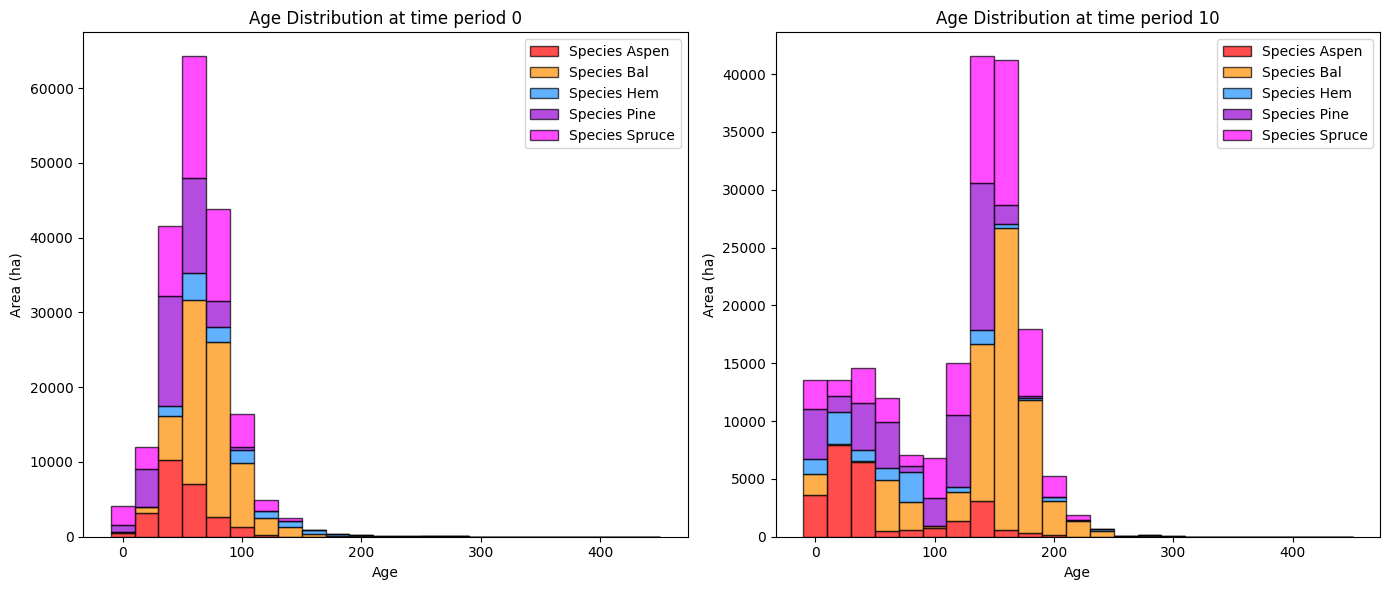

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


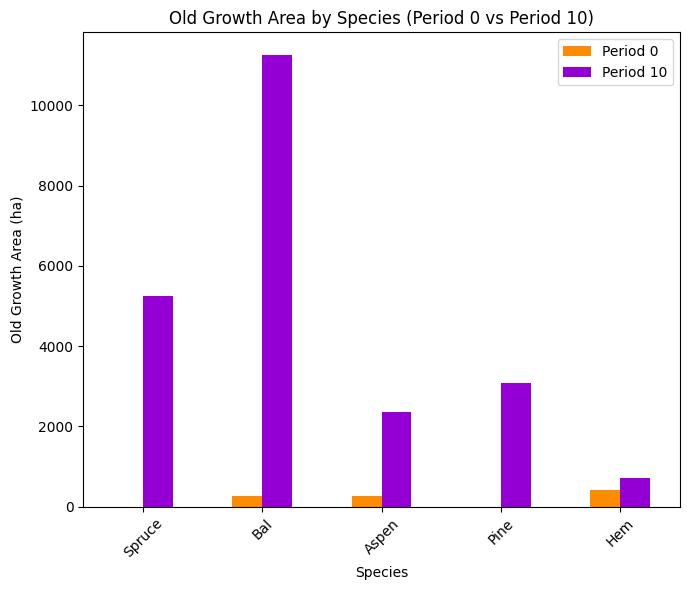

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


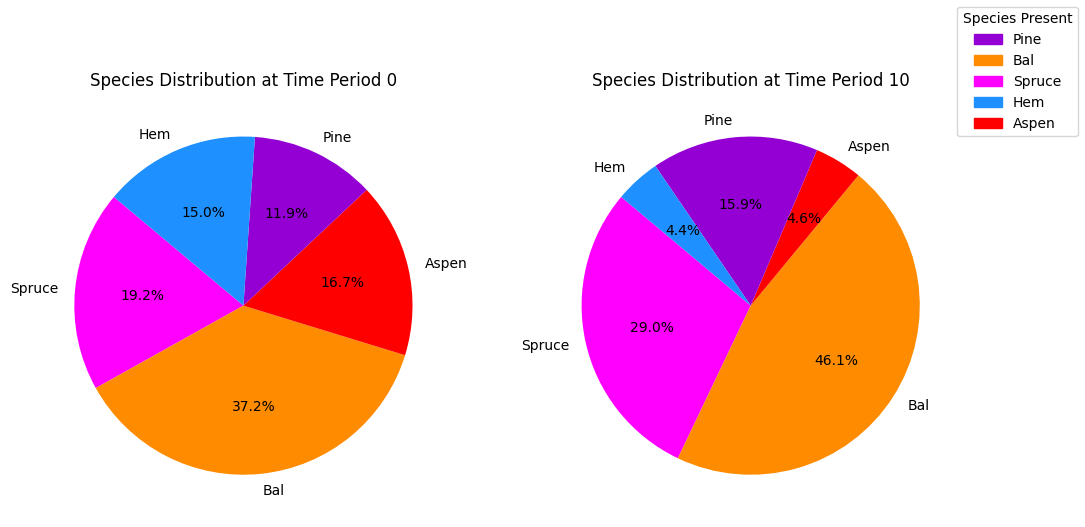

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


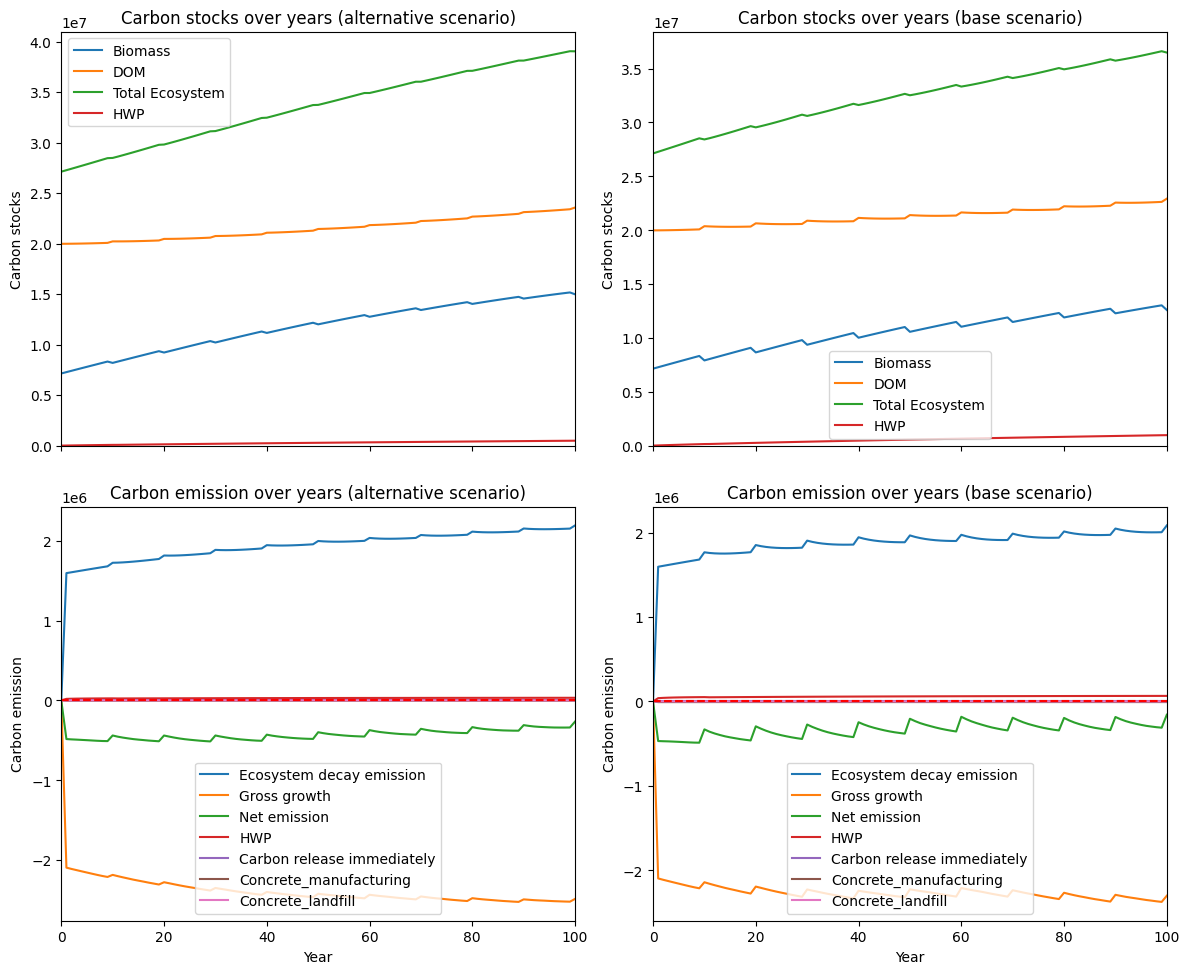

---------------------------------------------------------------------------------------
Net emission difference -9902712.625467183
Net emission base scenario -33239922.163316067
Net emission alternative scenario -43142634.78878324
dollar_per_ton is:  1.0098243156408093
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1818.086039  1818.086039
Bal     0.0  3497.848340  3497.848340
Aspen   0.0  1092.435801  1092.435801
Pine    0.0  2548.650995  2548.650995
Hem     0.0   162.251139   162.251139

Overall, the old growth area has **increased** by 9119.27 hectares in the alternative scenario compared to the base scenario.


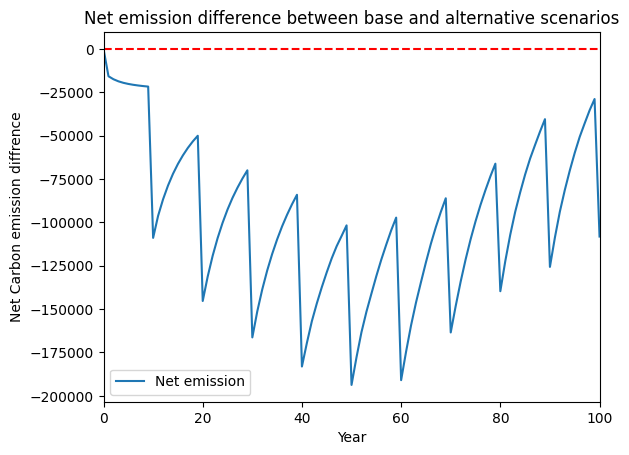

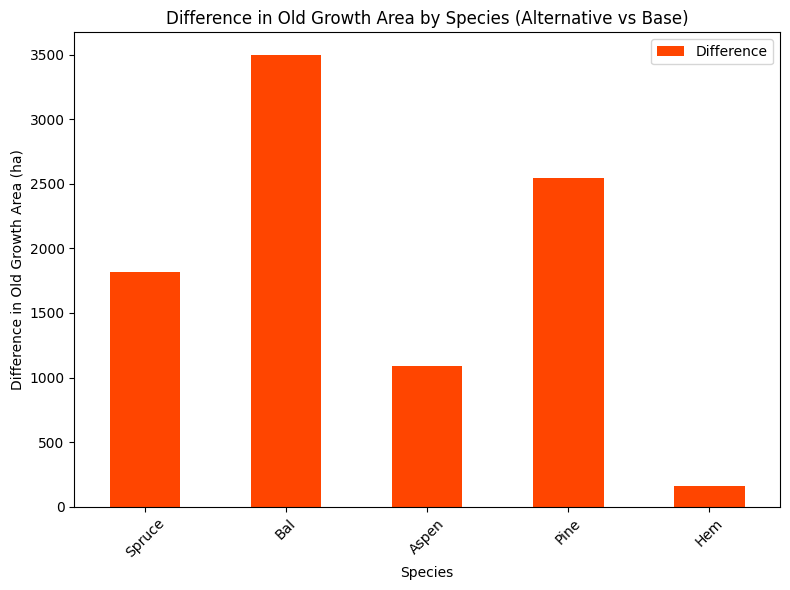

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


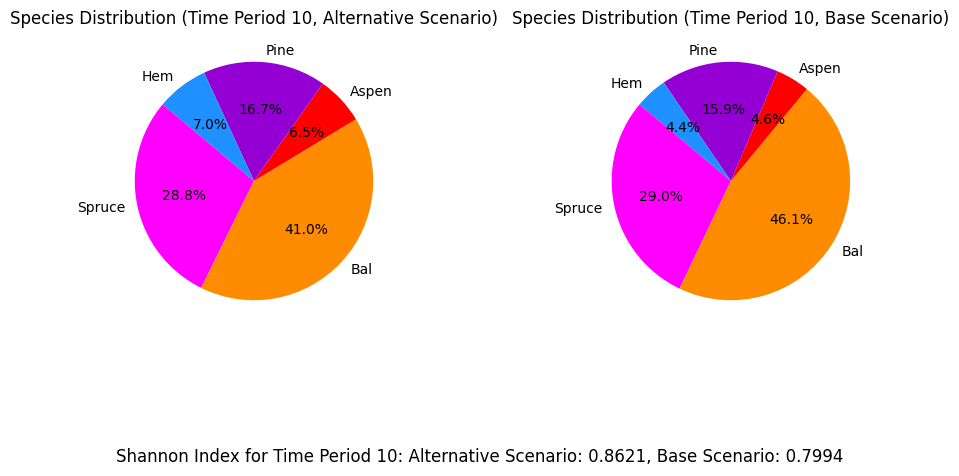

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_40%...
running the scenario for the Golden Bear mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x17813f91
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.19s
Presolved: 1911 rows, 34100 

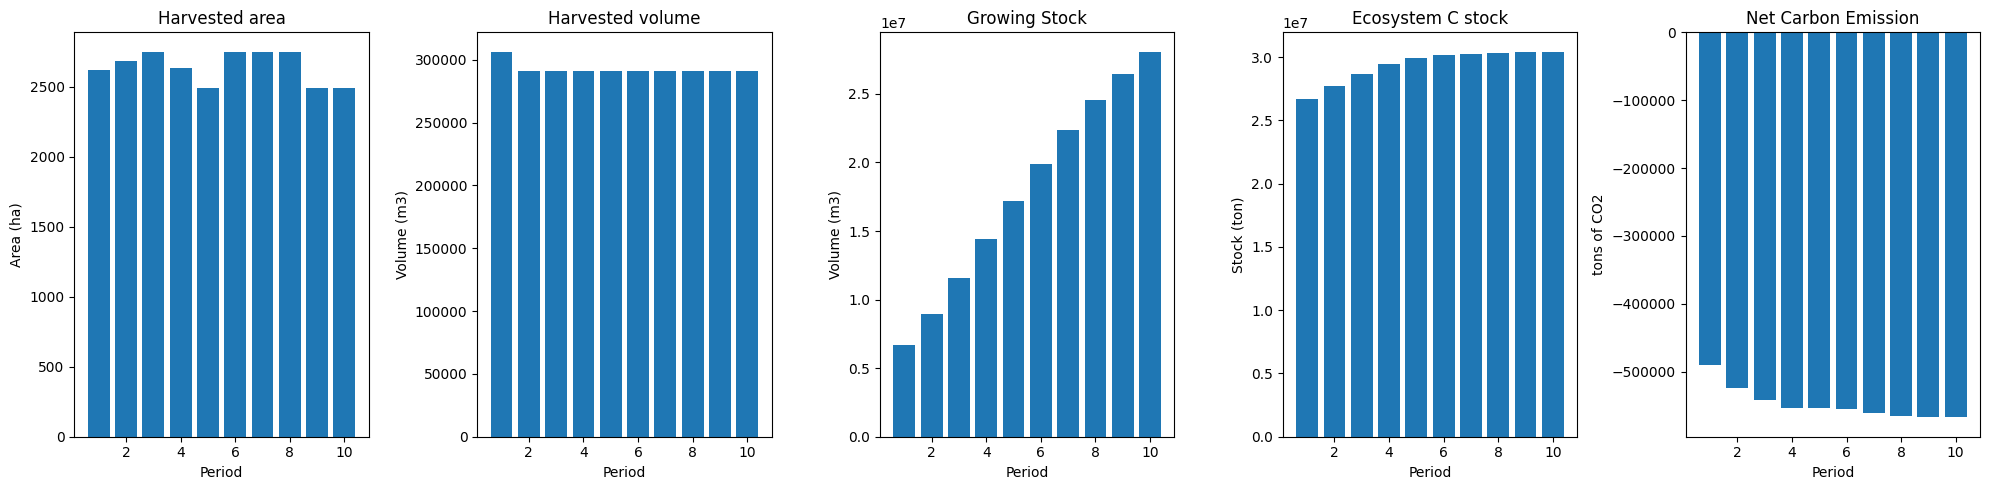

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_40%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3093
The economic indicator (the provincial government revenues) is:  105504
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


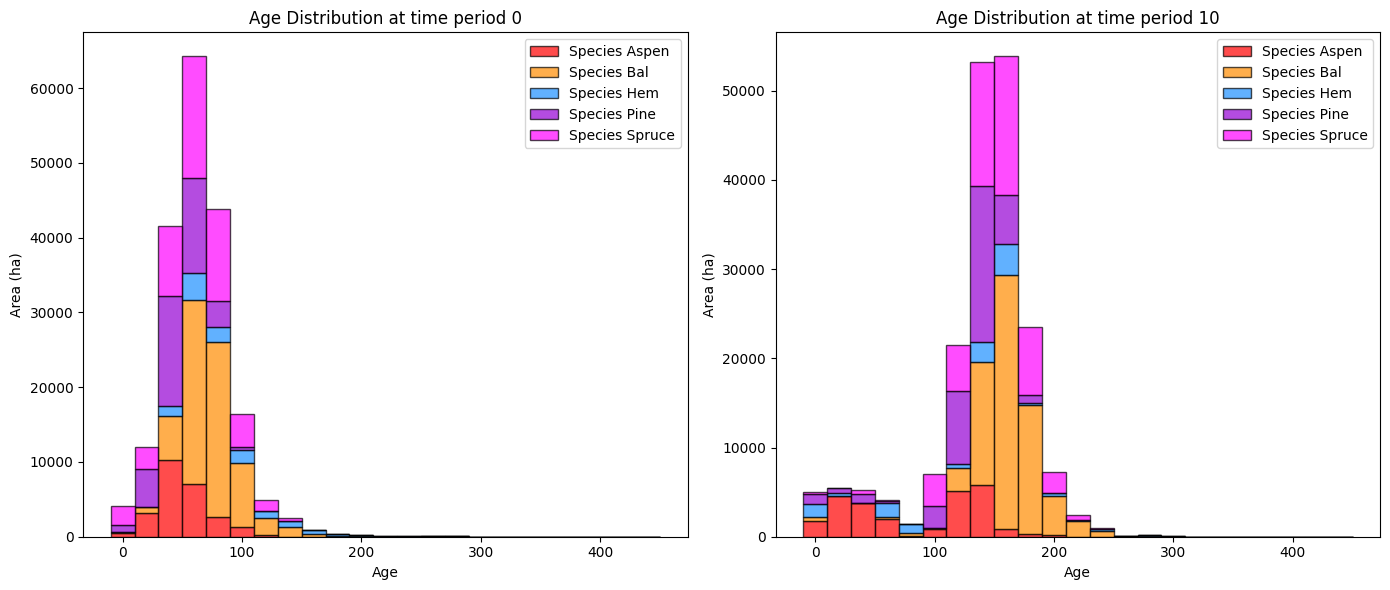

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   7479.104707   7476.396174
Bal     278.565372  15284.440574  15005.875202
Aspen   273.490478   3977.509914   3704.019436
Pine      0.000000   6510.147118   6510.147118
Hem     419.699331    969.361679    549.662348

Old growth has **increased** by 33246.10 hectares from time period 0 to time period 10.


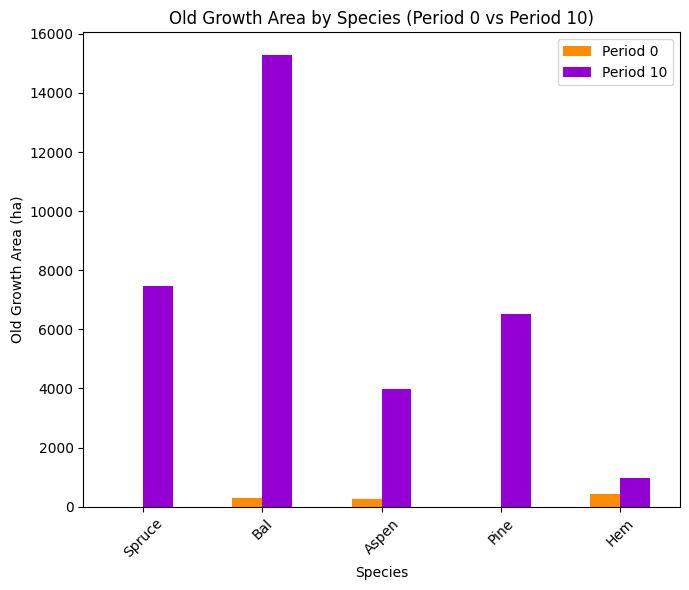

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8756

Diversity has **decreased** by 6.99% from time 0 to time 10.


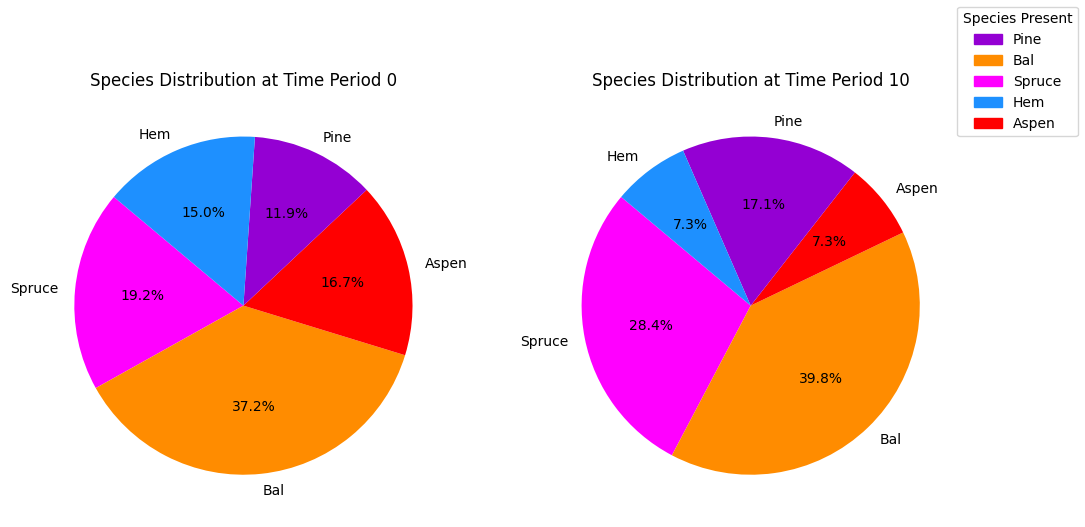

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_40%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

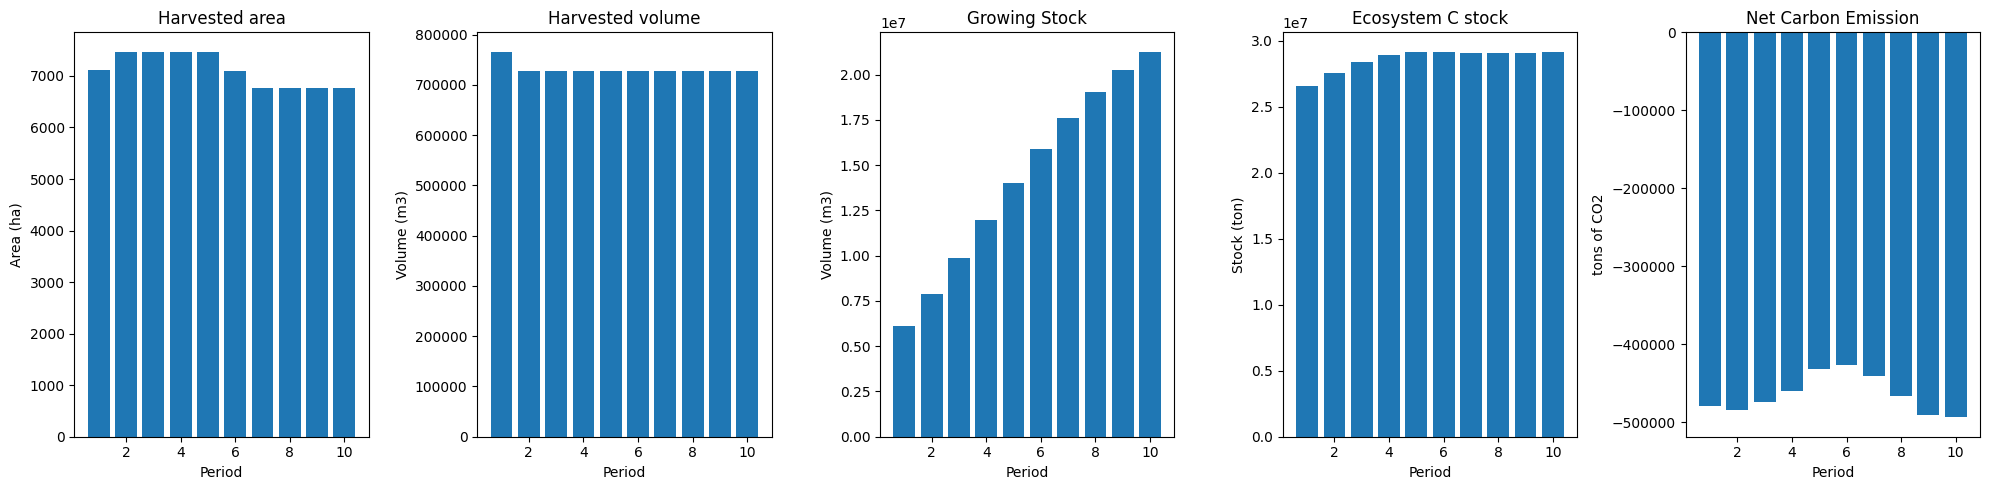

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


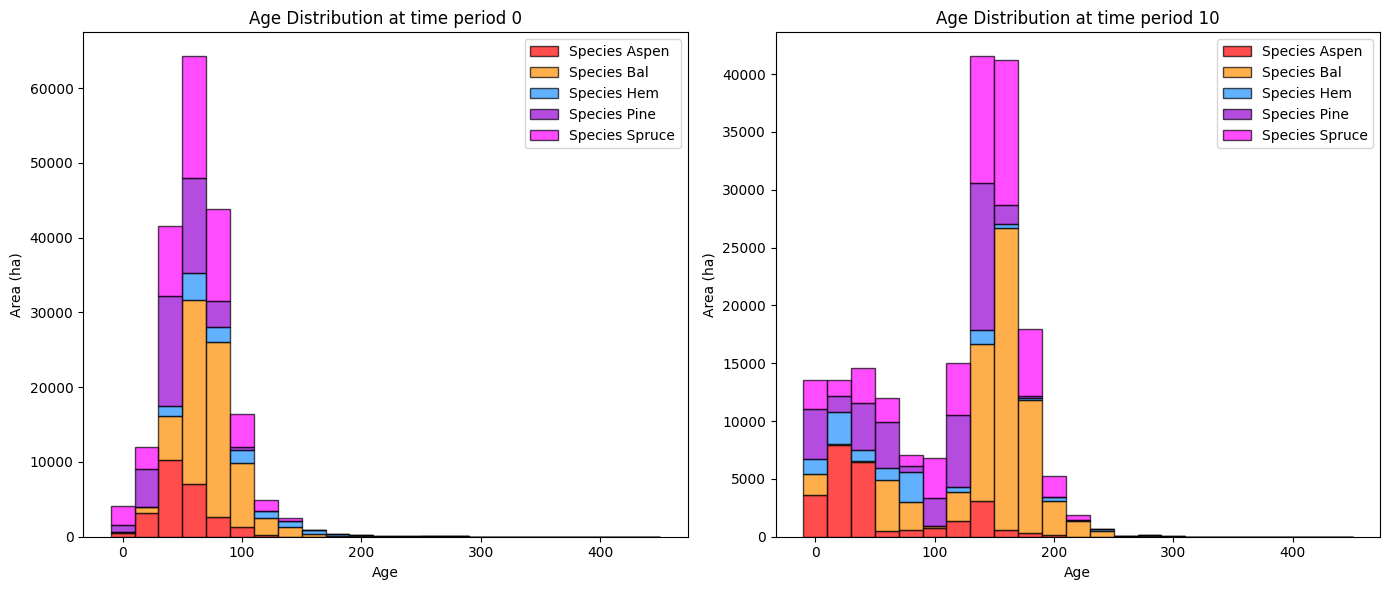

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


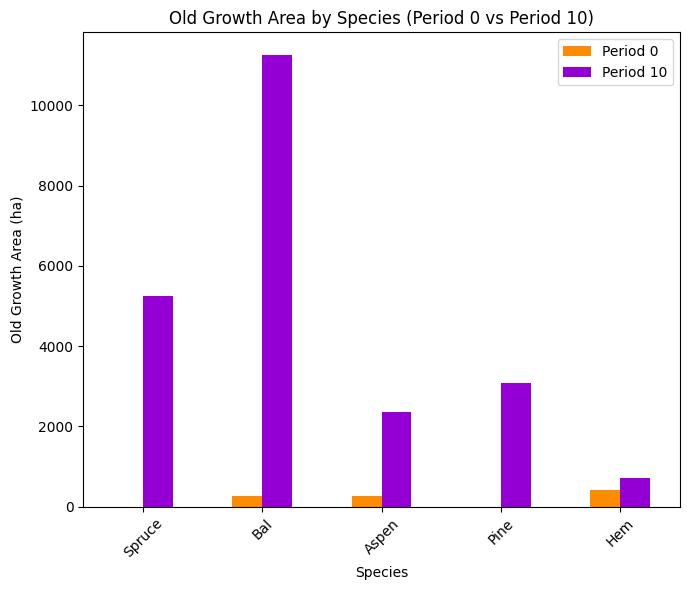

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


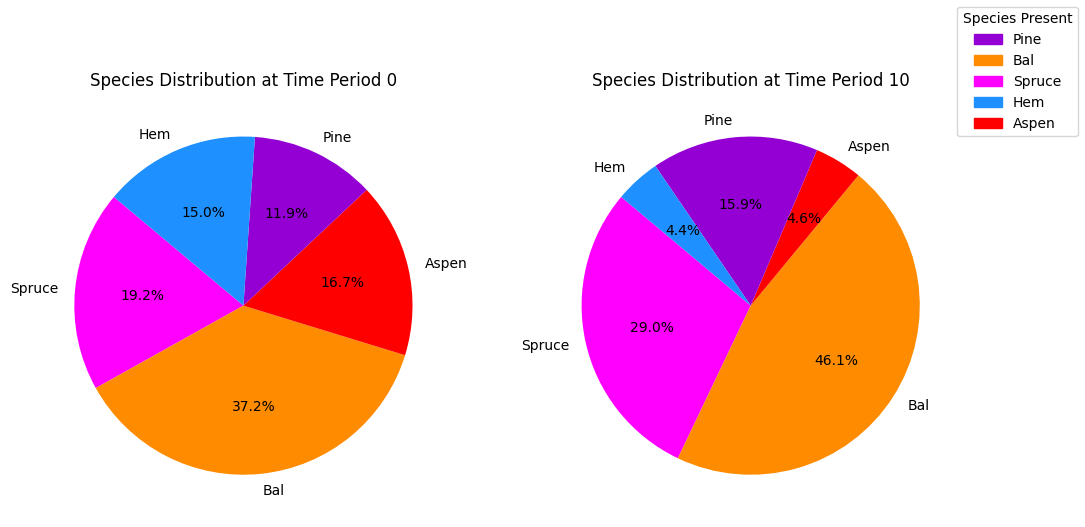

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


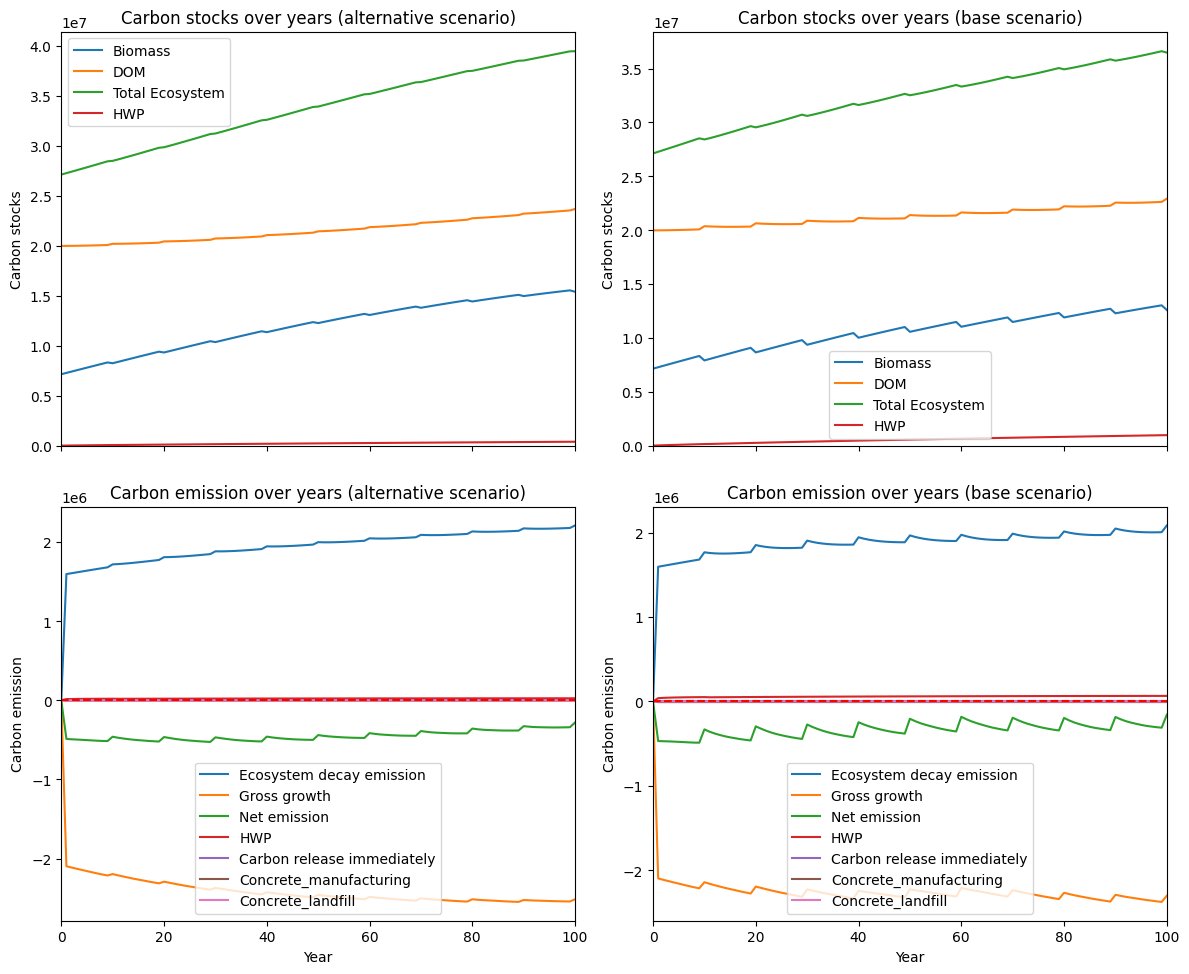

---------------------------------------------------------------------------------------
Net emission difference -11586369.735092482
Net emission base scenario -33239922.163316067
Net emission alternative scenario -44826291.89840854
dollar_per_ton is:  0.8630831078791031
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2236.294993  2236.294993
Bal     0.0  4031.446209  4031.446209
Aspen   0.0  1627.542339  1627.542339
Pine    0.0  3422.950758  3422.950758
Hem     0.0   264.321283   264.321283

Overall, the old growth area has **increased** by 11582.56 hectares in the alternative scenario compared to the base scenario.


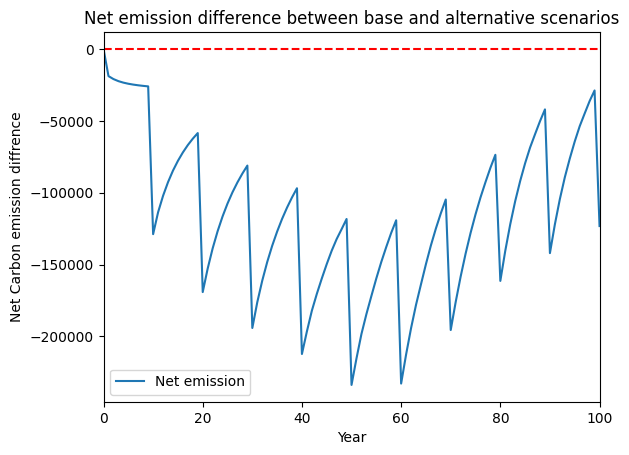

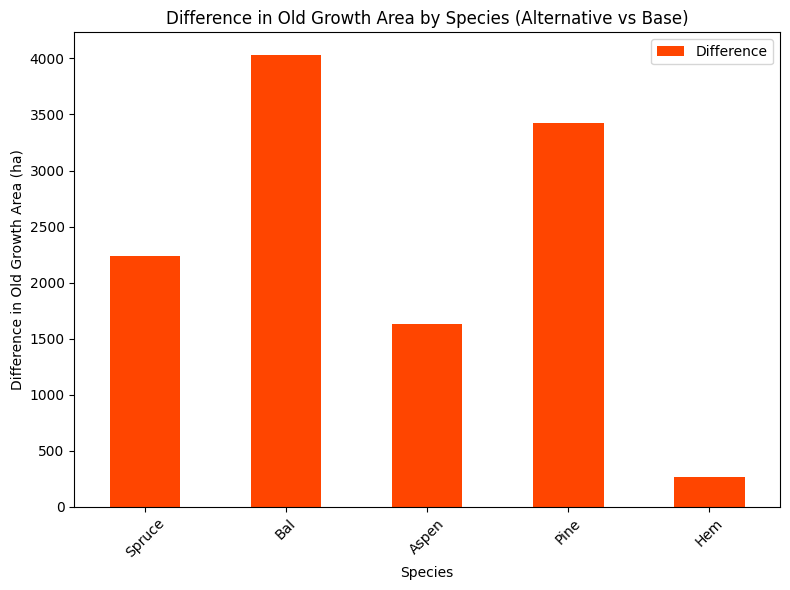

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


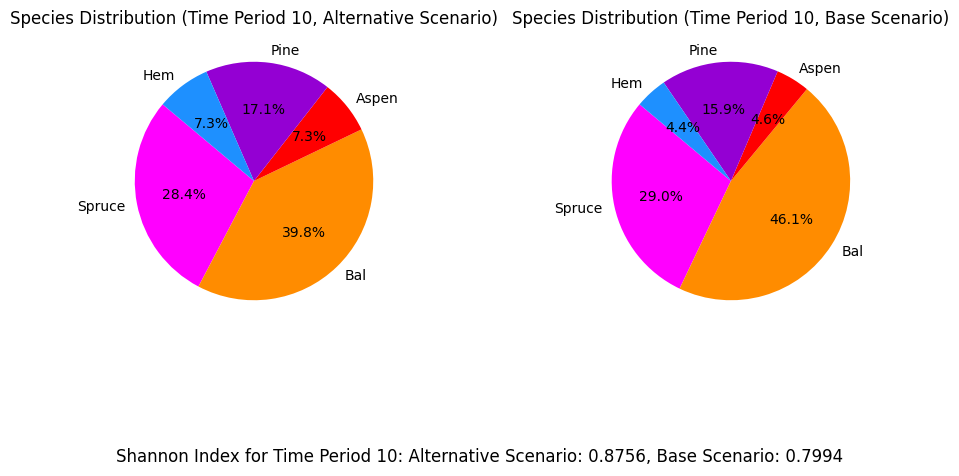

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_30%...
running the scenario for the Golden Bear mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x602b3fa2
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

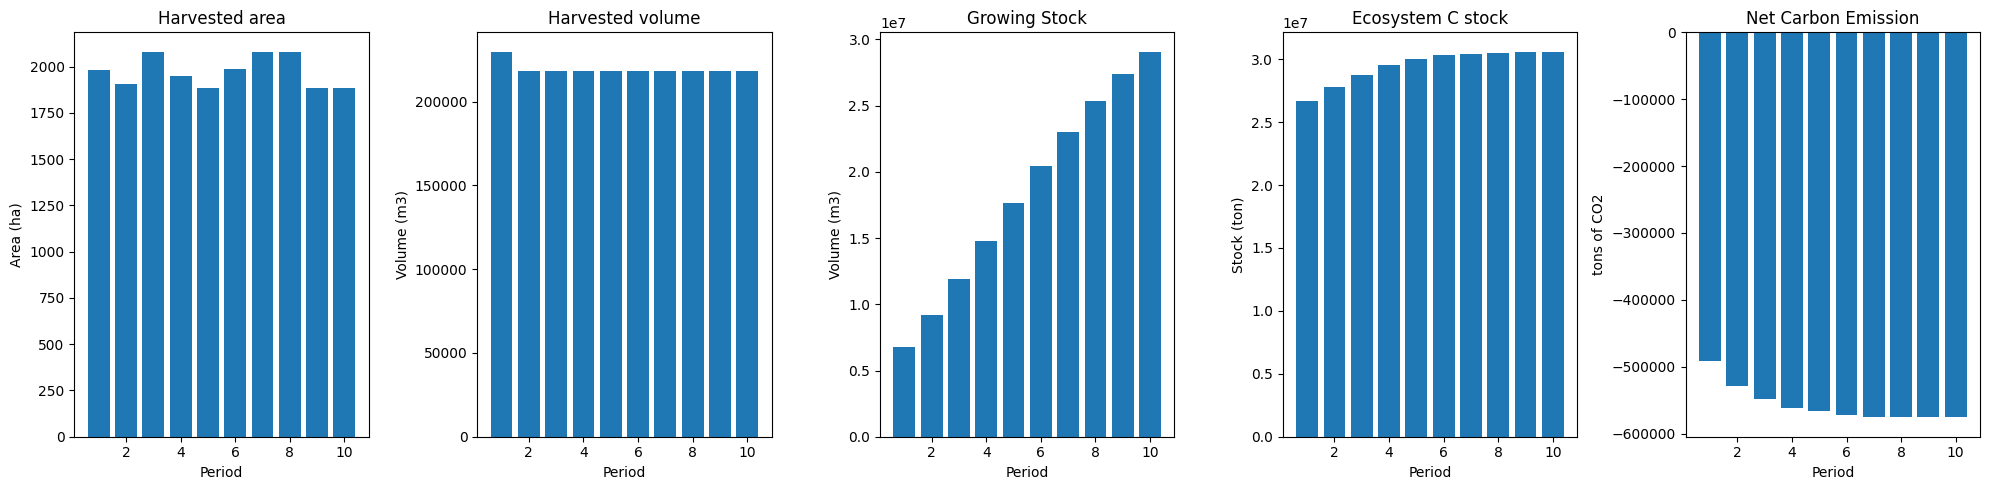

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_30%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2320
The economic indicator (the provincial government revenues) is:  79128
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


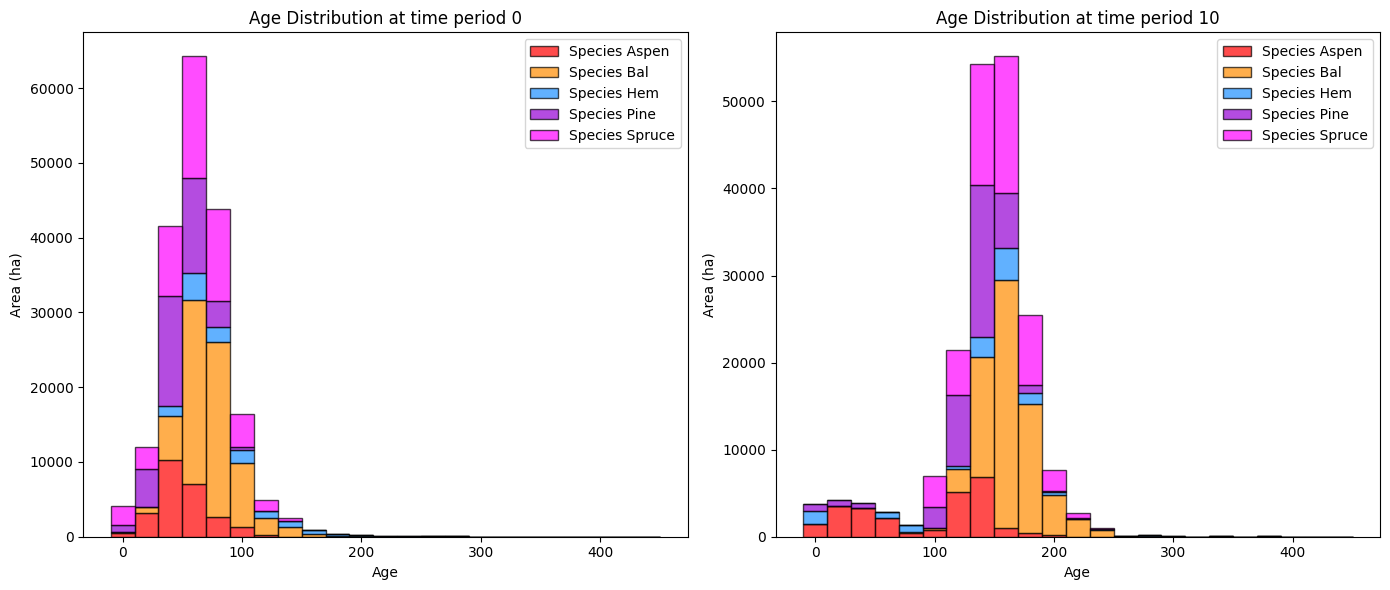

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8033.826560   8031.118026
Bal     278.565372  15837.437506  15558.872134
Aspen   273.490478   4758.866475   4485.375997
Pine      0.000000   6864.438495   6864.438495
Hem     419.699331   1443.085763   1023.386432

Old growth has **increased** by 35963.19 hectares from time period 0 to time period 10.


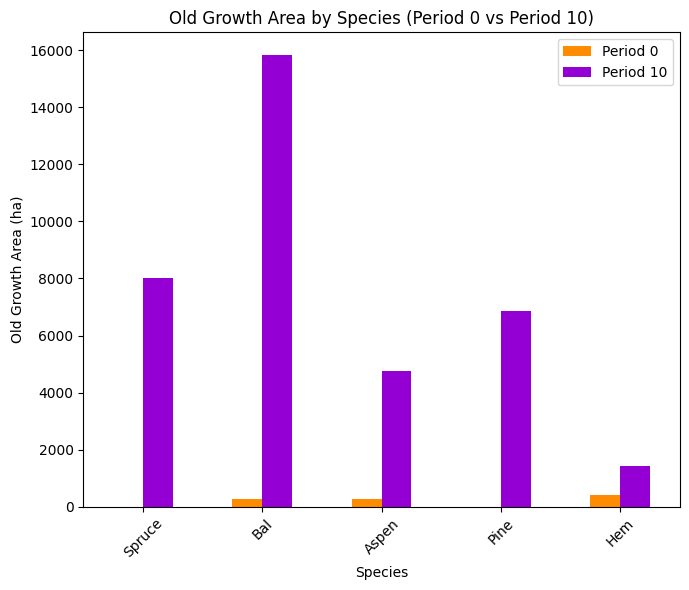

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8888

Diversity has **decreased** by 5.68% from time 0 to time 10.


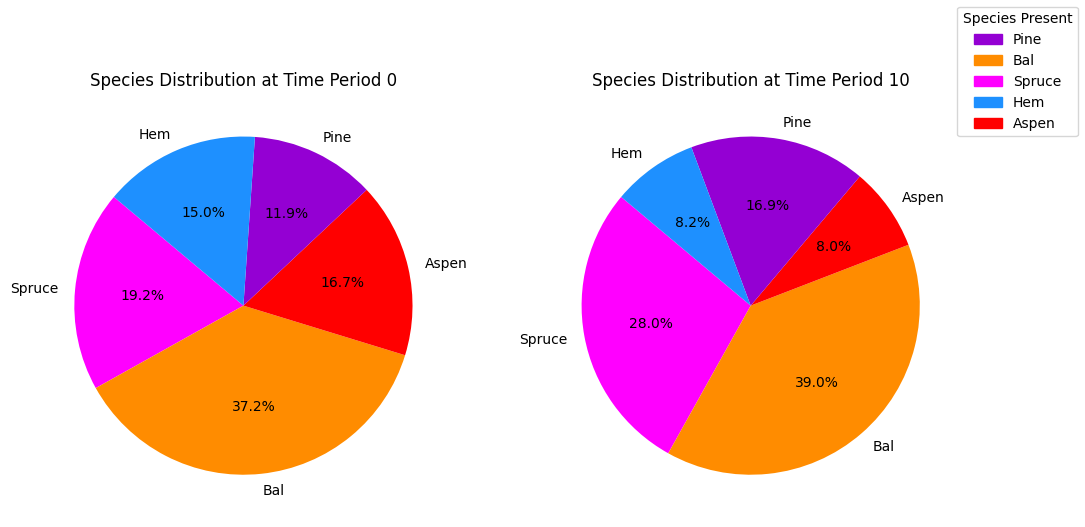

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_30%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

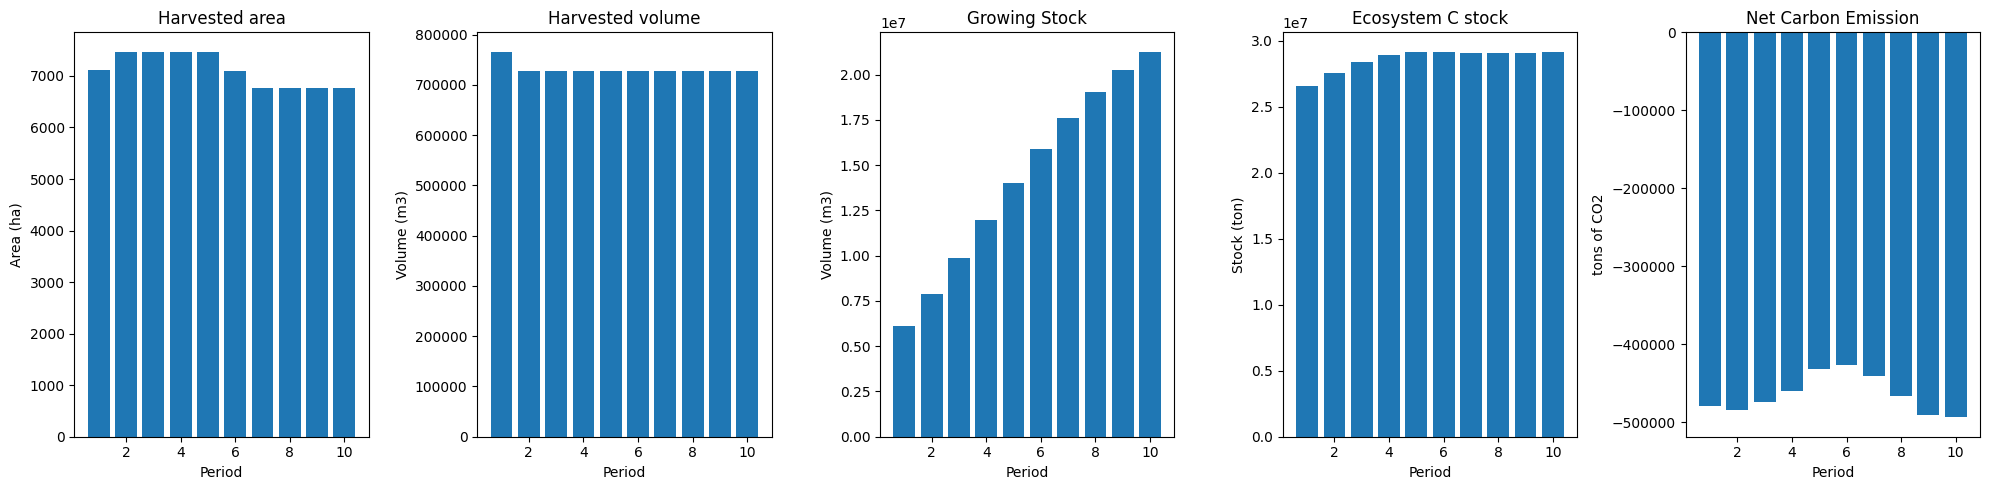

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


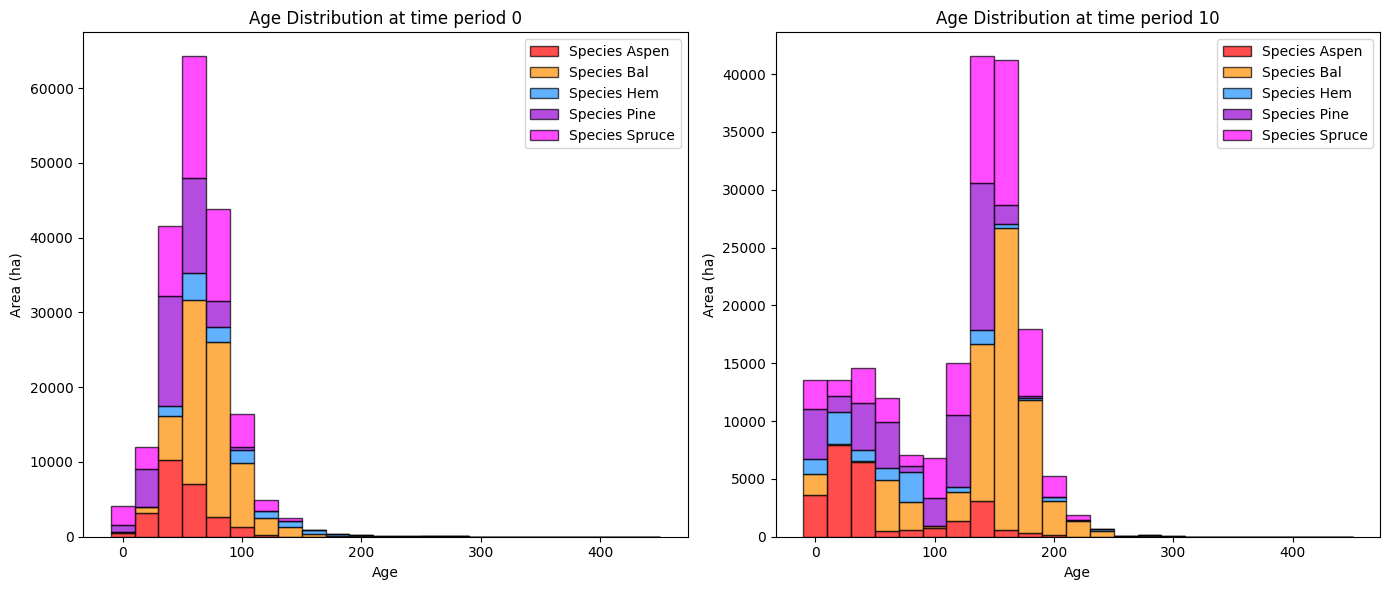

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


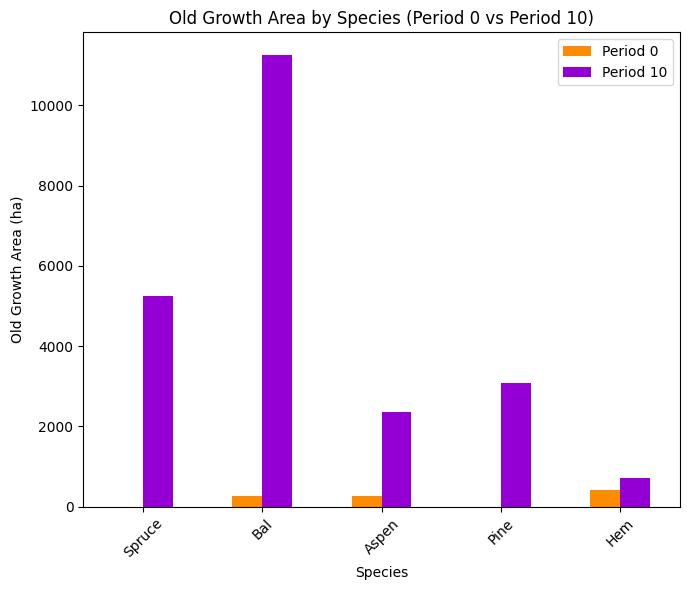

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


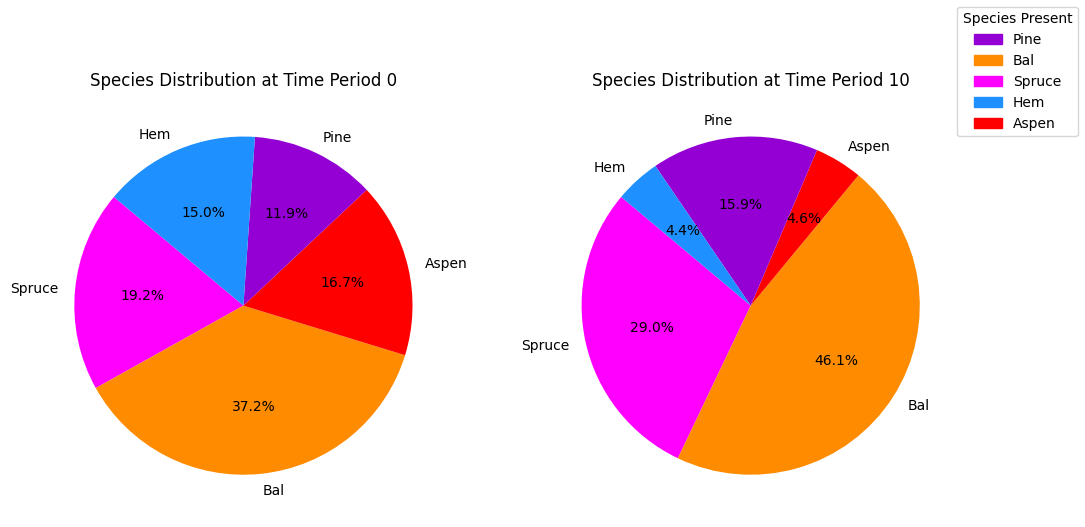

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


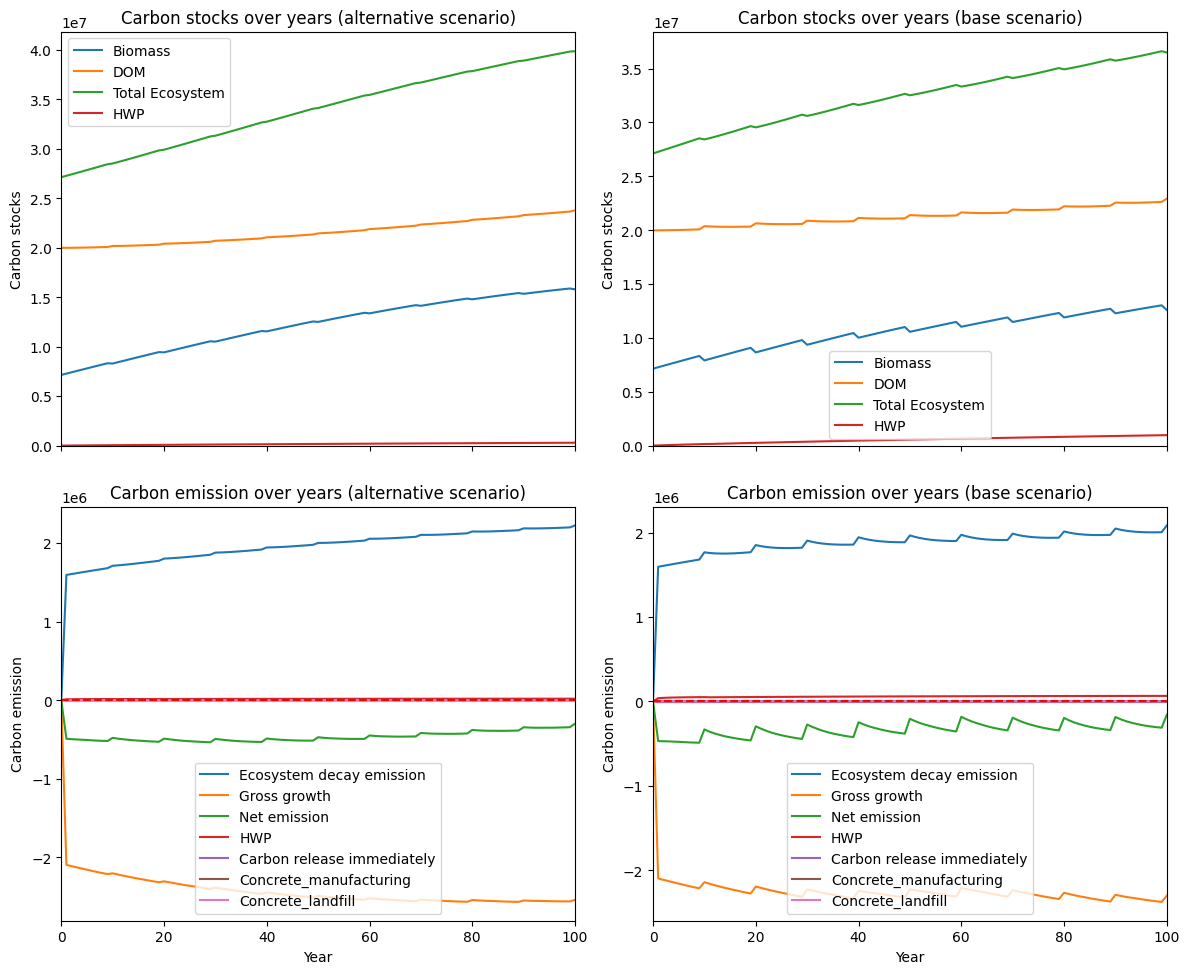

---------------------------------------------------------------------------------------
Net emission difference -13133590.921530474
Net emission base scenario -33239922.163316067
Net emission alternative scenario -46373513.084846534
dollar_per_ton is:  0.7614063860940392
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2791.016845  2791.016845
Bal     0.0  4584.443141  4584.443141
Aspen   0.0  2408.898899  2408.898899
Pine    0.0  3777.242135  3777.242135
Hem     0.0   738.045367   738.045367

Overall, the old growth area has **increased** by 14299.65 hectares in the alternative scenario compared to the base scenario.


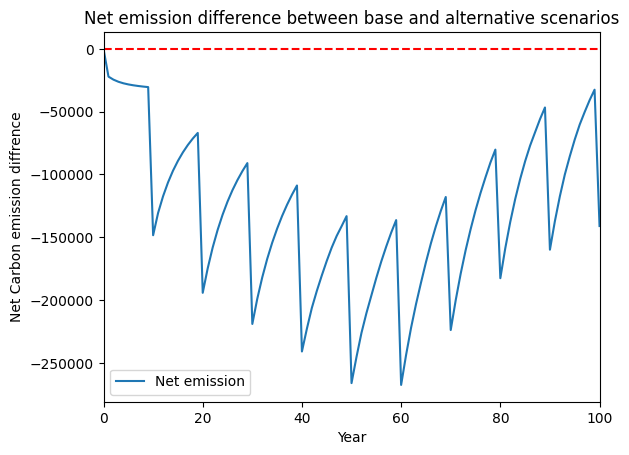

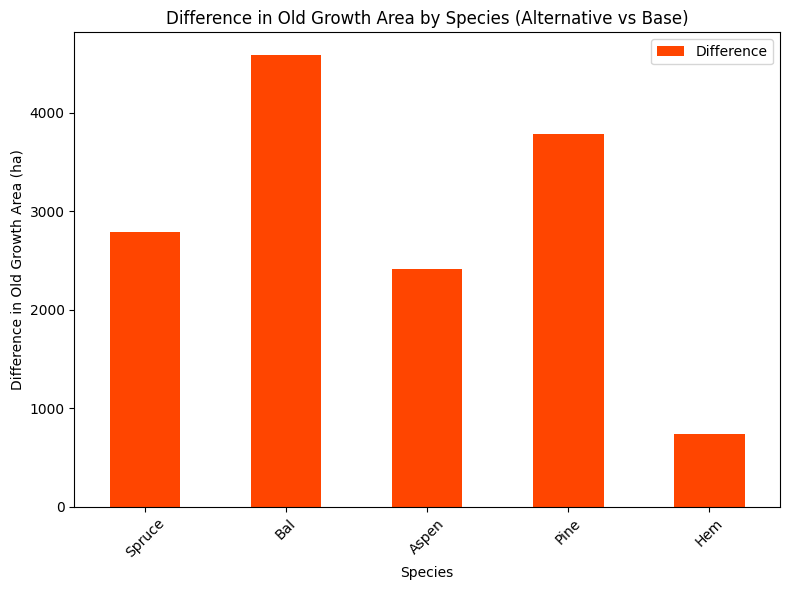

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


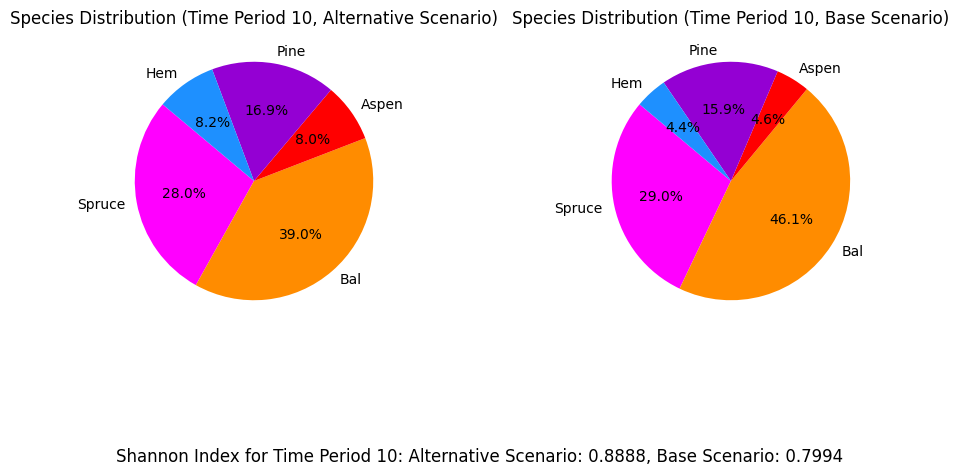

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_20%...
running the scenario for the Golden Bear mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x10086be4
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34100 

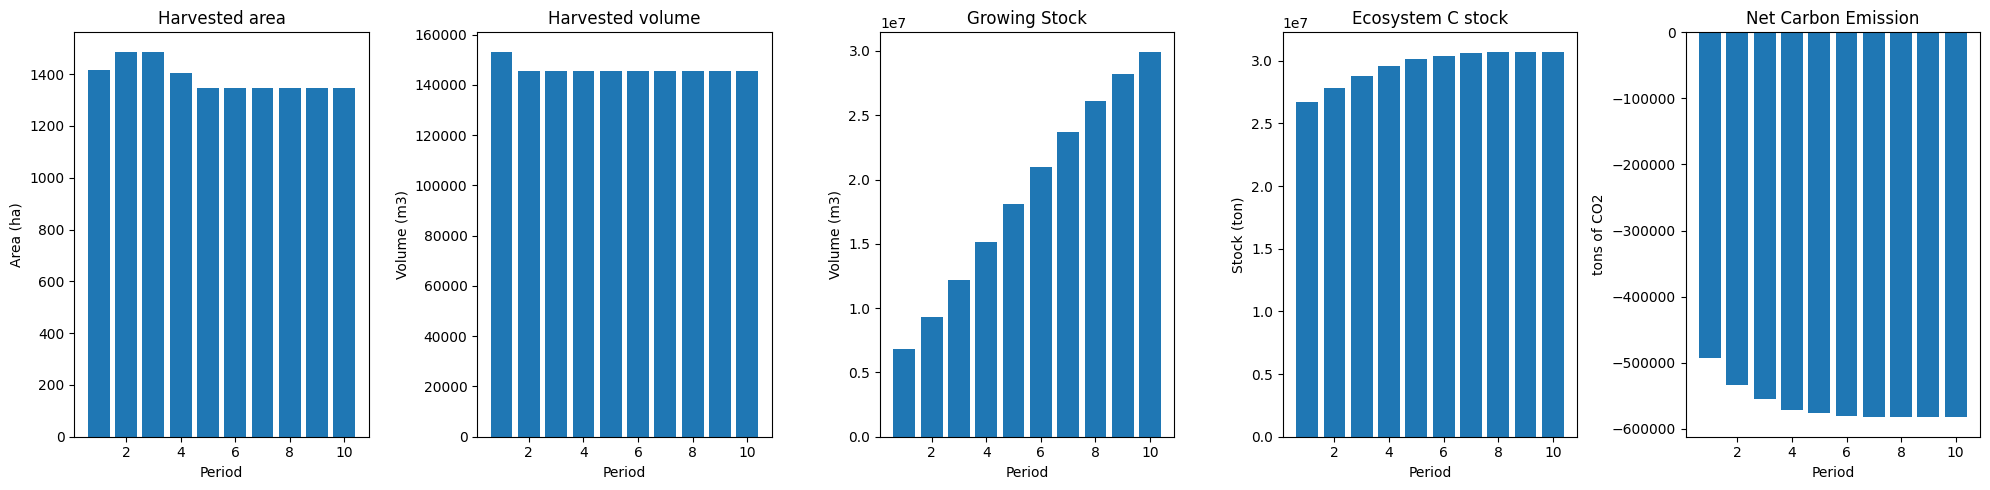

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_20%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  1546
The economic indicator (the provincial government revenues) is:  52752
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


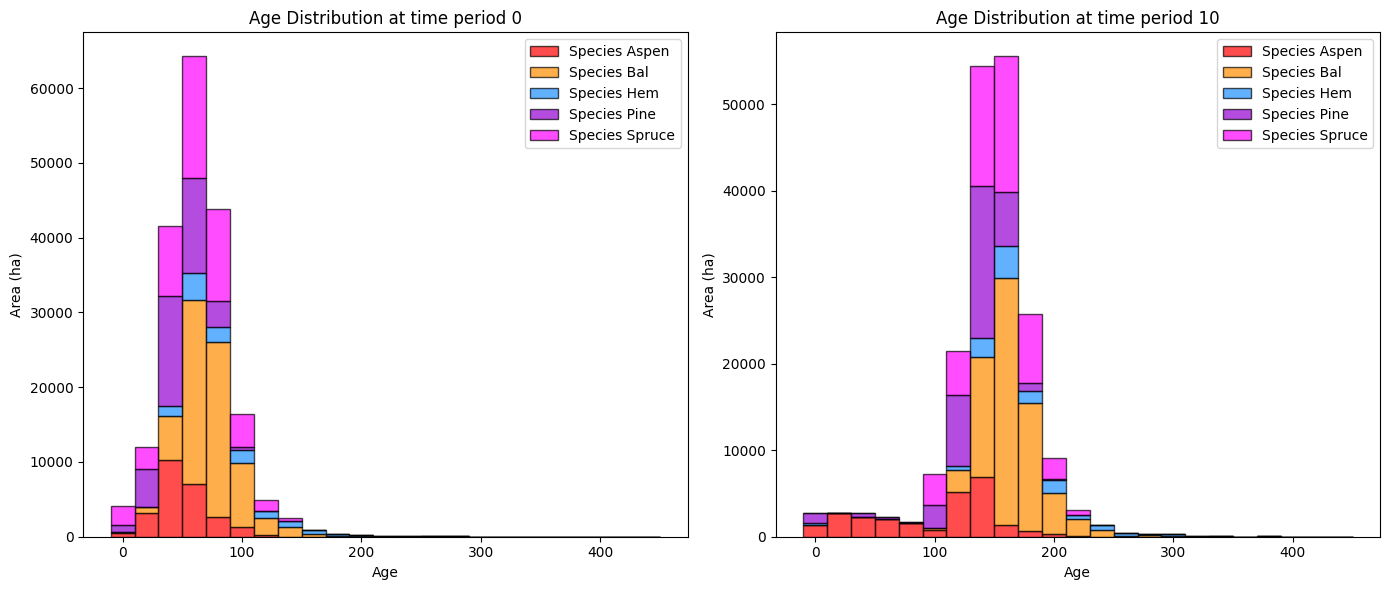

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478   5603.343730   5329.853252
Pine      0.000000   6868.512140   6868.512140
Hem     419.699331   3626.250351   3206.551020

Old growth has **increased** by 39126.91 hectares from time period 0 to time period 10.


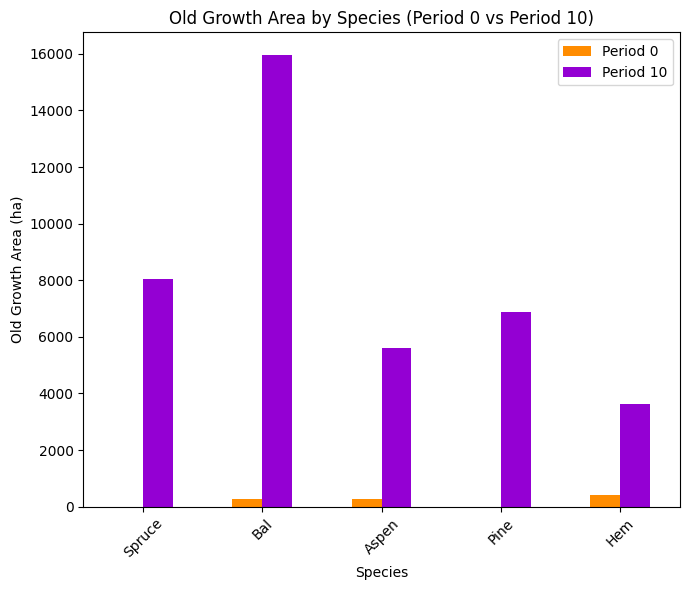

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9060

Diversity has **decreased** by 3.95% from time 0 to time 10.


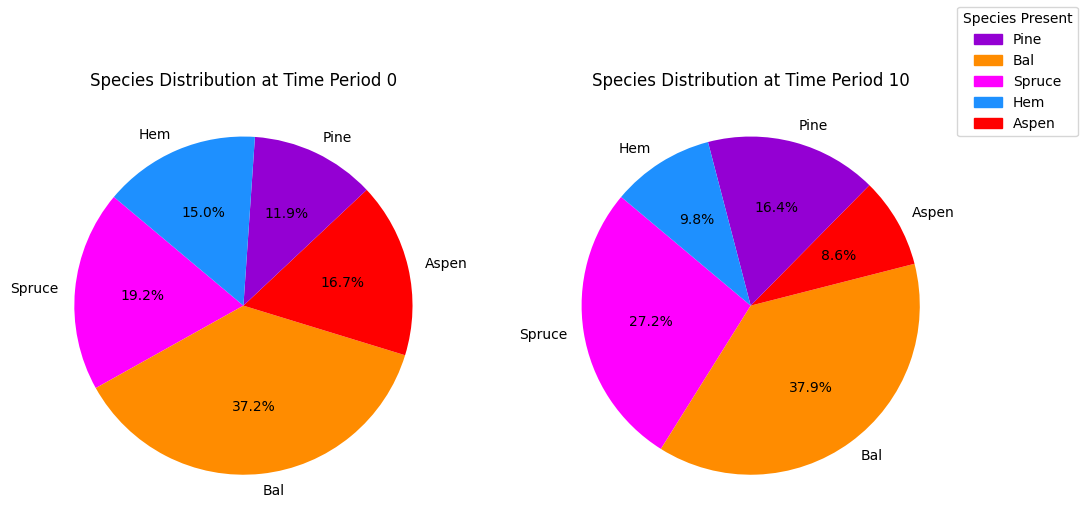

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_20%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

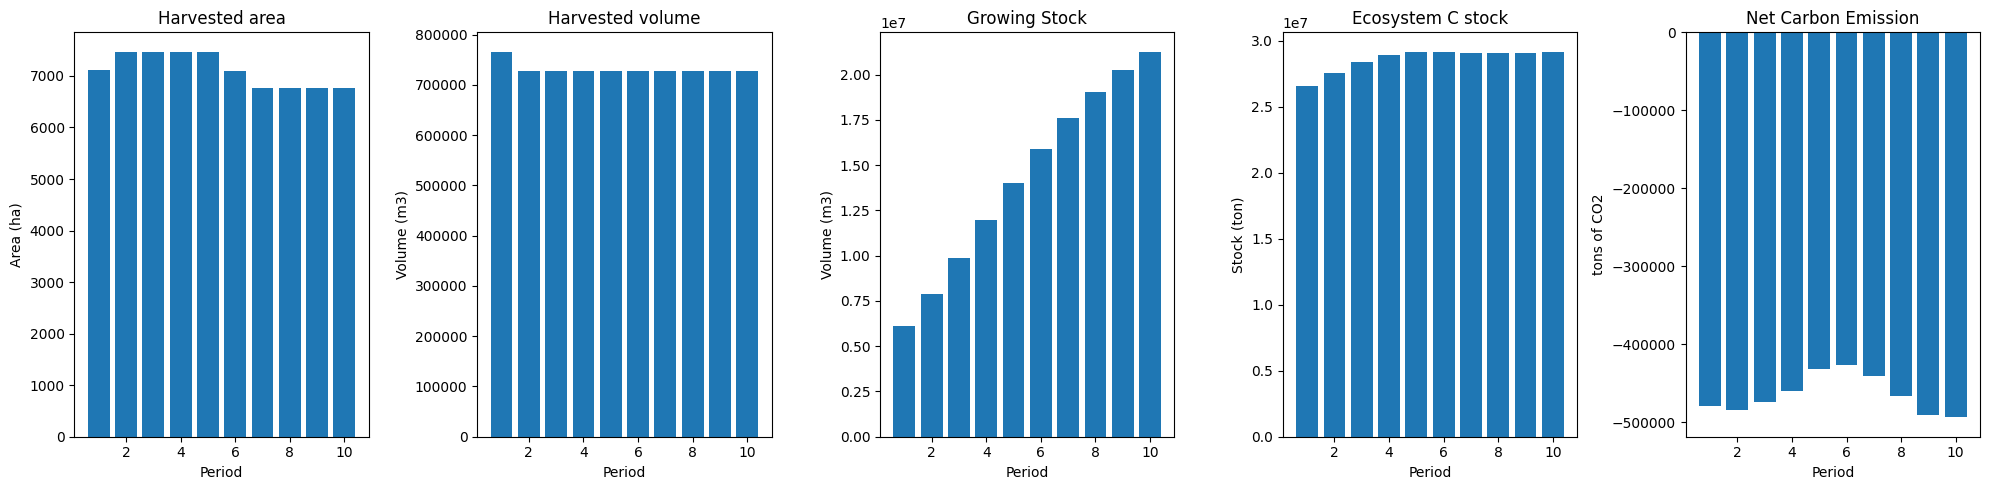

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


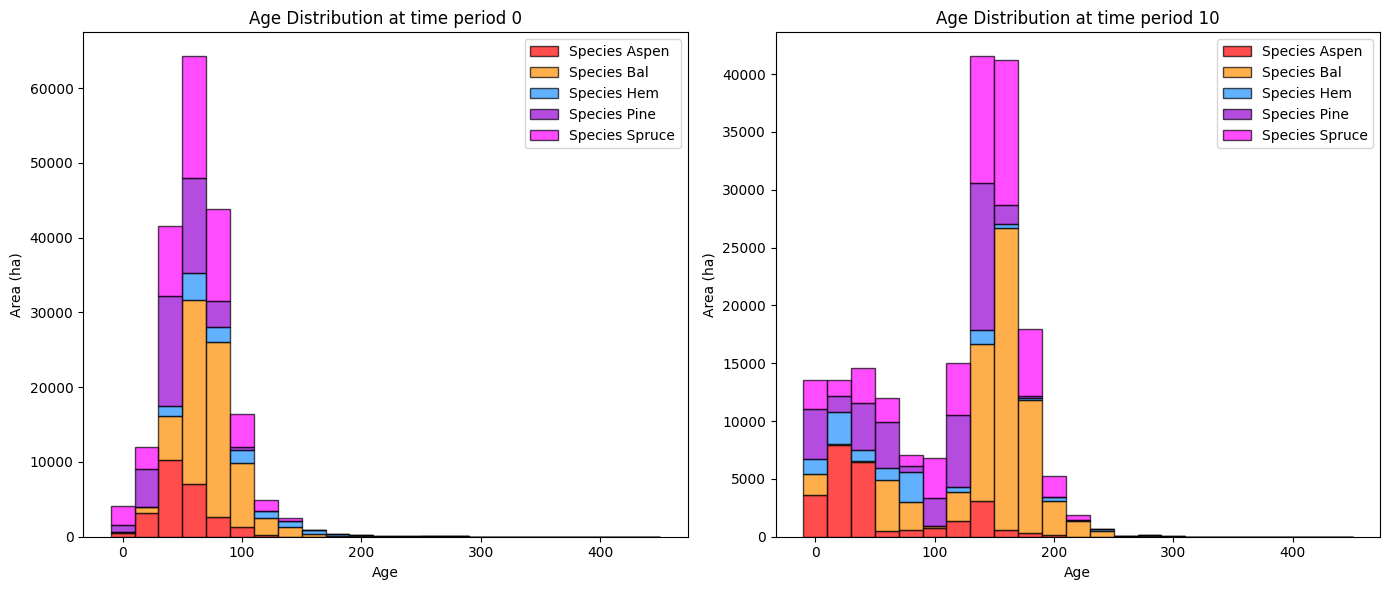

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


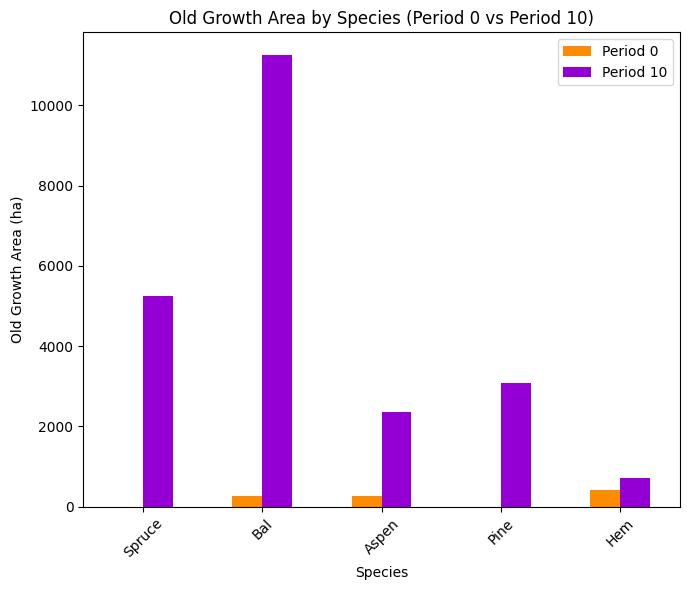

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


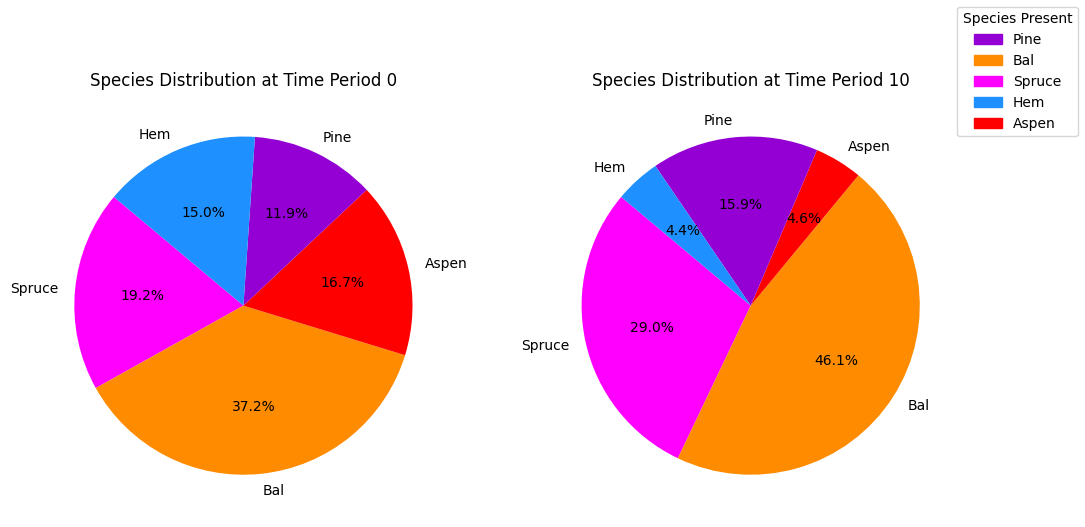

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


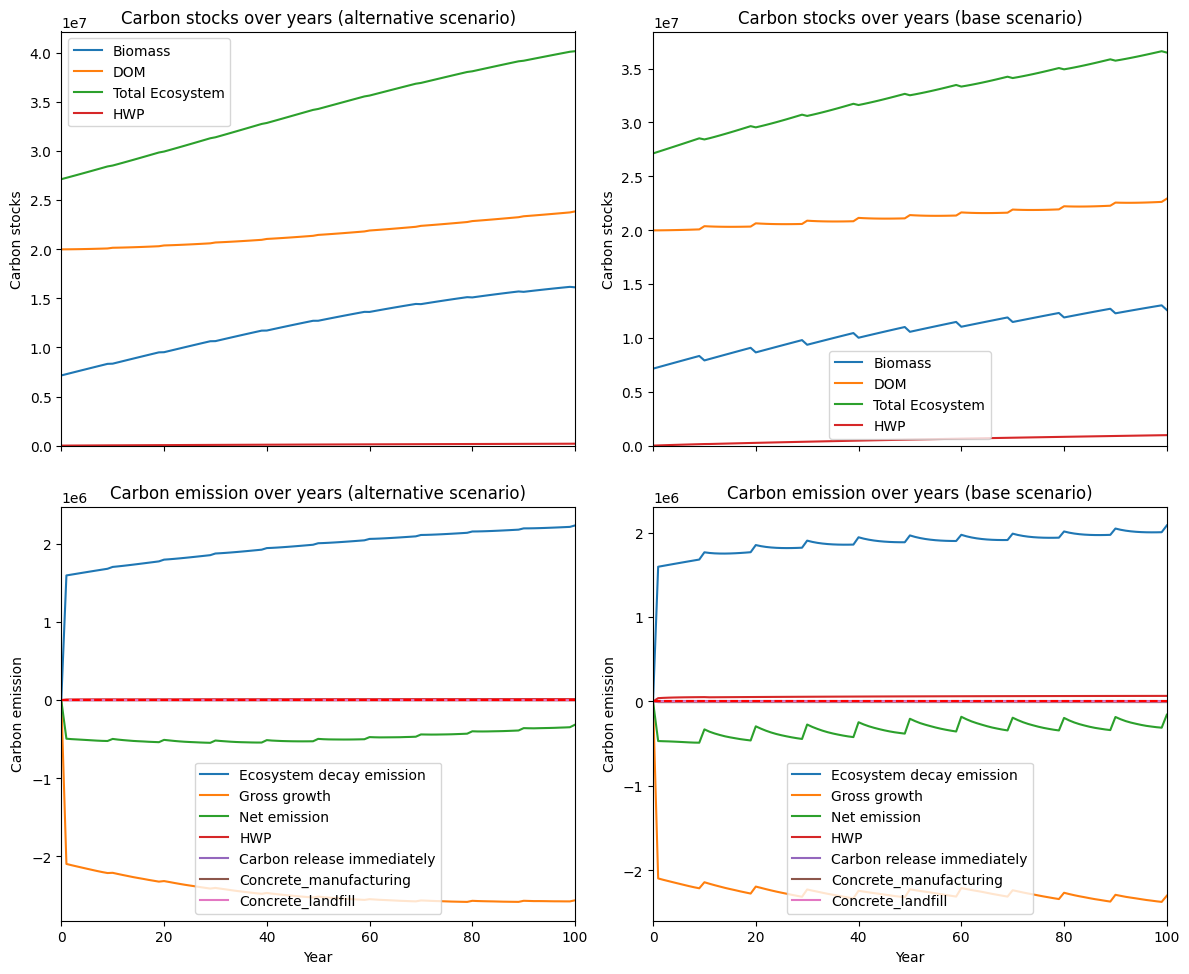

---------------------------------------------------------------------------------------
Net emission difference -14412457.331966627
Net emission base scenario -33239922.163316067
Net emission alternative scenario -47652379.49528268
dollar_per_ton is:  0.6938442050281142
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2797.454325  2797.454325
Bal     0.0  4710.013370  4710.013370
Aspen   0.0  3253.376155  3253.376155
Pine    0.0  3781.315780  3781.315780
Hem     0.0  2921.209955  2921.209955

Overall, the old growth area has **increased** by 17463.37 hectares in the alternative scenario compared to the base scenario.


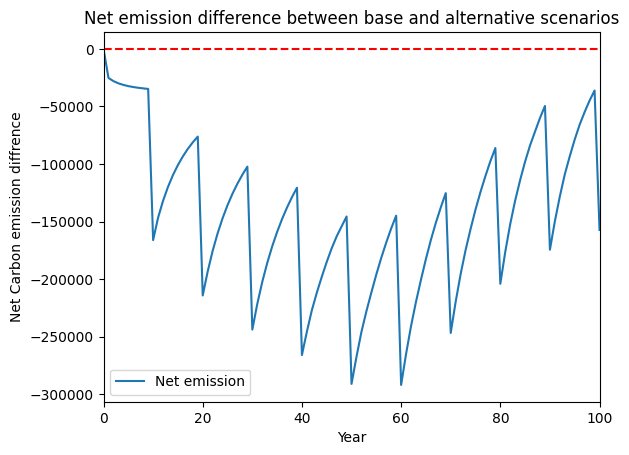

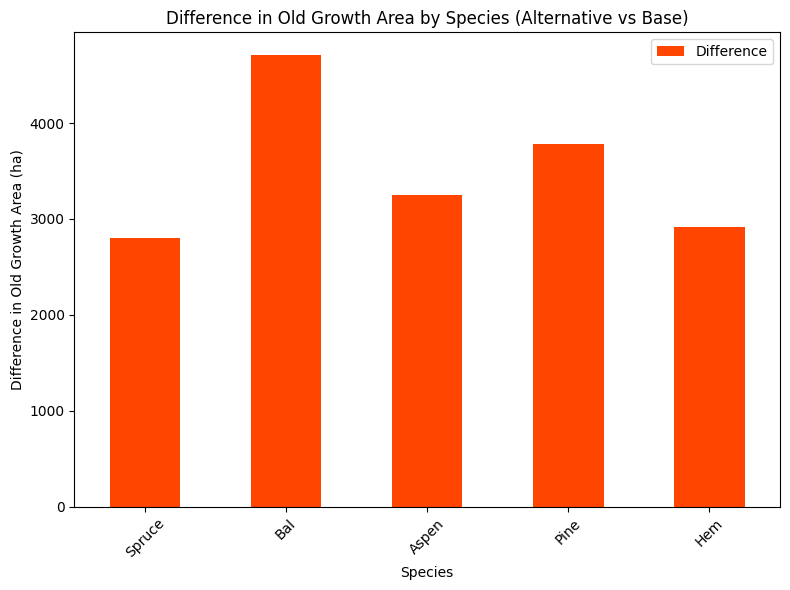

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


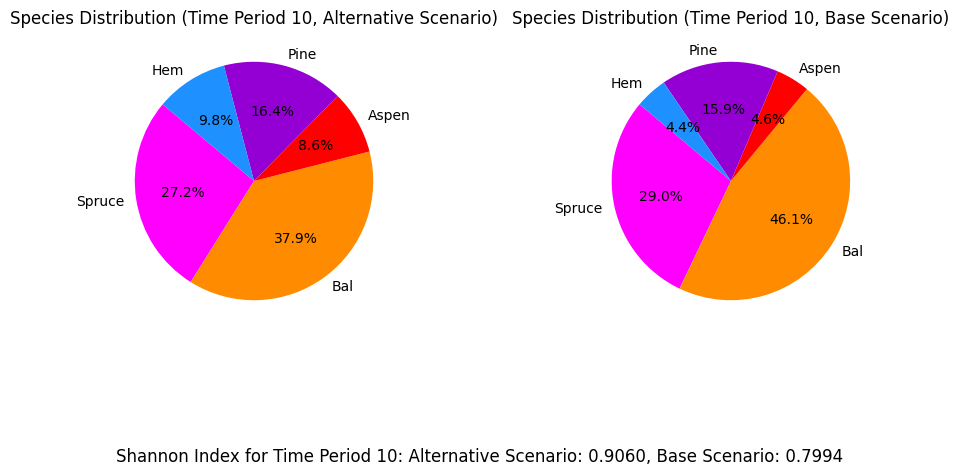

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_min_em_gldbr_AAC_10%...
running the scenario for the Golden Bear mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x51f05bb5
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34100 

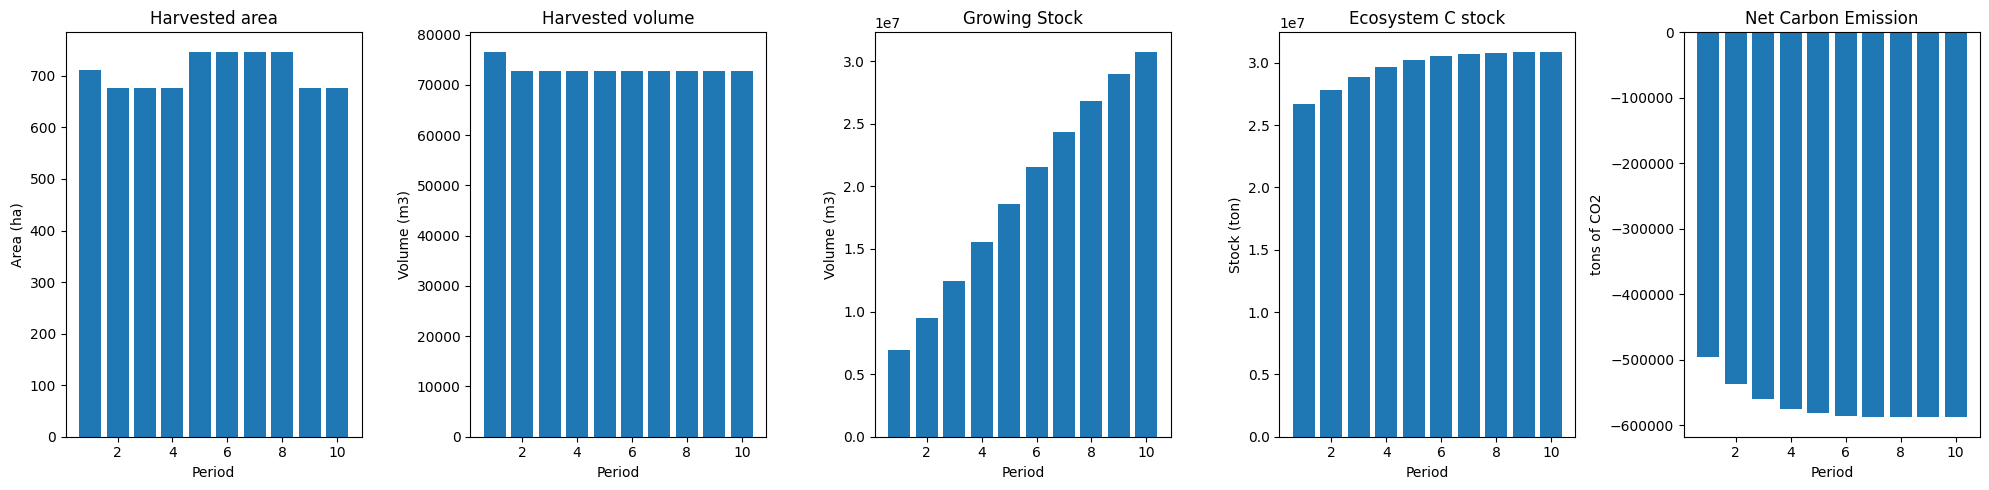

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_10%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  773
The economic indicator (the provincial government revenues) is:  26376
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


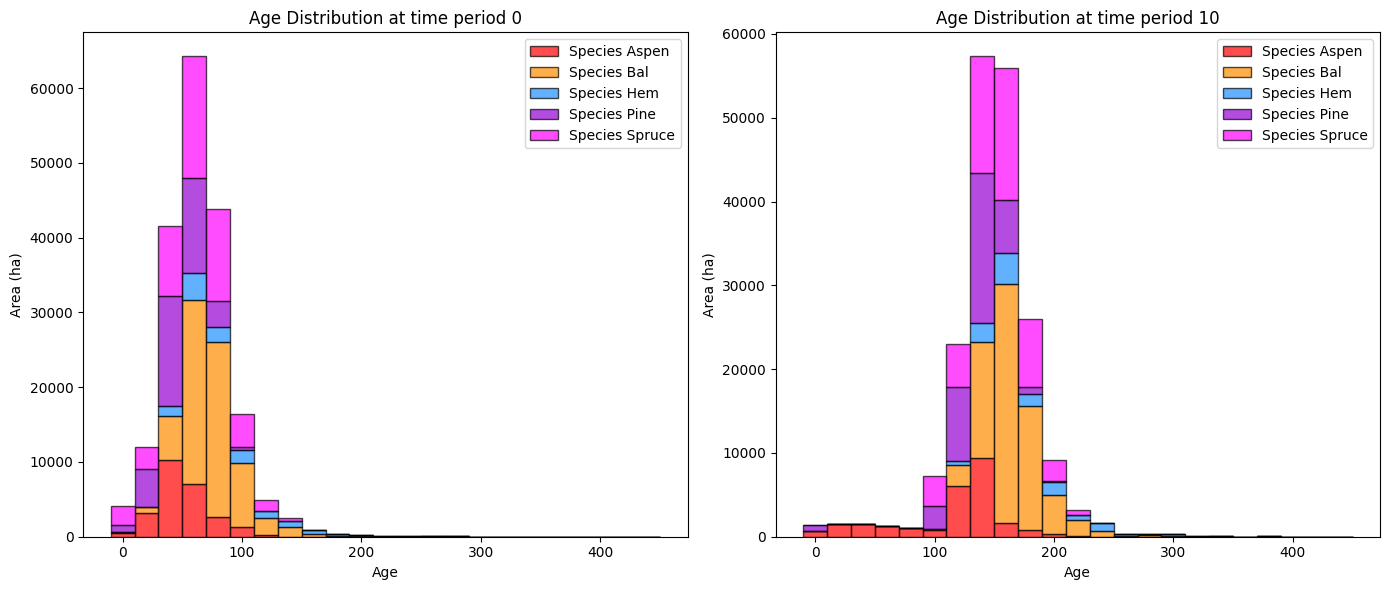

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478   8250.406886   7976.916408
Pine      0.000000   7177.987016   7177.987016
Hem     419.699331   3929.593538   3509.894208

Old growth has **increased** by 42386.80 hectares from time period 0 to time period 10.


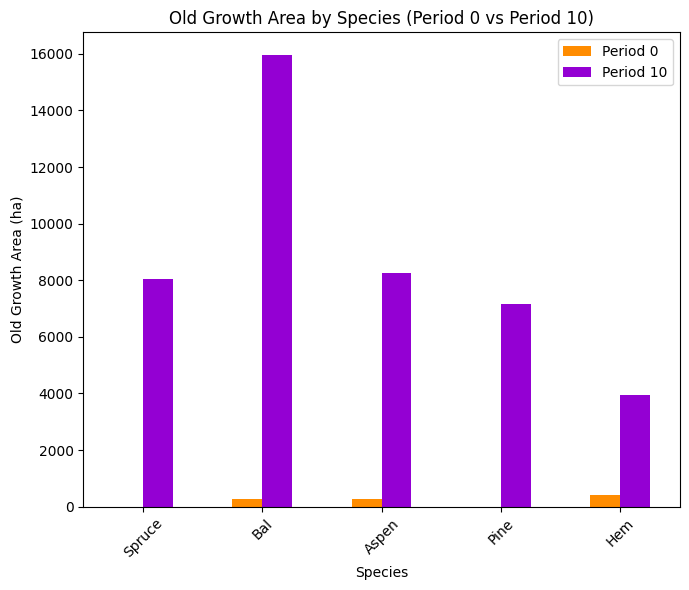

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9196

Diversity has **decreased** by 2.60% from time 0 to time 10.


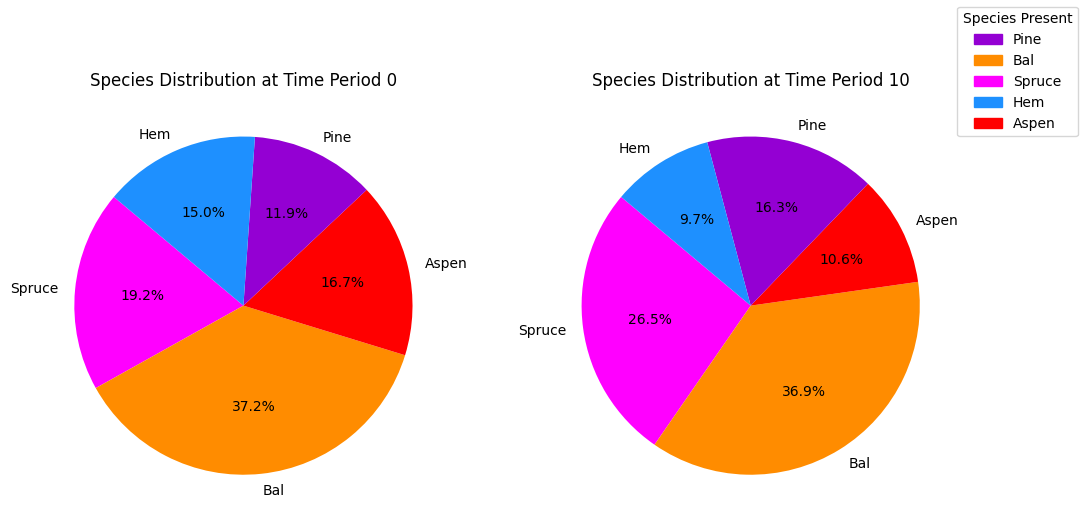

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_gldbr_AAC_10%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xc42e6e66
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [6e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

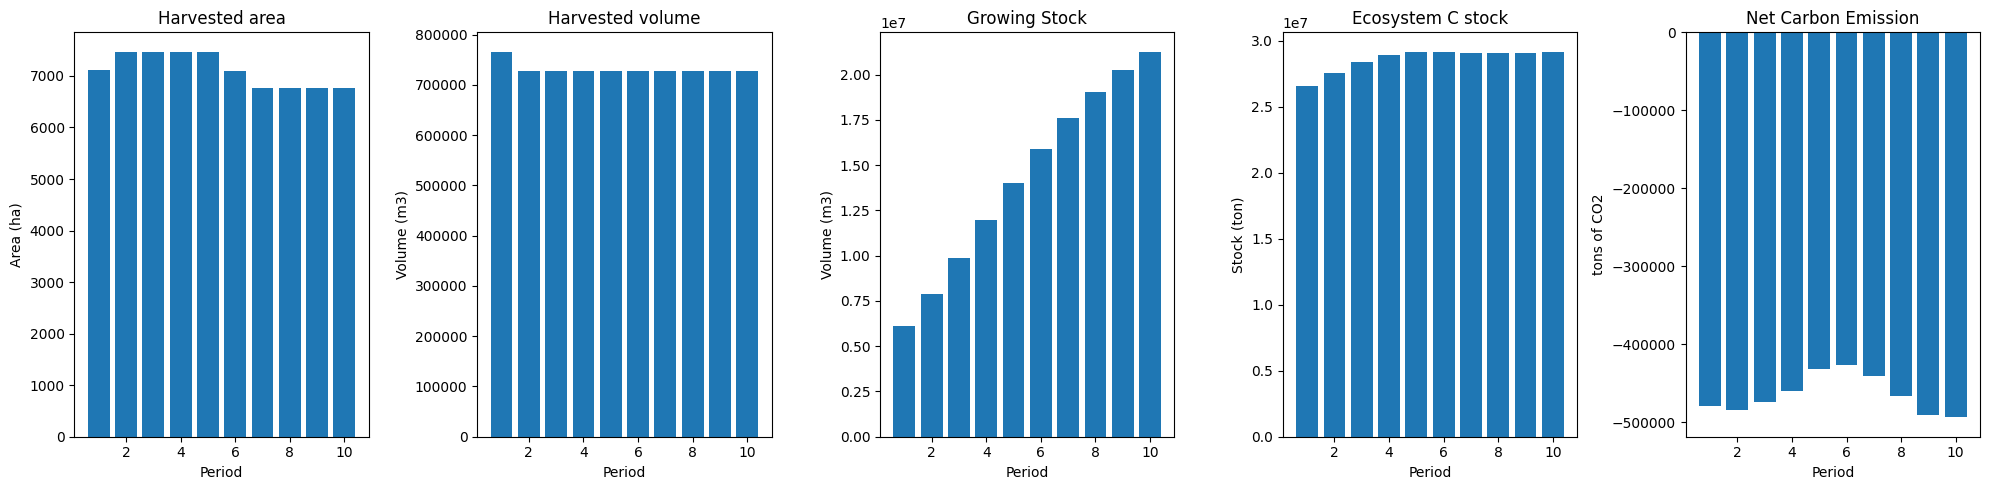

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


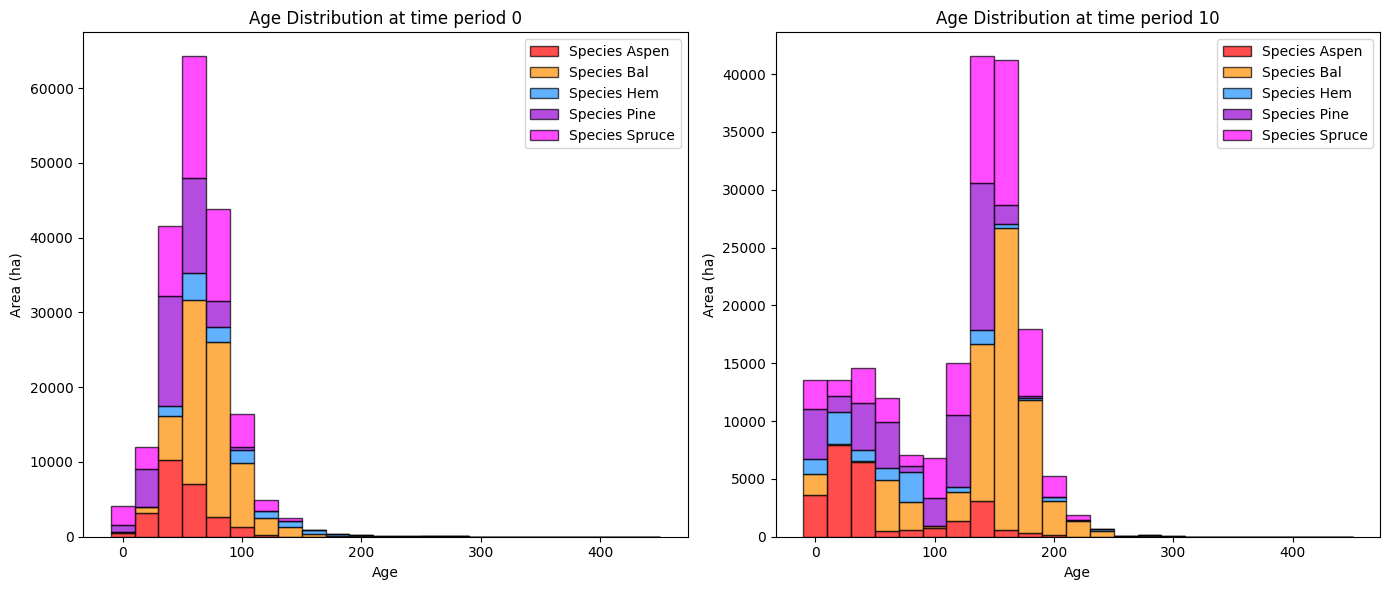

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5242.809714   5240.101181
Bal     278.565372  11252.994365  10974.428993
Aspen   273.490478   2349.967575   2076.477097
Pine      0.000000   3087.196360   3087.196360
Hem     419.699331    705.040396    285.341065

Old growth has **increased** by 21663.54 hectares from time period 0 to time period 10.


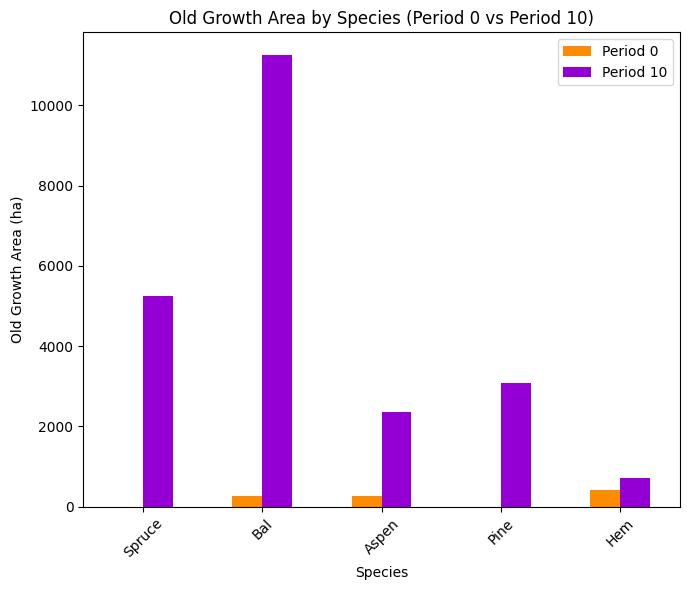

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.7994

Diversity has **decreased** by 14.62% from time 0 to time 10.


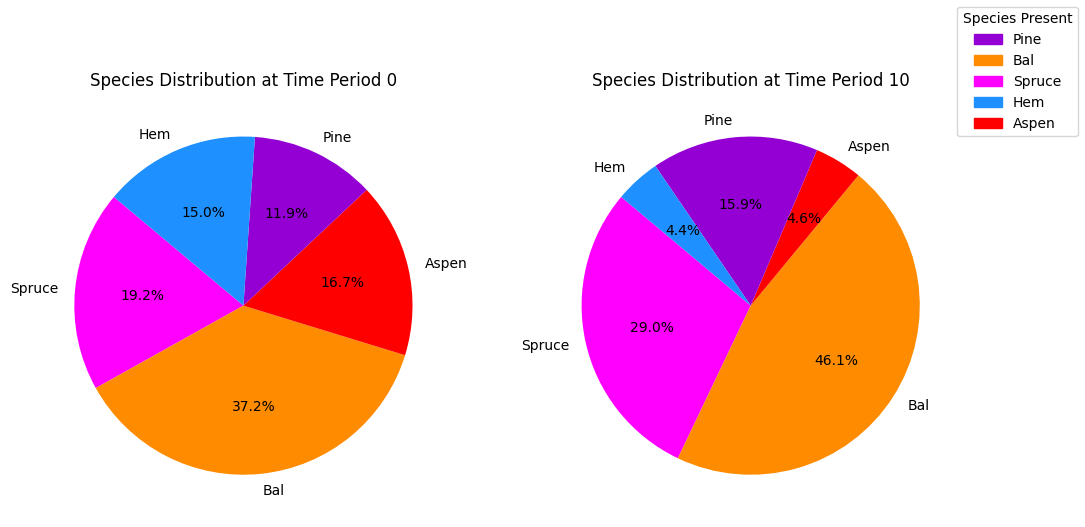

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_bau_gldbr_species_pie.pdf


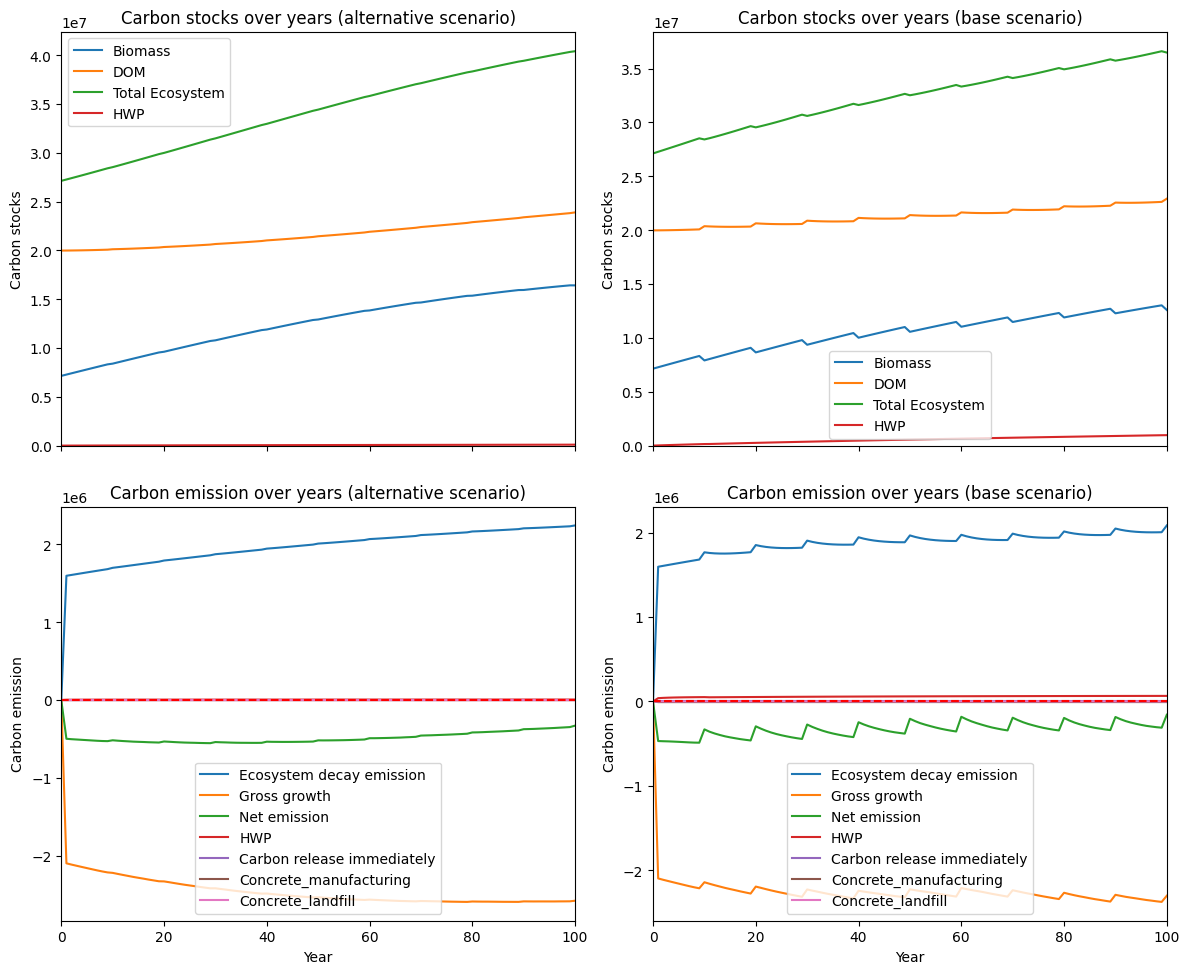

---------------------------------------------------------------------------------------
Net emission difference -15398228.731525145
Net emission base scenario -33239922.163316067
Net emission alternative scenario -48638150.894841194
dollar_per_ton is:  0.6494253445869895
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2797.454325  2797.454325
Bal     0.0  4710.013370  4710.013370
Aspen   0.0  5900.439311  5900.439311
Pine    0.0  4090.790656  4090.790656
Hem     0.0  3224.553142  3224.553142

Overall, the old growth area has **increased** by 20723.25 hectares in the alternative scenario compared to the base scenario.


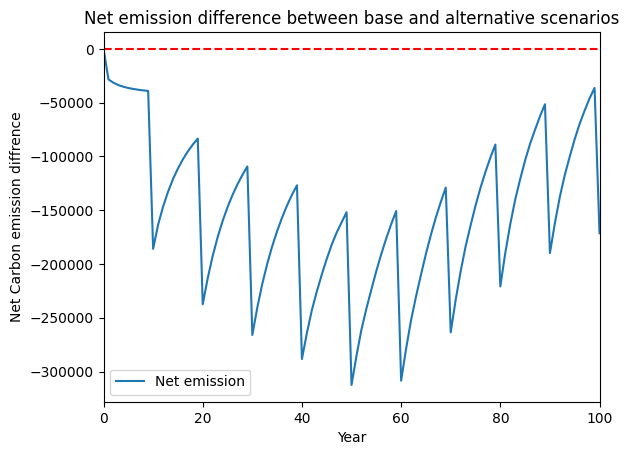

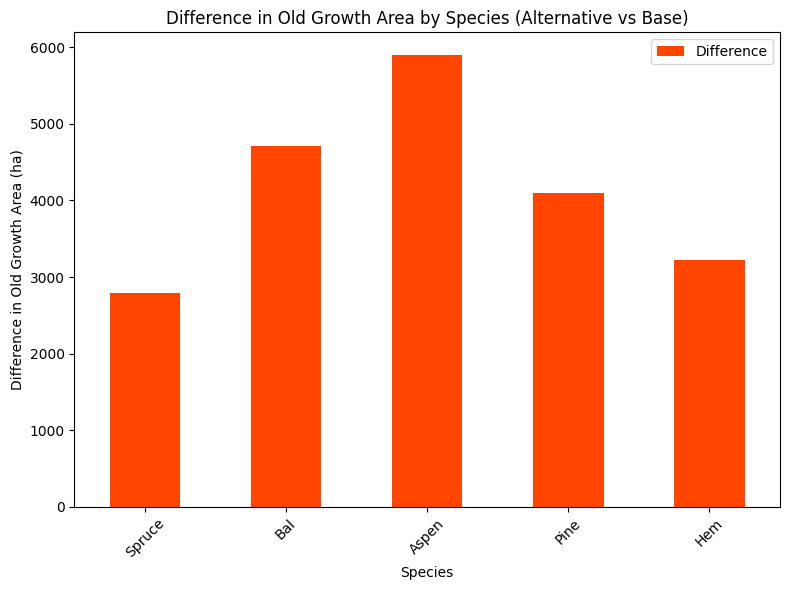

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_age_difference.pdf


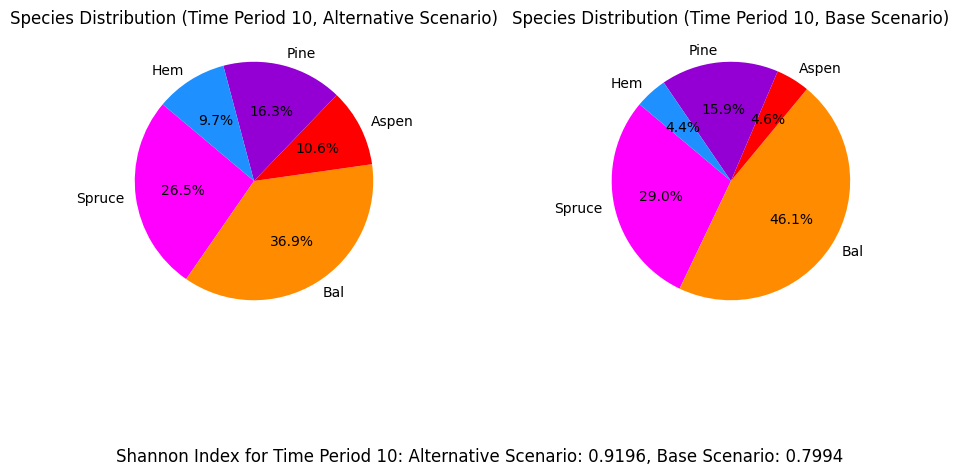

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 89.0 minutes to run all scenarios.


In [12]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [13]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 89.0 minutes to run this script.
